# STEM Digital Twin — Limits & Bounds Playground

An **interactive notebook to test the realistic limits** before locking them into the GUI.
Every control below is an `ipywidgets` slider/dropdown wired to the live twin, with the
**recommended real-TEM range** as its min/max. Sweep each one, watch the image/pattern/spectrum
update, and if a bound feels wrong, change the slider's `min`/`max` in the cell and re-run —
that's exactly the tuning loop this notebook is for.

**What changed for realism (vs. earlier builds):**
- **Drift is now specified in physical `nm/s`** (not raw pixels), and the environment presets
  were dialed down from ~60–360 nm/s (absurd) to **0–6 nm/s** (a real session: excellent < 0.2,
  good ~0.5, moderate ~2, poor/just-inserted ~5, ~10 nm/s ≈ worst usable).
- A **32-bit TIFF save** (`twin_io.TwinImageIO`) that keeps only the last frame in memory and
  writes on demand with clean auto-names.
- **z (focus) and drift** are exercised here so you can confirm the ranges feel right.


## 1. Build the twin (samples + server + client + io helper)

In [1]:
!pip -q install twisted ase scipy tifffile abtem


In [2]:
import os
os.makedirs('samples', exist_ok=True)
print('samples/ ready')

samples/ ready


In [3]:
%%writefile samples/base.py
"""
samples/base.py

Sample base class. Now carries an OPTIONAL crystallographic `lattice`
descriptor so the server can compute real kinematical diffraction for
crystalline samples. Non-crystalline samples leave `lattice=None` and the
server falls back to an FFT-based diffraction proxy.
"""
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional


def make_lamella_slab(D, H, W, generation_range_um, sample_length_um,
                      sample_width_um, base_level=90.0, slab_level=42000.0,
                      edge_softness_px=6.0, texture=0.0, seed=0):
    """Build a uniform FIB-lamella slab volume for CRYSTAL samples.

    A single crystal in HAADF at low/moderate magnification is a roughly UNIFORM
    slab (mass-thickness contrast), NOT a visible lattice -- atomic columns are
    ~0.2 nm apart and cannot be rendered in a coarse voxel volume (a voxel here is
    tens of nm). So we render the specimen as a bright slab of the lamella's
    lateral size (sample_length_um x sample_width_um) sitting in vacuum, with soft
    edges. The crystallinity lives entirely in the DIFFRACTION path (real Angstrom
    lattice via get_atoms_in_region). This fixes the old bug where a fake dot
    lattice at ~600 nm spacing was visible at every magnification.

    The lateral pixel scale is set by generation_range_um (the physical width the
    W axis spans). The slab occupies the central sample_length x sample_width; the
    rest is vacuum (dark), so panning past the lamella edge shows vacuum, as on a
    real TEM.
    """
    px_per_um = W / float(generation_range_um)
    V = np.full((D, H, W), float(base_level), dtype=np.float32)
    # lamella footprint in pixels, centred
    half_len_px = 0.5 * float(sample_length_um) * px_per_um
    half_wid_px = 0.5 * float(sample_width_um) * px_per_um
    cx, cy = W / 2.0, H / 2.0
    X = np.arange(W)[None, :] - cx
    Y = np.arange(H)[:, None] - cy
    # soft-edged rectangular footprint (smoothstep at the edges)
    def soft(d, half, s):
        return np.clip(0.5 - (np.abs(d) - half) / max(1e-6, s) * 0.5 + 0.5, 0.0, 1.0)
    fx = np.clip((half_len_px - np.abs(X)) / max(1e-6, edge_softness_px) + 0.5, 0.0, 1.0)
    fy = np.clip((half_wid_px - np.abs(Y)) / max(1e-6, edge_softness_px) + 0.5, 0.0, 1.0)
    footprint = (fx * fy).astype(np.float32)   # (H, W) in [0,1]
    slab = base_level + slab_level * footprint
    if texture > 0:
        rng = np.random.default_rng(seed)
        # gentle large-scale thickness/mass texture (not a lattice)
        t = rng.normal(0, 1, (max(4, H // 32), max(4, W // 32))).astype(np.float32)
        from numpy.fft import fft2, ifft2
        t = np.real(ifft2(fft2(t)))
        t = np.kron(t, np.ones((H // t.shape[0] + 1, W // t.shape[1] + 1)))[:H, :W]
        t = (t - t.mean()) / (t.std() + 1e-6)
        slab = slab * (1.0 + texture * t * footprint)
    V[:] = slab[None, :, :]
    return np.clip(V, 0, 65535).astype(np.float32)


@dataclass
class SampleMetadata:
    name: str
    display_name: str
    description: str
    default_params: Dict[str, Any] = field(default_factory=dict)
    param_schema: Dict[str, Any] = field(default_factory=dict)


@dataclass
class CrystalLattice:
    """
    Minimal crystallographic description sufficient for kinematical
    diffraction-spot generation.

    - real_vectors: 3x3 array, rows are the real-space lattice vectors a1,a2,a3
      in Angstroms. The crystal is assumed aligned so a3 is roughly along the
      beam (z) at zero tilt.
    - basis: list of (fractional_xyz, atomic_number) for atoms in the unit cell.
    - name: label for display.
    """
    real_vectors: np.ndarray
    basis: List[Any]
    name: str = "crystal"

    def reciprocal_vectors(self) -> np.ndarray:
        """Return 3x3 reciprocal lattice vectors (rows b1,b2,b3), 2*pi convention."""
        a1, a2, a3 = self.real_vectors[0], self.real_vectors[1], self.real_vectors[2]
        vol = np.dot(a1, np.cross(a2, a3))
        b1 = 2 * np.pi * np.cross(a2, a3) / vol
        b2 = 2 * np.pi * np.cross(a3, a1) / vol
        b3 = 2 * np.pi * np.cross(a1, a2) / vol
        return np.array([b1, b2, b3], dtype=np.float64)

    def structure_factor(self, h, k, l) -> complex:
        """Kinematical structure factor F_hkl = sum_j Z_j exp(2pi i (h x + k y + l z))."""
        F = 0.0 + 0.0j
        for frac, Z in self.basis:
            fx, fy, fz = frac
            phase = 2 * np.pi * (h * fx + k * fy + l * fz)
            F += Z * np.exp(1j * phase)
        return F


class Sample:
    meta: SampleMetadata = None
    # ------------------------------------------------------------------
    # Physical specimen geometry: a FIB-lamella-like slab. The volume's W
    # (x) axis spans `sample_length_um`, H (y) spans `sample_width_um`, and
    # D (z) spans `thickness_nm`. Moving the stage beyond the lamella edges
    # shows VACUUM (no signal), as on a real TEM. `sample_fov_um` is kept as
    # a backward-compatible alias for the length.
    # ------------------------------------------------------------------
    sample_length_um: float = 20.0    # lamella length  (x / W axis)
    sample_width_um: float = 5.0      # lamella width   (y / H axis)
    thickness_nm: float = 100.0       # lamella thickness (z / D axis); can be
                                      # overridden at load_sample or by the
                                      # simulation environment
    # `generation_range_um` is the physical width the volume's W axis spans (the
    # extent over which the sample is GENERATED). It is deliberately >= the
    # largest imaging FOV you intend to use, so imaging within it never hits the
    # generated edge. This is NOT the imaging field of view (that is set per
    # acquisition via device_settings/magnification). `sample_fov_um` is kept as a
    # backward-compatible alias.
    generation_range_um: float = 20.0
    sample_fov_um: float = 20.0       # legacy alias (= generation_range_um)
    # Inherent length scale of the sample's finest meaningful detail, in
    # nanometres. Used by the server as a resolution limit: when the current
    # pixel size (FOV / magnification) is coarser than this, the fine detail is
    # blurred out, so the user must raise magnification to resolve it (and then
    # drift / dose become the limiting factors, as on a real instrument).
    # 0 = no inherent scale (feature always resolvable). Subclasses override.
    feature_scale_nm: float = 0.0
    tilt_strength_px_per_slice: float = 0.35
    # Optional crystallographic descriptor. If set (a CrystalLattice), the
    # server will generate real kinematical diffraction spots. If None, the
    # server uses the FFT proxy.
    lattice: Optional[CrystalLattice] = None

    def __init__(self, **params):
        defaults = self.meta.default_params if self.meta else {}
        self.params = {**defaults, **params}
        # Keep the legacy alias and the new name in sync (subclasses may set
        # either as a class attribute). generation_range_um is authoritative.
        gr = getattr(type(self), "generation_range_um", None)
        fv = getattr(type(self), "sample_fov_um", None)
        # instance value: prefer an explicitly set generation_range_um, else fov
        val = gr if gr is not None else (fv if fv is not None else 20.0)
        # if a subclass overrode sample_fov_um but not generation_range_um, honor it
        if fv is not None and gr == Sample.generation_range_um and fv != Sample.sample_fov_um:
            val = fv
        self.generation_range_um = float(val)
        self.sample_fov_um = float(val)

    def generate_volume(self, D, H, W):
        raise NotImplementedError

    def get_lattice(self):
        """Return the crystal lattice for diffraction, or None if amorphous."""
        return self.lattice

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """
        Default implementation for particle-based samples. If the sample has
        recorded `self._particles` (list of {'center_vox','radii_vox'}) and
        `self._vol_shape` during generate_volume, fill the in-region particles
        with atoms. Crystalline particles -> spots/rings; amorphous -> halos.
        Samples with their own lattice tiling override this.

        Returns (None, None) if the sample has no atomic structure.
        """
        if not hasattr(self, "_particles") or not hasattr(self, "_vol_shape"):
            return None, None
        D, H, W = self._vol_shape
        px_per_um = W / self.sample_fov_um
        shifted = []
        for part in self._particles:
            pz, py, px = part["center_vox"]
            shifted.append({"center_vox": (pz, py - H/2.0, px - W/2.0),
                            "radii_vox": part["radii_vox"]})
        amorphous = not getattr(self, "crystalline_particles", True)
        return atoms_in_particles(
            shifted, cx_um, cy_um, half_width_um, depth_nm, px_per_um,
            amorphous=amorphous,
            random_orientation=getattr(self, "particles_random_orientation", True))


def tile_lattice_in_region(lattice, half_width_A, depth_A):
    """
    Generate atom positions for a lattice tiled into a box centered at the
    origin of extent [-half_width_A, +half_width_A] in x,y and [-depth_A/2,
    +depth_A/2] in z. Returns (positions, atomic_numbers) where positions are
    in Angstroms relative to the box center.

    Vectorized: builds the integer cell index grid in numpy and filters in one
    shot rather than looping in Python.
    """
    a1, a2, a3 = lattice.real_vectors
    # Cell-index bracket that conservatively covers the box
    max_cell_xy = int(np.ceil(2.0 * half_width_A / min(np.linalg.norm(a1[:2]),
                                                       np.linalg.norm(a2[:2]),
                                                       1.0))) + 2
    max_cell_z = int(np.ceil(depth_A / max(1e-6, abs(a3[2])))) + 2

    # Build cell-index grid
    ii = np.arange(-max_cell_xy, max_cell_xy + 1)
    jj = np.arange(-max_cell_xy, max_cell_xy + 1)
    kk = np.arange(-max_cell_z, max_cell_z + 1)
    I, J, K = np.meshgrid(ii, jj, kk, indexing='ij')
    # Cell origins (N, 3)
    cell_origins = (I[..., None] * a1 + J[..., None] * a2 + K[..., None] * a3).reshape(-1, 3)

    all_pos = []; all_Z = []
    for frac, Z in lattice.basis:
        fx, fy, fz = frac
        offset = fx * a1 + fy * a2 + fz * a3
        positions = cell_origins + offset
        mask = ((np.abs(positions[:, 0]) <= half_width_A) &
                (np.abs(positions[:, 1]) <= half_width_A) &
                (np.abs(positions[:, 2]) <= depth_A / 2))
        kept = positions[mask]
        all_pos.append(kept)
        all_Z.append(np.full(len(kept), Z, dtype=np.int32))

    if not all_pos or sum(len(p) for p in all_pos) == 0:
        return np.zeros((0, 3), dtype=np.float64), np.zeros(0, dtype=np.int32)
    return np.concatenate(all_pos).astype(np.float64), np.concatenate(all_Z)


# ============================================================================
# Particle-based sample support (unified diffraction)
# ============================================================================
# Default Au FCC lattice for filling crystalline nanoparticles with atoms.
_AU_FCC = None

def _get_au_fcc():
    global _AU_FCC
    if _AU_FCC is None:
        a = 4.05
        _AU_FCC = CrystalLattice(
            real_vectors=np.array([[a,0,0],[0,a,0],[0,0,a]], dtype=np.float64),
            basis=[((0,0,0),79),((0,0.5,0.5),79),((0.5,0,0.5),79),((0.5,0.5,0),79)],
            name="Au-FCC")
    return _AU_FCC


def atoms_in_particles(particles, cx_um, cy_um, half_width_um, depth_nm,
                       px_per_um, atom_cap=100000, lattice=None,
                       amorphous=False, amorphous_number_density=0.06,
                       particle_nm_per_vox=0.5, random_orientation=True,
                       orientation_seed=12345, rng=None):
    """
    Fill the particles that fall within the requested region with atoms.

    In-plane PLACEMENT of particles uses the display voxel scale (so particles
    sit where they appear in the image). Each particle's atomic FILLING uses a
    physical scale (particle_nm_per_vox) decoupled from the often-coarse display
    scale, so particle sizes and interatomic spacings come out realistic.

    random_orientation: if True, each crystalline particle is given a random,
        but deterministic (seeded by particle index), 3D orientation. An
        ensemble of many randomly-oriented small crystallites produces
        powder-ring-like diffraction -- the physically correct result for
        dispersed nanoparticles -- rather than a single-crystal spot pattern.

    particles: list of {'center_vox': (z,y,x), 'radii_vox': (rz,ry,rx)} with the
               volume CENTER as origin (in display voxels).
    Returns (positions_A, atomic_numbers) in Angstroms relative to region center.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    if lattice is None:
        lattice = _get_au_fcc()

    half_vox = half_width_um * px_per_um
    cx_vox_off = cx_um * px_per_um
    cy_vox_off = cy_um * px_per_um
    disp_A_per_vox = (1.0 / px_per_um) * 1e4
    fill_A_per_vox = particle_nm_per_vox * 10.0

    def _random_rot(seed):
        r = np.random.default_rng(seed)
        ax = r.normal(size=3); ax /= (np.linalg.norm(ax) + 1e-12)
        ang = r.uniform(0, 2*np.pi)
        K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
        return np.eye(3) + np.sin(ang)*K + (1-np.cos(ang))*(K@K)

    all_pos = []
    all_Z = []
    total = 0
    for p_idx, part in enumerate(particles):
        cz, cy, cx = part['center_vox']
        rz, ry, rx = part['radii_vox']
        rel_x = cx - cx_vox_off
        rel_y = cy - cy_vox_off
        if (abs(rel_x) - rx > half_vox) or (abs(rel_y) - ry > half_vox):
            continue

        Rx_A = rx * fill_A_per_vox
        Ry_A = ry * fill_A_per_vox
        Rz_A = rz * fill_A_per_vox
        ox_A = rel_x * disp_A_per_vox
        oy_A = rel_y * disp_A_per_vox

        if amorphous:
            vol_A3 = (4.0/3.0) * np.pi * Rx_A * Ry_A * Rz_A
            n_at = int(min(20000, max(8, vol_A3 * amorphous_number_density)))
            u = rng.normal(size=(n_at*2, 3))
            u /= (np.linalg.norm(u, axis=1, keepdims=True) + 1e-9)
            radii_frac = rng.uniform(0, 1, size=(n_at*2,)) ** (1.0/3.0)
            pts = (u * radii_frac[:, None])[:n_at]
            pts_A = pts * np.array([Rx_A, Ry_A, Rz_A])
            pos = np.stack([pts_A[:,0] + ox_A, pts_A[:,1] + oy_A, pts_A[:,2]], axis=1)
            Z = np.full(len(pos), 79, dtype=np.int32)
        else:
            bp, bZ = tile_lattice_in_region(lattice,
                                            half_width_A=max(Rx_A, Ry_A),
                                            depth_A=2*max(Rx_A, Ry_A, Rz_A))
            if len(bp) == 0:
                continue
            # rotate the crystal lattice for this particle (random but deterministic)
            if random_orientation:
                R = _random_rot(orientation_seed + p_idx)
                bp = bp @ R.T
            ex = bp[:,0] / (Rx_A + 1e-6)
            ey = bp[:,1] / (Ry_A + 1e-6)
            ez = bp[:,2] / (Rz_A + 1e-6)
            inside = (ex*ex + ey*ey + ez*ez) <= 1.0
            bp = bp[inside]; bZ = bZ[inside]
            bp = bp + np.array([ox_A, oy_A, 0.0])
            pos = bp; Z = bZ

        all_pos.append(pos)
        all_Z.append(Z)
        total += len(pos)
        if total > atom_cap:
            break

    if not all_pos or total == 0:
        return np.zeros((0,3), dtype=np.float64), np.zeros(0, dtype=np.int32)
    pos = np.concatenate(all_pos)
    Z = np.concatenate(all_Z)
    if len(pos) > atom_cap:
        idx = rng.choice(len(pos), atom_cap, replace=False)
        pos = pos[idx]; Z = Z[idx]
    return pos.astype(np.float64), Z.astype(np.int32)


Overwriting samples/base.py


In [4]:
%%writefile samples/__init__.py
import importlib
import pkgutil
from typing import Dict, Type
from .base import Sample, SampleMetadata

_REGISTRY: Dict[str, Type[Sample]] = {}


def register(cls: Type[Sample]) -> Type[Sample]:
    """Decorator: registers a Sample subclass by its meta.name."""
    if cls.meta is None:
        raise ValueError(f"{cls.__name__} must define a `meta` SampleMetadata")
    _REGISTRY[cls.meta.name] = cls
    return cls


def discover(force_reload: bool = False):
    """
    Rescan the samples/ directory and import any sample modules not yet loaded.

    Safe to call repeatedly. This is essential in environments (like Colab)
    where sample files may be written AFTER the package was first imported —
    a stale cached `samples` module would otherwise have an empty registry.

    If `force_reload=True`, already-imported sample modules are reloaded so
    their @register decorators run again. Useful after the registry has been
    reset (e.g. by importlib.reload on the package itself).
    """
    import sys as _sys
    import samples as pkg
    importlib.invalidate_caches()
    for _, modname, _ in pkgutil.iter_modules(pkg.__path__):
        if modname in ("base", "__init__"):
            continue
        full = f"samples.{modname}"
        if force_reload and full in _sys.modules:
            importlib.reload(_sys.modules[full])
        else:
            importlib.import_module(full)


def list_samples():
    discover()  # ensure fresh scan before every call
    return [
        {
            "name": cls.meta.name,
            "display_name": cls.meta.display_name,
            "description": cls.meta.description,
            "default_params": cls.meta.default_params,
            "param_schema": cls.meta.param_schema,
        }
        for cls in _REGISTRY.values()
    ]


def get_sample(name: str, **params) -> Sample:
    discover()  # ensure fresh scan before every call
    if name not in _REGISTRY:
        raise KeyError(
            f"Unknown sample '{name}'. Available: {list(_REGISTRY.keys())}"
        )
    return _REGISTRY[name](**params)


# Initial discovery at import time
discover()


Overwriting samples/__init__.py


In [5]:
%%writefile samples/fcc_single_crystal.py
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab
from . import register


@register
class FCCSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="fcc_single_crystal",
        display_name="Fe (FCC, gamma-austenite)",
        description="Face-centered cubic single-crystal volume aligned with axes.",
        default_params={
            "a_px": 24,
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 3.571,  # gamma-Fe (austenite); approx RT-extrapolated value
            "atomic_number": 26,  # Fe
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        # FCC conventional cell: cubic, 4-atom basis
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a, 0, 0], [0, a, 0], [0, 0, a]], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((0.0, 0.5, 0.5), Z),
                ((0.5, 0.0, 0.5), Z),
                ((0.5, 0.5, 0.0), Z),
            ],
            name="FCC",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """For a uniform crystal, the diffraction pattern is the same anywhere.
        We tile an approximately CUBIC region (equal extent in x, y, z) sized to
        the atom budget. A cube is important: a region much deeper than it is wide
        has an anisotropic shape transform (a broad pancake in qx/qy) that smears
        into a cloud at intermediate tilts. Keeping it cubic makes the shape
        transform isotropic so off-axis zone-axis patterns stay sparse and clean.
        (Thickness/relrod effects are exercised separately via the diffraction
        `thickness_nm` control, not by deforming this region.)"""
        from .base import tile_lattice_in_region
        a1, a2, a3 = self.lattice.real_vectors
        cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
        density = len(self.lattice.basis) / cell_vol     # atoms / A^3
        target = 90000.0  # stay UNDER the 100k diffraction atom-cap so no random subsampling (which would break lattice interference and fill the background with a diffuse cloud)
        side_A = float((target / max(1e-9, density)) ** (1.0 / 3.0))
        half_A = side_A / 2.0
        return tile_lattice_in_region(self.lattice, half_A, side_A)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=44000.0,
            texture=0.05, seed=1)


Overwriting samples/fcc_single_crystal.py


In [6]:
%%writefile samples/bcc_single_crystal.py
"""
samples/bcc_single_crystal.py
Body-centered cubic single crystal (e.g. alpha-Fe, W, Mo). Two-atom basis.
Carries a CrystalLattice so the server can render real kinematical diffraction.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab
from . import register


@register
class BCCSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="bcc_single_crystal",
        display_name="Fe (BCC, alpha-ferrite)",
        description="Body-centered cubic single-crystal volume (Fe/W-like).",
        default_params={
            "a_px": 24,
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 2.87,    # alpha-Fe lattice parameter
            "atomic_number": 26,   # Fe
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a, 0, 0], [0, a, 0], [0, 0, a]], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((0.5, 0.5, 0.5), Z),
            ],
            name="BCC",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """For a uniform crystal, the diffraction pattern is the same anywhere.
        We tile an approximately CUBIC region (equal extent in x, y, z) sized to
        the atom budget. A cube is important: a region much deeper than it is wide
        has an anisotropic shape transform (a broad pancake in qx/qy) that smears
        into a cloud at intermediate tilts. Keeping it cubic makes the shape
        transform isotropic so off-axis zone-axis patterns stay sparse and clean.
        (Thickness/relrod effects are exercised separately via the diffraction
        `thickness_nm` control, not by deforming this region.)"""
        from .base import tile_lattice_in_region
        a1, a2, a3 = self.lattice.real_vectors
        cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
        density = len(self.lattice.basis) / cell_vol     # atoms / A^3
        target = 90000.0  # stay UNDER the 100k diffraction atom-cap so no random subsampling (which would break lattice interference and fill the background with a diffuse cloud)
        side_A = float((target / max(1e-9, density)) ** (1.0 / 3.0))
        half_A = side_A / 2.0
        return tile_lattice_in_region(self.lattice, half_A, side_A)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=40000.0,
            texture=0.05, seed=1)


Overwriting samples/bcc_single_crystal.py


In [7]:
%%writefile samples/hcp_single_crystal.py
"""
samples/hcp_single_crystal.py
Hexagonal close-packed single crystal — clean Mg (no defects). Two-atom basis in
a hexagonal cell with c/a ratio. Carries a CrystalLattice so the server renders
real kinematical diffraction (hexagonal reciprocal lattice -> characteristic
6-fold symmetry down the c-axis). Edge dislocations live in `dislocation_crystal`.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab
from . import register


@register
class HCPSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="hcp_single_crystal",
        display_name="Mg (HCP)",
        description="Hexagonal close-packed single-crystal magnesium (clean).",
        default_params={
            "a_px": 22,            # in-plane lattice spacing in pixels
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 3.209,   # Mg basal lattice parameter
            "c_over_a": 1.624,     # Mg c/a ratio (near-ideal)
            "atomic_number": 12,   # Mg
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "c_over_a":       {"type": "float", "min": 1.0, "max": 2.5},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        c = a * float(self.params["c_over_a"])
        Z = int(self.params["atomic_number"])
        # Hexagonal lattice vectors:
        # a1 = a (1,0,0); a2 = a (-1/2, sqrt(3)/2, 0); a3 = c (0,0,1)
        a1 = np.array([a, 0.0, 0.0])
        a2 = np.array([-0.5 * a, np.sqrt(3) / 2 * a, 0.0])
        a3 = np.array([0.0, 0.0, c])
        self.lattice = CrystalLattice(
            real_vectors=np.array([a1, a2, a3], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((1.0/3.0, 2.0/3.0, 0.5), Z),
            ],
            name="HCP",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Clean Mg HCP lattice. Tile an approximately cubic region under the atom
        cap (no random subsampling, which would smear the pattern). A cube keeps
        the shape transform isotropic so off-axis zone-axis patterns stay sparse."""
        from .base import tile_lattice_in_region
        a1, a2, a3 = self.lattice.real_vectors
        cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
        density = len(self.lattice.basis) / cell_vol
        target = 90000.0  # under the 100k cap -> no random subsampling
        side_A = float((target / max(1e-9, density)) ** (1.0 / 3.0))
        half_A = side_A / 2.0
        return tile_lattice_in_region(self.lattice, half_A, side_A)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=38000.0,
            texture=0.05, seed=1)


Overwriting samples/hcp_single_crystal.py


In [8]:
%%writefile samples/polycrystal_grains.py
"""
samples/polycrystal_grains.py
Procedural FCC polycrystal with a small number (default 4) of contiguous grains,
each a Voronoi region with its own crystallographic orientation. Atoms are placed
in real space according to which grain owns each location, so the IMG view and the
diffraction pattern come from the SAME atomic model:
  - an aperture inside one grain  -> a clean single-crystal spot pattern
  - an aperture spanning a boundary -> two overlapping single-crystal patterns
  - a wide aperture over many grains -> ring-like (powder) tendency
No external file needed.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, tile_lattice_in_region
from . import register


def _rand_rot(seed):
    r = np.random.default_rng(seed)
    ax = r.normal(size=3); ax /= (np.linalg.norm(ax) + 1e-12)
    ang = r.uniform(0, 2*np.pi)
    K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
    return np.eye(3) + np.sin(ang)*K + (1-np.cos(ang))*(K@K)


@register
class PolycrystalGrains(Sample):
    feature_scale_nm = 0.25   # lattice fringe spacing (~0.25 nm)
    meta = SampleMetadata(
        name="polycrystal_grains",
        display_name="Polycrystal (Fe FCC, few grains)",
        description="A few contiguous, differently-oriented FCC grains (Voronoi).",
        default_params={
            "n_grains": 4,
            "seed": 7,
            "a_angstrom": 3.571,  # gamma-Fe (austenite)
            "atomic_number": 26,   # Fe
            "base_level": 90.0,
            "grain_intensity": 9000.0,
            "sigma_px": 1.1,
            "max_tilt_deg": 0.0,   # 0 = grains on-zone (clean symmetric nets);
                                   # >0 = realistic off-zone (sparse asymmetric)
        },
        param_schema={
            "n_grains":        {"type": "int",   "min": 2,    "max": 12},
            "seed":            {"type": "int",   "min": 0,    "max": 2**31-1},
            "a_angstrom":      {"type": "float", "min": 1.0,  "max": 20.0},
            "atomic_number":   {"type": "int",   "min": 1,    "max": 100},
            "base_level":      {"type": "float", "min": 0,    "max": 1000},
            "grain_intensity": {"type": "float", "min": 100,  "max": 60000},
            "sigma_px":        {"type": "float", "min": 0.5,  "max": 4.0},
            "max_tilt_deg":    {"type": "float", "min": 0.0,  "max": 30.0},
        },
    )
    crystalline_particles = True

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a,0,0],[0,a,0],[0,0,a]], dtype=np.float64),
            basis=[((0,0,0),Z),((0,0.5,0.5),Z),((0.5,0,0.5),Z),((0.5,0.5,0),Z)],
            name="FCC-poly")

    def _grain_setup(self, H, W):
        """Grain seed points (in voxels) and a deterministic orientation each.
        Each grain gets a distinct in-plane rotation (about the beam) so adjacent
        grains look different in IMG and give distinct, cleanly-symmetric spot
        nets in DIFF. An optional out-of-plane tilt (param `max_tilt_deg`, default
        0) can be enabled for a more realistic, off-zone polycrystal."""
        rng = np.random.default_rng(int(self.params["seed"]))
        ng = int(self.params["n_grains"])
        seeds_xy = np.column_stack([rng.uniform(0.1*W, 0.9*W, ng),
                                    rng.uniform(0.1*H, 0.9*H, ng)])
        rots = []
        # spread in-plane angles roughly evenly so grains are clearly different
        base_angles = np.linspace(0, np.pi/2, ng, endpoint=False) + rng.uniform(0, 0.3, ng)
        max_tilt = np.deg2rad(float(self.params.get("max_tilt_deg", 0.0)))
        for g in range(ng):
            # In-plane rotation (about beam z). With max_tilt_deg == 0 this is the
            # ONLY rotation, so every grain stays near a zone axis and a within-
            # grain aperture gives a CLEAN, centrosymmetric single-crystal net --
            # Friedel pairs (+g / -g) both visible. That is what makes the grain
            # orientation legible in the DIFF view (Example 2, orientation mapping).
            th = base_angles[g]
            Rz = np.array([[np.cos(th), -np.sin(th), 0],
                           [np.sin(th),  np.cos(th), 0],
                           [0, 0, 1.0]])
            # Optional out-of-plane tilt for a MORE REALISTIC polycrystal. When
            # max_tilt_deg > 0, grains are thrown off-zone by up to that angle; the
            # curved Ewald sphere then intersects only a few narrow relrods, so most
            # grains show sparse, asymmetric patterns (often a single strong spot,
            # its Friedel partner heavily suppressed). Default 0 keeps nets clean.
            if max_tilt > 0.0:
                r2 = np.random.default_rng(int(self.params["seed"]) * 100 + g)
                ax = r2.normal(size=3); ax[2] = 0  # tilt axis in-plane -> tips z out
                ax /= (np.linalg.norm(ax) + 1e-12)
                phi = r2.uniform(0.0, max_tilt)
                K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
                Rtilt = np.eye(3) + np.sin(phi)*K + (1-np.cos(phi))*(K@K)
                rots.append(Rz @ Rtilt)
            else:
                rots.append(Rz)
        return seeds_xy, rots

    def _owner_at(self, x_vox, y_vox):
        """Index of the grain owning a voxel location (nearest seed = Voronoi)."""
        d2 = (self._seeds_xy[:, 0] - x_vox)**2 + (self._seeds_xy[:, 1] - y_vox)**2
        return int(np.argmin(d2))

    def generate_volume(self, D, H, W):
        p = self.params
        self._seeds_xy, self._rots = self._grain_setup(H, W)
        self._vol_shape = (D, H, W)

        # Grains render as roughly UNIFORM Voronoi patches with a small per-grain
        # intensity offset (orientation/thickness contrast), NOT a visible atomic
        # lattice -- atomic columns are sub-nm and cannot be shown in a coarse
        # voxel volume. The crystallinity/orientation lives in the diffraction
        # (get_atoms_in_region). This gives realistic grain-contrast imaging and
        # per-grain diffraction, without an unphysical lattice visible at any FOV.
        gy, gx = np.mgrid[0:H, 0:W]
        d2 = ((gx[..., None] - self._seeds_xy[None, None, :, 0])**2 +
              (gy[..., None] - self._seeds_xy[None, None, :, 1])**2)
        owner = np.argmin(d2, axis=2)
        self._owner_map = owner.astype(np.int16)

        base = float(p["base_level"])
        slab = base + 40000.0            # bright specimen slab
        V2d = np.full((H, W), slab, dtype=np.float32)
        rng = np.random.default_rng(int(self.params["seed"]) + 99)
        for g in range(len(self._seeds_xy)):
            mask = (owner == g)
            if not mask.any():
                continue
            # small per-grain contrast (+/- ~8%) from orientation/thickness
            V2d[mask] = slab * (1.0 + 0.08 * rng.standard_normal())
        # thin dark grain-boundary lines for a realistic look
        from scipy.ndimage import sobel
        edges = np.hypot(sobel(owner.astype(float), 0), sobel(owner.astype(float), 1))
        V2d[edges > 0] *= 0.85

        V = np.tile(V2d[None, :, :], (D, 1, 1)).astype(np.float32)
        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D, s)[:,None,None]; F *= gfreq(H, s)[None,:,None]; F *= gfreq(W, s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Place atoms in the aperture according to which grain owns each sub-cell.
        We sample the aperture on a fine sub-grid, assign each sub-cell to its
        Voronoi owner, and fill it with that grain's (rotated) FCC lattice. This
        makes a within-grain aperture give a single-crystal pattern and a
        boundary-spanning aperture give two overlapping patterns -- from the SAME
        model as the image. Atoms are kept UNDER the diffraction cap (no random
        subsampling, which would smear the lattice)."""
        if not hasattr(self, "_seeds_xy"):
            return None, None
        D, H, W = self._vol_shape
        # lamella: x and y have different physical scales
        px_per_um_x = W / self.sample_length_um
        px_per_um_y = H / self.sample_width_um
        rc_x = W/2.0 + cx_um * px_per_um_x   # region center in voxels
        rc_y = H/2.0 + cy_um * px_per_um_y
        half_vox = half_width_um * px_per_um_x
        depth_A = depth_nm * 10.0

        # Physical aperture size in Angstrom for the atom fill (compressed so the
        # per-grain block stays well under the cap to avoid subsampling).
        target_total = 90000
        # how many distinct grains does the aperture overlap? sample a 3x3 probe
        probe = np.linspace(-half_vox, half_vox, 3)
        owners = set()
        for dx in probe:
            for dy in probe:
                xv = np.clip(rc_x + dx, 0, W-1); yv = np.clip(rc_y + dy, 0, H-1)
                owners.add(self._owner_at(xv, yv))
        owners = sorted(owners)
        n_present = max(1, len(owners))

        # Side of the cubic atom block per grain, sized so total ~ target_total.
        a1, a2, a3 = self.lattice.real_vectors
        density = len(self.lattice.basis) / abs(np.dot(a1, np.cross(a2, a3)))
        side_A = float((target_total / max(1, n_present) / max(1e-9, density)) ** (1.0/3.0))
        half_A = side_A / 2.0

        # Partition the in-plane aperture among the present grains by area fraction.
        # Simple approach: give each present grain a lateral sub-offset so their
        # atom blocks occupy DIFFERENT space (adjacent, not overlapping), then
        # rotate each block by its grain orientation.
        all_pos = []; all_Z = []
        n = len(owners)
        for i, g in enumerate(owners):
            bp, bZ = tile_lattice_in_region(self.lattice, half_A, min(depth_A, side_A))
            if len(bp) == 0:
                continue
            bp = bp @ self._rots[g].T          # this grain's orientation
            # lateral offset so grains tile side-by-side (no physical overlap)
            if n > 1:
                off = (i - (n-1)/2.0) * side_A
                bp = bp + np.array([off, 0.0, 0.0])
            all_pos.append(bp); all_Z.append(bZ)
        if not all_pos:
            return np.zeros((0,3)), np.zeros(0, dtype=np.int32)
        pos = np.concatenate(all_pos); Z = np.concatenate(all_Z)
        return pos.astype(np.float64), Z.astype(np.int32)

Overwriting samples/polycrystal_grains.py


In [9]:
%%writefile samples/dislocation_crystal.py
"""
samples/dislocation_crystal.py
Fe FCC single crystal containing MANY edge dislocations. Each dislocation's
isotropic-elasticity displacement field is applied to the atom positions, so
diffraction shows the cumulative local lattice distortion (streaking / spot
broadening / mosaic spread) -- the signature of a heavily dislocated (worked)
crystal. Contrast with the clean crystals, which give sharp spots.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, tile_lattice_in_region, make_lamella_slab
from . import register


@register
class DislocationCrystal(Sample):
    feature_scale_nm = 0.25   # lattice fringe spacing (~0.25 nm)
    meta = SampleMetadata(
        name="dislocation_crystal",
        display_name="Fe FCC with Edge Dislocations (many)",
        description="Fe FCC crystal with a field of many edge dislocations.",
        default_params={
            "a_angstrom": 3.571,        # gamma-Fe (austenite)
            "atomic_number": 26,        # Fe
            "n_dislocations": 12,       # number of edge dislocations in the region
            "burgers_A": 3.571,         # Burgers vector magnitude (~ a)
            "poisson_ratio": 0.29,
            "disl_seed": 7,
            "base_level": 90.0,
            "atom_intensity": 9000.0,
            "sigma_px": 1.1,
            "a_px": 24,
        },
        param_schema={
            "a_angstrom":     {"type": "float", "min": 1.0,  "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,    "max": 100},
            "n_dislocations": {"type": "int",   "min": 1,    "max": 40},
            "burgers_A":      {"type": "float", "min": 0.5,  "max": 10.0},
            "poisson_ratio":  {"type": "float", "min": 0.0,  "max": 0.49},
            "disl_seed":      {"type": "int",   "min": 0,    "max": 2**31-1},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "atom_intensity": {"type": "float", "min": 100,  "max": 60000},
            "sigma_px":       {"type": "float", "min": 0.5,  "max": 4.0},
            "a_px":           {"type": "int",   "min": 8,    "max": 64},
        },
    )
    crystalline_particles = True

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a,0,0],[0,a,0],[0,0,a]], dtype=np.float64),
            basis=[((0,0,0),Z),((0,0.5,0.5),Z),((0.5,0,0.5),Z),((0.5,0.5,0),Z)],
            name="FCC-dislocation")

    def _dislocation_cores(self, half_A):
        """Deterministic in-plane core positions (A) via disl_seed. Cores are kept
        away from the very edge so their strain fields act within the region."""
        n = int(self.params.get("n_dislocations", 12))
        rng = np.random.default_rng(int(self.params.get("disl_seed", 7)))
        cores = rng.uniform(-0.8 * half_A, 0.8 * half_A, size=(max(0, n), 2))
        # random Burgers sign per dislocation (edge dipoles / mixed population)
        signs = rng.choice([-1.0, 1.0], size=max(0, n))
        return cores, signs

    def _apply_edge_dislocations(self, pos, half_A):
        """Superpose the displacement fields of many edge dislocations (each line
        along the beam z, Burgers vector along x). Classic isotropic elasticity
        (Hirth & Lothe), softened core."""
        b = float(self.params["burgers_A"])
        nu = float(self.params["poisson_ratio"])
        cores, signs = self._dislocation_cores(half_A)
        out = pos.copy()
        for (cx, cy), sgn in zip(cores, signs):
            x = pos[:, 0] - cx
            y = pos[:, 1] - cy
            r2 = x * x + y * y + 1.0     # +1 softens the core singularity
            ux = sgn * (b/(2*np.pi)) * (np.arctan2(y, x) + (x*y)/(2*(1-nu)*r2))
            uy = sgn * -(b/(2*np.pi)) * ((1-2*nu)/(4*(1-nu))*np.log(r2)
                                         + (x*x - y*y)/(4*(1-nu)*r2))
            out[:, 0] += ux
            out[:, 1] += uy
        return out

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Tile an approximately cubic Fe-FCC region under the atom cap (no random
        subsampling, which would itself smear the pattern), then superpose the
        strain fields of many edge dislocations."""
        a1, a2, a3 = self.lattice.real_vectors
        cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
        density = len(self.lattice.basis) / cell_vol
        target = 90000.0  # under the 100k cap -> no random subsampling
        side_A = float((target / max(1e-9, density)) ** (1.0 / 3.0))
        half_A = side_A / 2.0
        bp, bZ = tile_lattice_in_region(self.lattice, half_A, side_A)
        if len(bp) == 0:
            return np.zeros((0,3)), np.zeros(0, dtype=np.int32)
        if int(self.params.get("n_dislocations", 12)) > 0:
            bp = self._apply_edge_dislocations(bp, half_A)
        return bp.astype(np.float64), bZ.astype(np.int32)

    def generate_volume(self, D, H, W):
        p = self.params
        self._vol_shape = (D, H, W)
        # Like the other crystals, the dislocated crystal is a roughly uniform slab
        # in HAADF at low/moderate magnification (the strain fields modulate the
        # image only subtly). Atomic columns appear at high magnification via the
        # server's real-atom projection (which uses this sample's dislocated
        # get_atoms_in_region, so the columns show the strain). The defect signature
        # is clearest in DIFFRACTION (broadened/streaked spots).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=41000.0, texture=0.06, seed=int(p.get("disl_seed", 7)))


Overwriting samples/dislocation_crystal.py


In [10]:
%%writefile samples/amorphous_film.py
"""
samples/amorphous_film.py
Amorphous film: atoms placed with short-range order but no long-range lattice
(random close packing with a minimum-distance constraint). Diffraction shows
broad diffuse halos (amorphous rings), not sharp spots -- the correct signature
of an amorphous material.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AmorphousFilm(Sample):
    feature_scale_nm = 0.3   # nearest-neighbour distance (~0.3 nm)
    meta = SampleMetadata(
        name="amorphous_film",
        display_name="Amorphous Film",
        description="Amorphous (non-crystalline) film -> diffuse diffraction halos.",
        default_params={
            "seed": 11,
            "atomic_number": 14,      # Si-like (light amorphous former)
            "nn_distance_A": 2.5,     # typical nearest-neighbour distance (Angstrom)
            "base_level": 120.0,
            "atom_intensity": 1200.0,
            "film_intensity_sigma_px": 1.3,
        },
        param_schema={
            "seed":           {"type": "int",   "min": 0,    "max": 2**31-1},
            "atomic_number":  {"type": "int",   "min": 1,    "max": 100},
            "nn_distance_A":  {"type": "float", "min": 1.5,  "max": 5.0},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "atom_intensity": {"type": "float", "min": 100,  "max": 60000},
        },
    )
    crystalline_particles = False  # amorphous

    def generate_volume(self, D, H, W):
        p = self.params
        self._vol_shape = (D, H, W)
        rng = np.random.default_rng(int(p["seed"]))
        # Simple amorphous texture in the image: filtered noise blobs
        V = rng.normal(float(p["base_level"]), 30.0, size=(D, H, W)).astype(np.float32)
        # add a band of denser material in the central slab
        zc = D // 2
        for z in range(max(0, zc-8), min(D, zc+8)):
            V[z] += float(p["atom_intensity"]) * 0.4 * np.exp(-((z-zc)/5.0)**2)
        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["film_intensity_sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D,s)[:,None,None]; F *= gfreq(H,s)[None,:,None]; F *= gfreq(W,s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Generate amorphous atoms (random close packing) within the region.
        Position-independent statistics (amorphous is uniform), so stage motion
        doesn't change the halo -- which is physically correct for a uniform
        amorphous film."""
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        depth_A = depth_nm * 10.0
        # Use a fixed-size box that yields ~target atoms at the given nn distance
        nn = float(p["nn_distance_A"])
        number_density = 0.7 / (nn**3)   # ~RCP packing fraction proxy
        target = 60000
        # box volume to hit target: V = target/density; box is square in-plane * depth
        box_xy_A = float(np.sqrt(target / max(1e-9, number_density * depth_A)))
        half_A = box_xy_A / 2.0
        # Poisson-disk-ish: oversample random points then thin by min distance via grid
        n_try = int(target * 2.5)
        pts = np.column_stack([
            rng.uniform(-half_A, half_A, n_try),
            rng.uniform(-half_A, half_A, n_try),
            rng.uniform(-depth_A/2, depth_A/2, n_try),
        ])
        # grid-based thinning to enforce a minimum separation ~ nn
        cell = nn
        keys = np.floor(pts / cell).astype(np.int64)
        # keep first point per occupied cell (gives roughly nn spacing)
        seen = {}
        keep = np.zeros(len(pts), dtype=bool)
        for i in range(len(pts)):
            k = (keys[i,0], keys[i,1], keys[i,2])
            if k not in seen:
                seen[k] = True
                keep[i] = True
            if keep.sum() >= target:
                break
        pos = pts[keep]
        Z = np.full(len(pos), int(p["atomic_number"]), dtype=np.int32)
        return pos.astype(np.float64), Z


Overwriting samples/amorphous_film.py


In [11]:
%%writefile samples/shape_assembly.py
"""
samples/shape_assembly.py
Assembly of random convex shapes (circles/ellipses, rectangles, hexagons) with
random rotations and aspect ratios, extruded through depth. Built on the user's
Shape Generator. Each shape is filled with crystalline Au atoms (so it diffracts)
OR amorphous atoms, selectable. Designed as a testbed for "find and characterize
isolated features" workflows.
"""
import numpy as np
from .base import Sample, SampleMetadata, atoms_in_particles
from . import register


def generate_shapes_array(height=600, width=800, num_shapes=200, min_size=8,
                          max_size=45, aspect_min=0.6, aspect_max=1.8, seed=None,
                          background_value=0.0, shape_intensity=1.0,
                          enable_rotation=True, non_overlapping=False,
                          shape_types=None, _return_placed=False):
    """Adapted from the user's Shape Generator. Returns the 2D array, and
    optionally the list of placed shapes (cy, cx, size, type, aspect, angle)."""
    if seed is not None:
        np.random.seed(seed)
    if shape_types is None:
        shape_types = ['circle', 'rect', 'hex']
    array = np.full((height, width), background_value, dtype=float)
    placed = []
    num_to_attempt = int(num_shapes * (2.0 if non_overlapping else 1.0)) + 100
    successful = 0
    for _ in range(num_to_attempt):
        if successful >= num_shapes:
            break
        size = np.random.randint(min_size, max_size + 1)
        aspect = np.random.uniform(aspect_min, aspect_max)
        shape_type = np.random.choice(shape_types)
        angle = np.random.uniform(0, 2*np.pi) if enable_rotation else 0.0
        cy = np.random.randint(0, height)
        cx = np.random.randint(0, width)
        if non_overlapping:
            overlaps = False
            for py, px, psize, _, _, _ in placed:
                if np.hypot(cy-py, cx-px) < (psize+size)*0.95:
                    overlaps = True; break
            if overlaps:
                continue
        y, x = np.ogrid[:height, :width]
        dy = y - cy; dx = x - cx
        ca, sa = np.cos(angle), np.sin(angle)
        dx_rot = dx*ca - dy*sa; dy_rot = dx*sa + dy*ca
        if shape_type == 'circle':
            mask = ((dx_rot/aspect)**2 + dy_rot**2) <= size**2
        elif shape_type == 'rect':
            mask = (np.abs(dx_rot) <= size*aspect) & (np.abs(dy_rot) <= size)
        else:  # hex
            dx_h = dx_rot/aspect; dy_h = dy_rot; s = size
            mask = ((np.abs(dx_h) <= s) & (np.abs(dy_h) <= s*0.866) &
                    (np.abs(dx_h*0.5 + dy_h*0.866) <= s) &
                    (np.abs(dx_h*0.5 - dy_h*0.866) <= s))
        array[mask] += shape_intensity
        placed.append((cy, cx, size, shape_type, aspect, angle))
        successful += 1
    if _return_placed:
        return array, placed
    return array


@register
class ShapeAssembly(Sample):
    feature_scale_nm = 30.0   # smallest shape feature (~30 nm)
    meta = SampleMetadata(
        name="shape_assembly",
        display_name="Shape Assembly (synthetic features)",
        description="Random rotated convex shapes extruded to 3D; testbed for feature-finding workflows.",
        default_params={
            "num_shapes": 40,
            "min_size": 8,
            "max_size": 28,
            "aspect_min": 0.6,
            "aspect_max": 1.8,
            "seed": 42,
            "non_overlapping": True,
            "crystalline": True,        # True -> shapes diffract as crystals; False -> amorphous
            "depth_fraction": 0.5,      # fraction of D each shape spans
            "base_level": 100.0,
            "shape_intensity": 4000.0,
            "sigma_px": 1.2,
        },
        param_schema={
            "num_shapes":     {"type": "int",   "min": 1,    "max": 400},
            "min_size":       {"type": "int",   "min": 2,    "max": 100},
            "max_size":       {"type": "int",   "min": 3,    "max": 200},
            "aspect_min":     {"type": "float", "min": 0.2,  "max": 2.0},
            "aspect_max":     {"type": "float", "min": 0.5,  "max": 5.0},
            "seed":           {"type": "int",   "min": 0,    "max": 2**31-1},
            "crystalline":    {"type": "int",   "min": 0,    "max": 1},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "shape_intensity":{"type": "float", "min": 100,  "max": 60000},
            "sigma_px":       {"type": "float", "min": 0.5,  "max": 4.0},
        },
    )

    @property
    def crystalline_particles(self):
        return bool(self.params.get("crystalline", True))

    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        p = self.params
        self._vol_shape = (D, H, W)
        arr2d, placed = generate_shapes_array(
            height=H, width=W, num_shapes=int(p["num_shapes"]),
            min_size=int(p["min_size"]), max_size=int(p["max_size"]),
            aspect_min=float(p["aspect_min"]), aspect_max=float(p["aspect_max"]),
            seed=int(p["seed"]), shape_intensity=1.0, enable_rotation=True,
            non_overlapping=bool(p["non_overlapping"]),
            shape_types=['circle','rect','hex'], _return_placed=True)

        # Record each shape as a particle for the unified atom diffraction path.
        # Treat shape 'size' as the in-plane radius; z-extent = depth_fraction*D/2.
        rz = max(1, int(round(float(p["depth_fraction"]) * D / 2)))
        self._particles = []
        for (cy, cx, size, stype, aspect, angle) in placed:
            ry = int(round(size))
            rx = int(round(size * aspect))
            self._particles.append({"center_vox": (D//2, int(cy), int(cx)),
                                    "radii_vox": (rz, ry, rx)})

        # Build the 3D volume by extruding the 2D shape map through the central slab
        V = np.zeros((D, H, W), dtype=np.float32) + float(p["base_level"])
        zc = D // 2
        prof = np.zeros(D, dtype=np.float32)
        for z in range(D):
            prof[z] = np.exp(-((z - zc) / max(1, rz))**2)
        for z in range(D):
            if prof[z] > 0.02:
                V[z] += float(p["shape_intensity"]) * prof[z] * arr2d.astype(np.float32)

        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D,s)[:,None,None]; F *= gfreq(H,s)[None,:,None]; F *= gfreq(W,s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V


Overwriting samples/shape_assembly.py


In [12]:
%%writefile samples/au_dispersed.py
"""
samples/au_dispersed.py
Dispersed Au nanoparticles — port of the original Au notebook generator.
Particles are placed uniformly at random across the volume.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuDispersedNanoparticles(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_dispersed",
        display_name="Au Nanoparticles (Dispersed)",
        description="Gold nanoparticles distributed uniformly at random — the original Au sample.",
        default_params={
            "n_particles": 1200,
            "seed": 123,
            "base_level": 150.0,
            "base_noise": 6.0,
            # particle radius ranges (voxels)
            "rz_min": 1, "rz_max": 6,
            "ry_min": 3, "ry_max": 18,
            "rx_min": 3, "rx_max": 18,
            "intensity_min": 800.0,
            "intensity_max": 6000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_particles":        {"type": "int",   "min": 1,   "max": 50000},
            "seed":               {"type": "int",   "min": 0,   "max": 2**31-1},
            "base_level":         {"type": "float", "min": 0,   "max": 10000},
            "base_noise":         {"type": "float", "min": 0,   "max": 1000},
            "intensity_min":      {"type": "float", "min": 0,   "max": 60000},
            "intensity_max":      {"type": "float", "min": 0,   "max": 60000},
            "profile_sharpness":  {"type": "float", "min": 0.1, "max": 20.0},
        },
    )

    def generate_volume(self, D, H, W):
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        n = int(p["n_particles"])
        sharp = float(p["profile_sharpness"])
        self._particles = []   # record for atom-based diffraction
        self._vol_shape = (D, H, W)

        for _ in range(n):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))

            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))

            self._particles.append({"center_vox": (cz, cy, cx),
                                    "radii_vox": (rz, ry, rx)})

            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)

            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            dz = (zz - cz).astype(np.float32)
            dy = (yy - cy).astype(np.float32)
            dx = (xx - cx).astype(np.float32)

            d = ((dx*dx)/(rx*rx + 1e-6)
                 + (dy*dy)/(ry*ry + 1e-6)
                 + (dz*dz)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)

            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)

    # Crystalline Au nanoparticles -> real spots/rings via the unified atom path.
    crystalline_particles = True
    particles_random_orientation = True


Overwriting samples/au_dispersed.py


In [13]:
%%writefile samples/au_clustered.py
"""
samples/au_clustered.py
Clustered Au nanoparticles — particles are grouped into N clusters scattered
across the volume, with a small fraction of isolated background particles for
realism. Useful for testing shape/morphology detection, cluster counting, and
dispersion-metric routines.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuClusteredNanoparticles(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_clustered",
        display_name="Au Nanoparticles (Clustered)",
        description="Gold nanoparticles grouped into clusters, plus a few isolated particles.",
        default_params={
            "n_clusters": 25,                # number of cluster centers (in the XY plane)
            "particles_per_cluster_mean": 40,
            "particles_per_cluster_std": 12,
            "cluster_radius_px_mean": 60.0,  # spatial spread of a cluster (voxels)
            "cluster_radius_px_std": 20.0,
            "isolated_fraction": 0.05,       # fraction of total particles placed uniformly
            "seed": 7,
            "base_level": 150.0,
            "base_noise": 6.0,
            # particle radius ranges (voxels) — slightly tighter than dispersed
            "rz_min": 1, "rz_max": 5,
            "ry_min": 3, "ry_max": 14,
            "rx_min": 3, "rx_max": 14,
            "intensity_min": 800.0,
            "intensity_max": 6000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_clusters":                 {"type": "int",   "min": 1,    "max": 1000},
            "particles_per_cluster_mean": {"type": "int",   "min": 1,    "max": 2000},
            "particles_per_cluster_std":  {"type": "int",   "min": 0,    "max": 500},
            "cluster_radius_px_mean":     {"type": "float", "min": 1.0,  "max": 1000.0},
            "cluster_radius_px_std":      {"type": "float", "min": 0.0,  "max": 500.0},
            "isolated_fraction":          {"type": "float", "min": 0.0,  "max": 1.0},
            "seed":                       {"type": "int",   "min": 0,    "max": 2**31-1},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        sharp = float(p["profile_sharpness"])

        # 1. Generate cluster centers (in XY, with z spanning the slab)
        n_clusters = int(p["n_clusters"])
        cluster_cx = rng.uniform(0, W, size=n_clusters)
        cluster_cy = rng.uniform(0, H, size=n_clusters)
        cluster_radii = np.maximum(
            1.0,
            rng.normal(float(p["cluster_radius_px_mean"]),
                       float(p["cluster_radius_px_std"]),
                       size=n_clusters),
        )

        # 2. For each cluster, generate a list of particle centers
        all_centers = []  # list of (cz, cy, cx)
        total_clustered = 0
        for k in range(n_clusters):
            n_in = max(
                1,
                int(rng.normal(float(p["particles_per_cluster_mean"]),
                               float(p["particles_per_cluster_std"]))),
            )
            # Gaussian spread around the cluster center in XY,
            # uniform across Z (thin slab anyway).
            dx = rng.normal(0.0, cluster_radii[k], size=n_in)
            dy = rng.normal(0.0, cluster_radii[k], size=n_in)
            cx = np.clip(cluster_cx[k] + dx, 0, W - 1)
            cy = np.clip(cluster_cy[k] + dy, 0, H - 1)
            cz = rng.integers(0, D, size=n_in)
            for i in range(n_in):
                all_centers.append((int(cz[i]), int(cy[i]), int(cx[i])))
            total_clustered += n_in

        # 3. Add isolated background particles
        iso_n = int(total_clustered * float(p["isolated_fraction"]) /
                    max(1e-6, (1.0 - float(p["isolated_fraction"]))))
        for _ in range(iso_n):
            all_centers.append((
                int(rng.integers(0, D)),
                int(rng.integers(0, H)),
                int(rng.integers(0, W)),
            ))

        # 4. Splat each particle as a 3D Gaussian ellipsoid
        for cz, cy, cx in all_centers:
            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)


Overwriting samples/au_clustered.py


In [14]:
%%writefile samples/au_bimodal.py
"""
samples/au_bimodal.py
Bimodal Au nanoparticles — two size populations (small + large) dispersed
uniformly. Useful for ML-based segmentation / size-classification tests where
the model must distinguish two distinct particle classes.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuBimodalNanoparticles(Sample):
    feature_scale_nm = 1.5   # smallest particle mode (~1.5 nm)
    meta = SampleMetadata(
        name="au_bimodal",
        display_name="Au Nanoparticles (Bimodal Size)",
        description="Two distinct size populations of Au nanoparticles, dispersed uniformly.",
        default_params={
            "n_small": 900,
            "n_large": 150,
            "seed": 31,
            "base_level": 150.0,
            "base_noise": 6.0,
            # small population radius ranges (voxels)
            "small_rz_min": 1, "small_rz_max": 3,
            "small_ry_min": 2, "small_ry_max": 5,
            "small_rx_min": 2, "small_rx_max": 5,
            # large population radius ranges (voxels)
            "large_rz_min": 2, "large_rz_max": 6,
            "large_ry_min": 12, "large_ry_max": 26,
            "large_rx_min": 12, "large_rx_max": 26,
            # intensity ranges per population
            "small_intensity_min": 600.0, "small_intensity_max": 2500.0,
            "large_intensity_min": 2500.0, "large_intensity_max": 7000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_small":        {"type": "int", "min": 0, "max": 50000},
            "n_large":        {"type": "int", "min": 0, "max": 50000},
            "seed":           {"type": "int", "min": 0, "max": 2**31-1},
        },
    )

    def _splat(self, V, rng, n, r_ranges, i_range, sharp, D, H, W):
        rz_min, rz_max, ry_min, ry_max, rx_min, rx_max = r_ranges
        i_min, i_max = i_range
        for _ in range(int(n)):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))
            rz = int(rng.integers(rz_min, rz_max + 1))
            ry = int(rng.integers(ry_min, ry_max + 1))
            rx = int(rng.integers(rx_min, rx_max + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(i_min, i_max))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)
        sharp = float(p["profile_sharpness"])

        # small population
        self._splat(
            V, rng, p["n_small"],
            (int(p["small_rz_min"]), int(p["small_rz_max"]),
             int(p["small_ry_min"]), int(p["small_ry_max"]),
             int(p["small_rx_min"]), int(p["small_rx_max"])),
            (float(p["small_intensity_min"]), float(p["small_intensity_max"])),
            sharp, D, H, W,
        )
        # large population
        self._splat(
            V, rng, p["n_large"],
            (int(p["large_rz_min"]), int(p["large_rz_max"]),
             int(p["large_ry_min"]), int(p["large_ry_max"]),
             int(p["large_rx_min"]), int(p["large_rx_max"])),
            (float(p["large_intensity_min"]), float(p["large_intensity_max"])),
            sharp, D, H, W,
        )

        return np.clip(V, 0, 65535).astype(np.float32)


Overwriting samples/au_bimodal.py


In [15]:
%%writefile samples/au_on_substrate.py
"""
samples/au_on_substrate.py
Supported-catalyst style sample: a uniform low-Z substrate layer occupying the
lower part of the slab, with Au nanoparticles sitting on top of it. Simulates
nanoparticles supported on a carbon / oxide film, as in heterogeneous catalysis.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuOnSubstrate(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_on_substrate",
        display_name="Au on Substrate (Supported Catalyst)",
        description="Uniform low-Z substrate layer with Au nanoparticles resting on top.",
        default_params={
            "n_particles": 700,
            "seed": 17,
            "base_level": 60.0,
            "base_noise": 5.0,
            # substrate occupies z in [0, substrate_thickness_frac * D)
            "substrate_thickness_frac": 0.55,
            "substrate_intensity": 380.0,     # low-Z support contrast
            "substrate_texture": 40.0,         # random texture amplitude in substrate
            # particle radii (voxels)
            "rz_min": 2, "rz_max": 6,
            "ry_min": 4, "ry_max": 16,
            "rx_min": 4, "rx_max": 16,
            "intensity_min": 2000.0,
            "intensity_max": 7000.0,
            "profile_sharpness": 2.2,
            # how far above the substrate top particles can sit (voxels)
            "particle_z_jitter": 4,
        },
        param_schema={
            "n_particles":               {"type": "int",   "min": 0,   "max": 50000},
            "seed":                      {"type": "int",   "min": 0,   "max": 2**31-1},
            "substrate_thickness_frac":  {"type": "float", "min": 0.0, "max": 1.0},
            "substrate_intensity":       {"type": "float", "min": 0,   "max": 60000},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)
        sharp = float(p["profile_sharpness"])

        # 1. Build the substrate slab in the lower portion of z
        sub_top = int(round(float(p["substrate_thickness_frac"]) * D))
        sub_top = max(1, min(D, sub_top))
        texture = rng.normal(0.0, float(p["substrate_texture"]),
                             size=(sub_top, H, W)).astype(np.float32)
        V[0:sub_top] += float(p["substrate_intensity"]) + texture

        # 2. Place particles resting on top of the substrate surface
        n = int(p["n_particles"])
        jitter = int(p["particle_z_jitter"])
        for _ in range(n):
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))
            # particle center near the substrate top surface
            cz = int(np.clip(sub_top + rng.integers(-jitter, jitter + 1), 0, D - 1))

            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)


Overwriting samples/au_on_substrate.py


In [16]:
%%writefile samples/core_shell.py
"""
samples/core_shell.py
Core-shell nanoparticles: each particle is two concentric ellipsoids — a bright
core (e.g. Au) surrounded by a lower-intensity shell (e.g. Ag or oxide). Useful
for testing Z-contrast analysis, radial intensity profiling, and segmentation
of multi-component particles.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class CoreShellNanoparticles(Sample):
    feature_scale_nm = 1.0   # shell thickness (~1 nm)
    meta = SampleMetadata(
        name="core_shell",
        display_name="Core-Shell Nanoparticles",
        description="Concentric bright-core / dim-shell particles for Z-contrast tests.",
        default_params={
            "n_particles": 250,
            "seed": 5,
            "base_level": 120.0,
            "base_noise": 5.0,
            # core radius range (voxels)
            "core_r_min": 4, "core_r_max": 10,
            # shell thickness added on top of core radius (voxels)
            "shell_thickness_min": 3, "shell_thickness_max": 8,
            # z-radius scaling relative to in-plane radius (thin-slab anisotropy)
            "z_scale": 0.5,
            "core_intensity_min": 4000.0,
            "core_intensity_max": 8000.0,
            "shell_intensity_min": 800.0,
            "shell_intensity_max": 2500.0,
            "core_sharpness": 3.0,
            "shell_sharpness": 2.0,
        },
        param_schema={
            "n_particles":          {"type": "int",   "min": 0,   "max": 20000},
            "seed":                 {"type": "int",   "min": 0,   "max": 2**31-1},
            "core_r_min":           {"type": "int",   "min": 1,   "max": 50},
            "core_r_max":           {"type": "int",   "min": 1,   "max": 50},
            "shell_thickness_min":  {"type": "int",   "min": 0,   "max": 50},
            "shell_thickness_max":  {"type": "int",   "min": 0,   "max": 50},
            "z_scale":              {"type": "float", "min": 0.05, "max": 2.0},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        z_scale = float(p["z_scale"])
        core_sharp = float(p["core_sharpness"])
        shell_sharp = float(p["shell_sharpness"])

        for _ in range(int(p["n_particles"])):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))

            core_r = int(rng.integers(int(p["core_r_min"]), int(p["core_r_max"]) + 1))
            shell_t = int(rng.integers(int(p["shell_thickness_min"]),
                                       int(p["shell_thickness_max"]) + 1))
            shell_r = core_r + shell_t

            core_rz = max(1, int(round(core_r * z_scale)))
            shell_rz = max(1, int(round(shell_r * z_scale)))
            self._particles.append({"center_vox": (cz, cy, cx),
                                    "radii_vox": (shell_rz, shell_r, shell_r)})

            core_I = float(rng.uniform(float(p["core_intensity_min"]),
                                       float(p["core_intensity_max"])))
            shell_I = float(rng.uniform(float(p["shell_intensity_min"]),
                                        float(p["shell_intensity_max"])))

            # bounding box uses the outer (shell) radius
            z0 = max(0, cz - shell_rz*2); z1 = min(D, cz + shell_rz*2 + 1)
            y0 = max(0, cy - shell_r*2);  y1 = min(H, cy + shell_r*2 + 1)
            x0 = max(0, cx - shell_r*2);  x1 = min(W, cx + shell_r*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            dzf = (zz - cz).astype(np.float32)
            dyf = (yy - cy).astype(np.float32)
            dxf = (xx - cx).astype(np.float32)

            # shell ellipsoid (normalized distance, 1.0 at shell surface)
            d_shell = ((dxf*dxf)/(shell_r*shell_r + 1e-6)
                       + (dyf*dyf)/(shell_r*shell_r + 1e-6)
                       + (dzf*dzf)/(shell_rz*shell_rz + 1e-6))
            # core ellipsoid
            d_core = ((dxf*dxf)/(core_r*core_r + 1e-6)
                      + (dyf*dyf)/(core_r*core_r + 1e-6)
                      + (dzf*dzf)/(core_rz*core_rz + 1e-6))

            shell_profile = np.exp(-shell_sharp * d_shell).astype(np.float32)
            core_profile = np.exp(-core_sharp * d_core).astype(np.float32)

            # Make the shell *hollow*: suppress the shell contribution inside the
            # core radius so the two components are distinguishable. d_core < 1.0
            # means "inside the core ellipsoid".
            shell_only = shell_profile * np.clip(d_core, 0.0, 1.0)

            # shell forms a ring/annulus; core forms a bright center.
            # Together: bright center, dim surrounding shell, vacuum outside.
            V[z0:z1, y0:y1, x0:x1] += shell_I * shell_only
            V[z0:z1, y0:y1, x0:x1] += core_I * core_profile

        return np.clip(V, 0, 65535).astype(np.float32)


Overwriting samples/core_shell.py


In [17]:
%%writefile samples/atomsk_polycrystal.py
"""
samples/atomsk_polycrystal.py

Loads atomistic structure files (typically from Atomsk's `--polycrystal` mode)
and rasterizes them into the digital-twin's voxel volume.

Supported input formats (via ASE if installed; falls back to a built-in XYZ
reader otherwise):
  - XYZ                (.xyz)         — universal, no dependencies needed
  - LAMMPS data        (.lmp, .data)  — Atomsk's default polycrystal output
  - CFG                (.cfg)         — common Atomsk output
  - CIF                (.cif)         — crystallographic info file
  - VASP POSCAR        (POSCAR/.vasp) — VASP structure file
  - XSF                (.xsf)         — XCrySDen

Atomsk example to produce a usable file:
    atomsk --create fcc 4.05 Au seed.cfg
    atomsk --polycrystal seed.cfg poly.txt poly.lmp xyz cfg
                                              ^      ^
                                              also writes poly.xyz, poly.cfg

Default file path: 'sample_data/polycrystal.xyz' (override with file_path param).

A note on units:
  Atomsk works in Angstroms. The voxel grid is whatever physical scale you set
  via `sample_fov_um`. The `scale_factor` parameter controls how atomistic
  coordinates map to voxels; the default tries to fit the whole structure
  into the volume. Use `auto_fit=True` to ignore scale_factor and just stretch
  the bounding box to fill the volume.
"""
import os
import numpy as np
from .base import Sample, SampleMetadata
from . import register


# ---------------------------------------------------------------------------
# File reading: prefer ASE for breadth, fall back to a built-in XYZ reader.
# ---------------------------------------------------------------------------
def _read_xyz_fallback(path):
    """Minimal extended-XYZ reader. Returns (positions_A, symbols)."""
    with open(path, "r") as f:
        lines = [ln.rstrip("\n") for ln in f]
    if not lines:
        raise ValueError(f"Empty file: {path}")
    try:
        n_atoms = int(lines[0].strip())
    except ValueError:
        raise ValueError(
            f"Could not parse atom count from first line of {path!r} "
            "(not an XYZ file?)"
        )
    if len(lines) < n_atoms + 2:
        raise ValueError(
            f"File claims {n_atoms} atoms but only has {len(lines) - 2} data lines"
        )
    positions = np.zeros((n_atoms, 3), dtype=np.float32)
    symbols = []
    for i in range(n_atoms):
        parts = lines[2 + i].split()
        if len(parts) < 4:
            raise ValueError(
                f"Line {3+i} of {path!r} has fewer than 4 columns: {parts!r}"
            )
        symbols.append(parts[0])
        positions[i] = [float(parts[1]), float(parts[2]), float(parts[3])]
    return positions, symbols


def _read_structure_file(path):
    """
    Returns (positions_A: (N,3) float32, symbols: list[str]).
    Tries ASE first; falls back to XYZ-only if ASE isn't available.
    """
    ext = os.path.splitext(path)[1].lower()
    try:
        from ase.io import read as ase_read
    except ImportError:
        if ext != ".xyz":
            raise ImportError(
                f"Reading '{ext}' files requires the `ase` package. "
                "Install with: pip install ase. "
                "Alternatively, convert your file to .xyz format (e.g. with "
                "Atomsk: atomsk input.lmp output.xyz)."
            )
        positions, symbols = _read_xyz_fallback(path)
        return positions, symbols

    # ASE format hints for files Atomsk commonly emits
    fmt_hint = None
    if ext in (".lmp", ".data"):
        fmt_hint = "lammps-data"
    elif ext == ".cfg":
        fmt_hint = "cfg"
    elif ext == ".cif":
        fmt_hint = "cif"
    elif ext == ".xsf":
        fmt_hint = "xsf"

    try:
        if fmt_hint:
            atoms = ase_read(path, format=fmt_hint)
        else:
            atoms = ase_read(path)
    except Exception as e:
        raise ValueError(
            f"ASE could not parse {path!r}: {e}. "
            "If it's an Atomsk file, try converting to XYZ first: "
            "`atomsk infile outfile.xyz`."
        )

    positions = np.asarray(atoms.get_positions(), dtype=np.float32)
    symbols = list(atoms.get_chemical_symbols())
    return positions, symbols


# ---------------------------------------------------------------------------
# Atomic-number proxy → Z-contrast intensity. Real STEM HAADF roughly ∝ Z^1.7,
# but we use a small lookup so unknown elements still get a sane value.
# ---------------------------------------------------------------------------
_Z_TABLE = {
    "H": 1,  "C": 6,  "N": 7,  "O": 8,
    "Na": 11, "Mg": 12, "Al": 13, "Si": 14,
    "Ti": 22, "V": 23, "Cr": 24, "Mn": 25, "Fe": 26, "Co": 27, "Ni": 28,
    "Cu": 29, "Zn": 30,
    "Mo": 42, "Ag": 47, "W": 74, "Pt": 78, "Au": 79, "Pb": 82,
}


def _intensity_from_symbol(sym):
    z = _Z_TABLE.get(sym, 14)  # default ~ Si
    return float(z) ** 1.7


# ---------------------------------------------------------------------------
@register
class AtomskPolycrystal(Sample):
    meta = SampleMetadata(
        name="atomsk_polycrystal",
        display_name="Atomsk Polycrystal (file-driven)",
        description=("Loads an atomistic structure file (xyz, lmp, cfg, cif, xsf) "
                     "and rasterizes it. Designed for Atomsk --polycrystal output."),
        default_params={
            # Path to the structure file. Relative paths are resolved against cwd.
            "file_path": "sample_data/polycrystal.xyz",
            # If True, auto-scale the structure's bounding box to fill the volume
            # in XY. Z gets centered with no stretching beyond what fits.
            "auto_fit": True,
            # Manual scaling: voxels per Angstrom (only used if auto_fit=False).
            "scale_factor": 0.1,
            # Gaussian sigma used to splat each atom (voxels). Larger = blurrier.
            "atom_sigma_px": 0.9,
            # Cap how many atoms to render (random subsample if exceeded).
            # Keeps generation time bounded for huge polycrystals.
            "max_atoms": 200000,
            "seed": 42,
            "base_level": 60.0,
            "intensity_scale": 30.0,   # multiplies the Z^1.7 contribution
        },
        param_schema={
            "file_path":        {"type": "str"},
            "auto_fit":         {"type": "bool"},
            "scale_factor":     {"type": "float", "min": 1e-4, "max": 100.0},
            "atom_sigma_px":    {"type": "float", "min": 0.2,  "max": 8.0},
            "max_atoms":        {"type": "int",   "min": 100,  "max": 5_000_000},
            "seed":             {"type": "int",   "min": 0,    "max": 2**31-1},
            "base_level":       {"type": "float", "min": 0,    "max": 10000},
            "intensity_scale":  {"type": "float", "min": 0,    "max": 10000},
        },
    )

    # Polycrystals are atomistic — much smaller real extent than µm samples.
    # Override the physical mapping so a single Atomsk structure spans the
    # active FOV nicely. Users can still rescale via load_sample(...) params.
    tilt_strength_px_per_slice = 0.35

    def generate_volume(self, D, H, W):
        p = self.params
        path = str(p["file_path"])
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"Atomsk file not found: {path!r}. "
                "Upload it to the Colab session or set `file_path` to its actual location. "
                "See the notebook's 'How to provide a polycrystal file' section."
            )

        positions, symbols = _read_structure_file(path)
        n_total = len(positions)
        if n_total == 0:
            raise ValueError(f"File {path!r} contained zero atoms.")

        # Subsample if too big
        rng = np.random.default_rng(int(p["seed"]))
        max_n = int(p["max_atoms"])
        if n_total > max_n:
            idx = rng.choice(n_total, size=max_n, replace=False)
            positions = positions[idx]
            symbols = [symbols[i] for i in idx]
            n_used = max_n
        else:
            n_used = n_total

        # Compute element intensities
        intensities = np.array([_intensity_from_symbol(s) for s in symbols],
                               dtype=np.float32)
        intensities *= float(p["intensity_scale"])

        # ---- Map atom coordinates (Angstroms) → voxel coordinates ----
        pmin = positions.min(axis=0)
        pmax = positions.max(axis=0)
        extent_A = np.maximum(pmax - pmin, 1e-6)

        if bool(p["auto_fit"]):
            # TRUE-SCALE mapping (not stretch-to-fill). 1 voxel = generation range
            # per W pixels, so atoms sit at their real physical size and the loaded
            # structure occupies the correct fraction of the field -- consistent
            # with get_atoms_in_region (which uses true Angstrom positions). A tiny
            # cell will therefore look small (as it physically is); scale it up in
            # Atomsk if you want it to fill more of the field.
            #   voxels per Angstrom = (W / generation_range_um) / 1e4
            vox_per_A = (W / float(self.generation_range_um)) / 1.0e4
            scales = np.array([vox_per_A, vox_per_A, vox_per_A], dtype=np.float32)
            # if the structure is far larger than the volume, fall back to a fit so
            # it is at least visible (with a warning-friendly comment)
            if (extent_A[0] * vox_per_A > W) or (extent_A[1] * vox_per_A > H):
                margin = 0.92
                sxy = min((W * margin) / extent_A[0], (H * margin) / extent_A[1])
                sz = min(sxy, (D * margin) / max(extent_A[2], 1e-6))
                scales = np.array([sxy, sxy, sz], dtype=np.float32)
        else:
            s = float(p["scale_factor"])
            scales = np.array([s, s, s], dtype=np.float32)

        # Center the mapped structure inside the volume
        centered = (positions - (pmin + pmax) * 0.5) * scales
        # voxel coords: (x, y, z) -> indices in (z, y, x)
        xv = centered[:, 0] + 0.5 * W
        yv = centered[:, 1] + 0.5 * H
        zv = centered[:, 2] + 0.5 * D

        # ---- Splat each atom as a small 3D Gaussian ----
        V = np.full((D, H, W), float(p["base_level"]), dtype=np.float32)
        sigma = float(p["atom_sigma_px"])
        rad = max(1, int(np.ceil(3.0 * sigma)))  # truncate Gaussian at 3σ
        two_sig_sq = 2.0 * sigma * sigma

        # Precompute the 1D Gaussian kernel for axis-separable splatting
        offsets = np.arange(-rad, rad + 1, dtype=np.float32)
        gauss_1d = np.exp(-(offsets * offsets) / two_sig_sq).astype(np.float32)
        # Outer-product 3D kernel (small, since rad is small)
        k3d = (gauss_1d[:, None, None]
               * gauss_1d[None, :, None]
               * gauss_1d[None, None, :])

        # Iterate (works fine up to a few hundred thousand atoms)
        skipped = 0
        for i in range(n_used):
            ix = int(round(xv[i])); iy = int(round(yv[i])); iz = int(round(zv[i]))
            if not (0 <= ix < W and 0 <= iy < H and 0 <= iz < D):
                skipped += 1
                continue

            z0 = max(0, iz - rad); z1 = min(D, iz + rad + 1)
            y0 = max(0, iy - rad); y1 = min(H, iy + rad + 1)
            x0 = max(0, ix - rad); x1 = min(W, ix + rad + 1)

            kz0 = z0 - (iz - rad); kz1 = k3d.shape[0] - ((iz + rad + 1) - z1)
            ky0 = y0 - (iy - rad); ky1 = k3d.shape[1] - ((iy + rad + 1) - y1)
            kx0 = x0 - (ix - rad); kx1 = k3d.shape[2] - ((ix + rad + 1) - x1)

            V[z0:z1, y0:y1, x0:x1] += (
                intensities[i] * k3d[kz0:kz1, ky0:ky1, kx0:kx1]
            )

        if skipped > 0:
            print(f"[atomsk] {skipped}/{n_used} atoms fell outside the volume "
                  "(consider lowering scale_factor or enabling auto_fit).")

        # Store atom positions in microns relative to the centered sample, plus
        # atomic numbers, for local-region diffraction. centered[] is in
        # Angstroms; convert to microns for stage-frame coordinate matching.
        # Map symbol -> atomic number for diffraction form factors.
        _Z_TABLE = {"H":1,"He":2,"Li":3,"Be":4,"B":5,"C":6,"N":7,"O":8,"F":9,"Ne":10,
                    "Na":11,"Mg":12,"Al":13,"Si":14,"P":15,"S":16,"Cl":17,"Ar":18,
                    "K":19,"Ca":20,"Ti":22,"V":23,"Cr":24,"Mn":25,"Fe":26,"Co":27,
                    "Ni":28,"Cu":29,"Zn":30,"Ga":31,"Ge":32,"As":33,"Se":34,
                    "Mo":42,"Pd":46,"Ag":47,"Cd":48,"In":49,"Sn":50,"Sb":51,
                    "W":74,"Pt":78,"Au":79,"Pb":82,"U":92}
        Zs = np.array([_Z_TABLE.get(s, 6) for s in symbols], dtype=np.int32)
        # Centered positions are still in Angstroms (before voxel scaling). Use
        # those directly so diffraction sees real interatomic spacings.
        self._atoms_A = (positions - (pmin + pmax) * 0.5).astype(np.float64)
        self._atoms_Z = Zs
        # Sample extent (sample_fov_um) for stage-frame conversion
        # 1 voxel = (extent / volume_size); the sample occupies the volume center
        self._extent_A = extent_A
        self._n_atoms = n_used
        print(f"[atomsk] retained {n_used} atom positions for local diffraction")

        return np.clip(V, 0, 65535).astype(np.float32)

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Return atoms inside an aperture-sized region centered at the stage
        position. Atoms are returned in Angstroms relative to the region center."""
        if not hasattr(self, "_atoms_A") or self._atoms_A is None:
            return None, None
        # Convert stage-frame microns to atom-frame Angstroms
        cx_A = cx_um * 1e4
        cy_A = cy_um * 1e4
        half_A = half_width_um * 1e4
        depth_A = depth_nm * 10.0
        # The atom positions are centered on the sample, so the box in atom
        # coords is centered at (cx_A, cy_A, 0) with half-widths (half_A, half_A, depth_A/2)
        pos = self._atoms_A
        mask = ((np.abs(pos[:, 0] - cx_A) <= half_A) &
                (np.abs(pos[:, 1] - cy_A) <= half_A) &
                (np.abs(pos[:, 2]) <= depth_A / 2))
        kept = pos[mask].copy()
        kept[:, 0] -= cx_A
        kept[:, 1] -= cy_A
        # If too many, subsample
        if len(kept) > 100000:
            rng = np.random.default_rng(0)
            idx = rng.choice(len(kept), 100000, replace=False)
            kept = kept[idx]
            Zs = self._atoms_Z[mask][idx]
        else:
            Zs = self._atoms_Z[mask]
        return kept, Zs


Overwriting samples/atomsk_polycrystal.py


In [18]:
%%writefile stem_server_twisted_colab.py
from twisted.internet import reactor, protocol, threads
from twisted.internet.protocol import Factory
import json, time, base64, traceback
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, Any, List, Tuple

import samples

# Magnification <-> field-of-view calibration.  mag = MAG_K / fov_metres
# (equivalently fov_metres = MAG_K / mag).  MAG_K was calibrated from a real
# instrument: 57 kx corresponds to a 1.6564523008 um field of view, i.e.
# MAG_K = 57000 * 1.6564523008e-6 m = 0.0944177811456 (SI). We store MAG_K in SI
# (metres) and convert to microns at the boundary.
MAG_K = 57000.0 * 1.6564523008e-6   # = 0.0944177811456 (mag * metres)

def mag_to_fov_um(mag):
    """Magnification -> field of view in microns."""
    return (MAG_K / float(mag)) * 1e6

def fov_um_to_mag(fov_um):
    """Field of view in microns -> magnification."""
    return MAG_K / (float(fov_um) * 1e-6)


# ============================================================================
# PHYSICS (items 1-5): dose noise, PSF, drift, thickness law, kinematical diff
# ============================================================================
def make_psf(defocus_nm, cs_mm=1.0, aperture_probe_px=1.4, kv=200.0, pixel_nm=1.0,
             max_radius=24):
    sigma0 = float(aperture_probe_px)
    cs_term = 0.15 * cs_mm * (200.0 / max(50.0, kv))
    defocus_px = abs(defocus_nm) / max(1e-3, pixel_nm)
    sigma = np.sqrt(sigma0**2 + (0.18 * defocus_px)**2 + cs_term**2)
    r = int(min(max_radius, max(2, np.ceil(3 * sigma))))
    y, x = np.mgrid[-r:r+1, -r:r+1].astype(np.float32)
    rr = np.sqrt(x*x + y*y)
    psf = np.exp(-(rr*rr) / (2 * sigma * sigma)).astype(np.float32)
    if defocus_px > 6.0:
        ring_r = 0.6 * defocus_px
        ring_w = max(1.0, 0.15 * defocus_px)
        ring = np.exp(-((rr - ring_r)**2) / (2 * ring_w * ring_w)).astype(np.float32)
        psf = psf + 0.12 * ring
    s = psf.sum()
    if s > 0:
        psf /= s
    return psf


def convolve2d_fft(img, psf):
    H, W = img.shape
    kh, kw = psf.shape
    pad = max(kh, kw)
    ap = np.pad(img, ((pad, pad), (pad, pad)), mode="edge").astype(np.float32)
    fh, fw = ap.shape
    F = np.fft.rfft2(ap)
    K = np.fft.rfft2(psf, s=(fh, fw))
    out = np.fft.irfft2(F * K, s=(fh, fw))
    out = np.roll(out, (-(kh // 2), -(kw // 2)), axis=(0, 1))
    return out[pad:pad+H, pad:pad+W].astype(np.float32)


def apply_dose_noise(signal_norm, dose_e_per_px, dqe=0.8, readout_e=1.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    lam = np.clip(signal_norm, 0, None) * float(dose_e_per_px) * float(dqe)
    counts = rng.poisson(lam).astype(np.float32)
    if readout_e > 0:
        counts = counts + rng.normal(0.0, readout_e, counts.shape).astype(np.float32)
    return np.clip(counts, 0, None)


def apply_scan_distortion(img, drift_px_xy=(0.0, 0.0), line_jitter_px=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    H, W = img.shape
    dx_total, dy_total = drift_px_xy
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    frac = (yy / max(1.0, H - 1.0))
    src_x = xx - dx_total * frac
    src_y = yy - dy_total * frac
    if line_jitter_px > 0:
        jit = rng.normal(0.0, line_jitter_px, size=H).astype(np.float32)
        src_x = src_x + jit[:, None]
    x0 = np.floor(src_x).astype(np.int32); y0 = np.floor(src_y).astype(np.int32)
    x1 = x0 + 1; y1 = y0 + 1
    x0 = np.clip(x0, 0, W-1); x1 = np.clip(x1, 0, W-1)
    y0 = np.clip(y0, 0, H-1); y1 = np.clip(y1, 0, H-1)
    Ia = img[y0, x0]; Ib = img[y1, x0]; Ic = img[y0, x1]; Id = img[y1, x1]
    wa = (x1 - src_x)*(y1 - src_y); wb = (x1 - src_x)*(src_y - y0)
    wc = (src_x - x0)*(y1 - src_y); wd = (src_x - x0)*(src_y - y0)
    return (Ia*wa + Ib*wb + Ic*wc + Id*wd).astype(np.float32)


def thickness_contrast(projected_sum, mfp_scale):
    return 1.0 - np.exp(-np.clip(projected_sum, 0, None) / max(1e-6, mfp_scale))


def _render_atomic_columns(lattice, fov_nm, out_size, tilt_a_deg, tilt_b_deg,
                           thickness_nm=4.0, probe_nm=0.05, max_atoms=250000):
    """HAADF atomic-column image by PROJECTING real atoms (true Angstrom
    positions) along the tilted beam. Physically correct columns (no aliasing),
    and specimen tilt genuinely smears/splits them. Returns a normalized 2D image
    in [0,1], or None."""
    from samples.base import tile_lattice_in_region
    fov_A = fov_nm * 10.0
    half_A = fov_A / 2.0
    depth_A = max(4.0, thickness_nm * 10.0)
    a1 = float(np.linalg.norm(lattice.real_vectors[0]))
    c_len = abs(float(lattice.real_vectors[2][2])) or a1
    est = (fov_A / a1) ** 2 * (depth_A / c_len) * max(1, len(lattice.basis))
    if est > max_atoms:                      # thin the z-slab (columns repeat in z)
        depth_A = max(a1, depth_A * max_atoms / est)
    pos, Z = tile_lattice_in_region(lattice, half_A * 1.15, depth_A)
    if len(pos) == 0:
        return None
    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    Rx = np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)], [0, np.sin(a), np.cos(a)]])
    Ry = np.array([[np.cos(b), 0, np.sin(b)], [0, 1, 0], [-np.sin(b), 0, np.cos(b)]])
    pos = pos @ (Ry @ Rx).T
    px = (pos[:, 0] + half_A) / fov_A * out_size
    py = (pos[:, 1] + half_A) / fov_A * out_size
    w = (Z.astype(np.float64)) ** 1.7        # HAADF Z-contrast
    m = (px >= 0) & (px < out_size) & (py >= 0) & (py < out_size)
    ix = px[m].astype(np.intp); iy = py[m].astype(np.intp)
    # fast scatter via bincount (np.add.at is ~100x slower for large arrays)
    flat = iy * out_size + ix
    img = np.bincount(flat, weights=w[m], minlength=out_size * out_size)
    img = img.reshape(out_size, out_size)
    try:
        from scipy.ndimage import gaussian_filter
        sigma_px = max(0.6, probe_nm / (fov_nm / out_size))
        img = gaussian_filter(img, sigma=sigma_px)
    except Exception:
        pass
    mx = img.max()
    return (img / mx).astype(np.float32) if mx > 0 else None


def kinematical_diffraction(lattice, out_size, tilt_a_deg, tilt_b_deg,
                            kv=200.0, camera_length_mm=800.0,
                            beamstop_radius_px=6.0, hkl_max=5,
                            thickness_nm=20.0, sigma_override=None,
                            spot_sigma_px=2.5, rng=None):
    """
    Kinematical diffraction with a thickness-driven relrod (v6 physics).

    The reflection intensity is structure_factor^2 * form_factor(g) * relrod(s),
    where the relrod is a sinc^2 in the excitation error s whose width is set by
    sample thickness (thin foil -> long relrod -> spots survive more tilt). This
    makes zone-axis patterns sharp and correct (square for cubic [001]), keeps the
    low-order net clean via the form-factor envelope, and lets tilting actually
    move between zone axes (the in-plane reflections fade as they leave the Bragg
    condition). `sigma_override` (1/A) bypasses the thickness->width mapping.
    """
    if rng is None:
        rng = np.random.default_rng()
    V = kv * 1e3
    lam = 12.2639 / np.sqrt(V * (1.0 + 0.97845e-6 * V))   # Angstrom
    k_mag = 2 * np.pi / lam                                # 1/A (2pi convention)
    recip = lattice.reciprocal_vectors()

    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    Rx = np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
    Ry = np.array([[np.cos(b),0,np.sin(b)],[0,1,0],[-np.sin(b),0,np.cos(b)]])
    R = Ry @ Rx
    beam = R @ np.array([0.0, 0.0, 1.0])
    k0 = k_mag * beam

    # Relrod half-width (1/A): thin foil -> long relrod -> more tolerant of tilt.
    t_A = max(10.0, thickness_nm * 10.0)
    relrod_hw = 6.0 / t_A
    if sigma_override is not None:
        relrod_hw = float(sigma_override)

    raw = []
    for h in range(-hkl_max, hkl_max + 1):
        for k in range(-hkl_max, hkl_max + 1):
            for l in range(-hkl_max, hkl_max + 1):
                if h == 0 and k == 0 and l == 0:
                    continue
                G = h * recip[0] + k * recip[1] + l * recip[2]
                Gmag = np.linalg.norm(G)
                if Gmag < 1e-6:
                    continue
                F = lattice.structure_factor(h, k, l)
                I_F = (abs(F)) ** 2
                if I_F < 1e-3:
                    continue
                # excitation error (deviation from Ewald sphere)
                s = -(2 * np.dot(k0, G) + Gmag**2) / (2 * k_mag)
                # relrod: sinc^2 with thickness-set width
                relrod = (np.sinc(s / relrod_hw)) ** 2
                if relrod < 1e-3:
                    continue
                # atomic form-factor falloff with scattering angle (suppresses
                # high orders so the clean low-order net shows)
                g = Gmag / (2 * np.pi)
                form = np.exp(-1.5 * g * g)
                G_perp = G - np.dot(G, beam) * beam
                raw.append((G_perp[0], G_perp[1], I_F * form * relrod, Gmag))

    spots = []
    if raw:
        gperp = [np.hypot(r[0], r[1]) for r in raw if np.hypot(r[0], r[1]) > 1e-6]
        gmin = min(gperp) if gperp else 1.0
        base_radius = 0.18 * out_size
        cl_zoom = camera_length_mm / 800.0
        scale = (base_radius / gmin) * cl_zoom
        for gx, gy, intensity, _ in raw:
            spots.append((gx * scale, gy * scale, intensity))

    img = np.zeros((out_size, out_size), dtype=np.float32)
    cx = cy = out_size / 2.0
    yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
    if spots:
        max_I = max(s[2] for s in spots)
        for det_x, det_y, intensity in spots:
            px = cx + det_x; py = cy + det_y
            if not (0 <= px < out_size and 0 <= py < out_size):
                continue
            d2 = (xx - px)**2 + (yy - py)**2
            img += (intensity / max_I) * np.exp(-d2 / (2 * spot_sigma_px**2))
    d2c = (xx - cx)**2 + (yy - cy)**2
    img += 1.2 * np.exp(-d2c / (2 * (spot_sigma_px*1.3)**2))
    if beamstop_radius_px and beamstop_radius_px > 0:
        img[np.sqrt(d2c) <= beamstop_radius_px] = 0.0
    img = img - img.min()
    mx = img.max()
    if mx > 1e-6:
        img = img / mx
    return np.clip(img * 65535.0, 0, 65535).astype(np.float32)


# ============================================================================
# Local-region diffraction from atomic positions (item 6)
# ============================================================================
def diffraction_from_atoms(positions_A, atomic_numbers, out_size,
                           tilt_a_deg, tilt_b_deg,
                           kv=200.0, q_max_invA=4.0,
                           thickness_nm=20.0, camera_length_mm=800.0,
                           beamstop_radius_px=6.0, atom_cap=100000, rng=None):
    """
    Diffraction pattern computed directly from atomic positions. The pattern
    is |sum_j f_j(q) exp(2pi i q.r_j)|^2 evaluated on the Ewald sphere across
    a 2D detector grid. Locality lives upstream -- the caller passes only the
    atoms in the diffracting region, so stage motion changes the pattern.
    """
    if rng is None:
        rng = np.random.default_rng()
    N = positions_A.shape[0]
    if N == 0:
        # No atoms in region: return empty pattern
        return np.zeros((out_size, out_size), dtype=np.float32)
    if N > atom_cap:
        idx = rng.choice(N, atom_cap, replace=False)
        positions_A = positions_A[idx]
        atomic_numbers = atomic_numbers[idx]
        N = atom_cap

    V_acc = kv * 1e3
    lam = 12.2639 / np.sqrt(V_acc * (1.0 + 0.97845e-6 * V_acc))
    k_mag = 2 * np.pi / lam

    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    Rx = np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
    Ry = np.array([[np.cos(b),0,np.sin(b)],[0,1,0],[-np.sin(b),0,np.cos(b)]])
    R = Ry @ Rx
    # Tilt convention (matches a real double-tilt holder):
    #   alpha = rotation about the HORIZONTAL (x) detector axis  -> Rx
    #   beta  = rotation about the VERTICAL   (y) detector axis  -> Ry
    # We rotate the SPECIMEN's reciprocal lattice by R and read it out on a FIXED
    # detector frame (lab x,y). Using a fixed frame (rather than a beam-derived
    # basis) is what makes alpha and beta act on perpendicular detector axes, as
    # on a real instrument. The beam is along +z; the Ewald-sphere curvature uses
    # q_z from the fixed detector (qx,qy).
    beam = np.array([0.0, 0.0, 1.0])
    e_x = np.array([1.0, 0.0, 0.0])
    e_y = np.array([0.0, 1.0, 0.0])

    # Compute q-grid resolution. Note the diffracting region is kept ~cubic by
    # the sample's get_atoms_in_region (isotropic shape transform); with that,
    # 64 samples resolve the reciprocal lattice cleanly without aliasing. A
    # non-cubic (column) region was what previously produced an off-axis cloud.
    grid = min(out_size, 64)
    qs = np.linspace(-q_max_invA, q_max_invA, grid, dtype=np.float32)
    qx, qy = np.meshgrid(qs, qs, indexing='xy')
    q_perp_sq = qx**2 + qy**2
    q_z = -q_perp_sq / (2 * k_mag)
    Nq = grid * grid
    q_3d = (qx[:, :, None].astype(np.float32) * e_x[None, None, :].astype(np.float32) +
            qy[:, :, None].astype(np.float32) * e_y[None, None, :].astype(np.float32) +
            q_z[:, :, None].astype(np.float32) * beam[None, None, :].astype(np.float32)
            ).reshape(Nq, 3)
    # Rotate the specimen by R (tilt), so a fixed detector sees the tilted lattice.
    positions_A = positions_A @ R.T
    positions_f32 = positions_A.astype(np.float32)
    chunk = max(64, min(Nq, int(2.5e7 / max(1, N))))
    A = np.zeros(Nq, dtype=np.complex64)
    q_mag = np.sqrt(q_perp_sq).reshape(Nq).astype(np.float32)
    unique_Z = np.unique(atomic_numbers)
    for start in range(0, Nq, chunk):
        end = min(Nq, start + chunk)
        qch = q_3d[start:end]
        for Z in unique_Z:
            pos_Z = positions_f32[atomic_numbers == Z]
            if len(pos_Z) == 0:
                continue
            phases = (2 * np.pi) * (qch @ pos_Z.T)
            amp = (np.cos(phases).sum(axis=1).astype(np.float32) +
                   1j * np.sin(phases).sum(axis=1).astype(np.float32))
            f = (Z * np.exp(-0.5 * q_mag[start:end] ** 2)).astype(np.float32)
            A[start:end] += f * amp.astype(np.complex64)

    I = (A.real**2 + A.imag**2).reshape(grid, grid)
    # Coherence damping from thickness (gentle high-q falloff)
    coh = np.exp(-q_perp_sq * (thickness_nm / 200.0))
    I = I * coh

    # Camera-length zoom: crop a centered region then upsample
    cl_zoom = camera_length_mm / 800.0
    if cl_zoom != 1.0:
        crop = max(8, int(grid / cl_zoom))
        if crop < grid:
            s0 = (grid - crop) // 2
            I = I[s0:s0+crop, s0:s0+crop]
            grid_eff = crop
        else:
            grid_eff = grid
    else:
        grid_eff = grid

    # Upsample to out_size
    if grid_eff != out_size:
        try:
            from scipy.ndimage import zoom
            I = zoom(I, out_size / grid_eff, order=1)
        except ImportError:
            rep = out_size / grid_eff
            yi = (np.arange(out_size) / rep).astype(int).clip(0, grid_eff - 1)
            xi = (np.arange(out_size) / rep).astype(int).clip(0, grid_eff - 1)
            I = I[yi][:, xi]
    # Direct (000) beam handling. The undiffracted beam is ~100x brighter than
    # the Bragg spots and would saturate the display, hiding the spots. We
    # normalize the pattern on the BRAGG spots (excluding the centre) and then
    # REMOVE the direct beam entirely (set the central disk to zero) -- like a
    # physical beam stop that blocks the undiffracted beam so only the diffracted
    # spots remain. The removed radius is beamstop_radius_px.
    yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
    cx = cy = out_size / 2.0
    rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    center_mask = rr <= max(1.0, beamstop_radius_px)

    outside = ~center_mask
    I = I - (I[outside].min() if outside.any() else I.min())
    I = np.clip(I, 0, None)
    mx = float(I[outside].max()) if outside.any() else float(I.max())
    if mx > 1e-6:
        I = I / mx
    I = np.clip(I, 0, 1.0)
    # remove the direct beam (beam stop)
    I[center_mask] = 0.0
    return np.clip(I * 65535.0, 0, 65535).astype(np.float32)



# ============================================================================
# Simulated microscope state
# ============================================================================
@dataclass
class SimMicroscope:
    stage: Dict[str, float] = field(default_factory=lambda: {"x":0.0,"y":0.0,"z":0.0,"a":0.0,"b":0.0})
    beam: Dict[str, float]  = field(default_factory=lambda: {"x":0.0,"y":0.0,"current_pA":50.0,"voltage_kV":200.0})
    vacuum: float = 1e-6
    status: str = "Idle"
    holder_type: str = "DoubleTilt"
    mode: str = "IMG"
    diff: Dict[str, float] = field(default_factory=lambda: {
        "camera_length_mm": 800.0, "beamstop_radius_px": 6.0, "thickness_nm": 20.0,
        "aperture_um": 0.0, "depth_nm": 0.0,  # 0 = auto (use FOV / sample depth)
        "use_local_atoms": 1.0,  # 1=local-region from-atoms, 0=analytical kinematical
    })
    # NEW: specimen thickness selection (real-TEM thickness workflow). total = the
    # specimen's full physical thickness; working = the slab imaged through; z_start
    # = where that slab begins within the total (chosen by a seed at load time).
    thickness: Dict[str, float] = field(default_factory=lambda: {
        "total_nm": 100.0, "working_nm": 100.0, "z_start_nm": 0.0, "seed": 0,
    })
    # NEW: aberrations & optics
    optics: Dict[str, float] = field(default_factory=lambda: {"cs_mm": 1.0, "aperture_probe_px": 1.4})
    # NEW: drift state (accumulates over time)
    drift: Dict[str, float] = field(default_factory=lambda: {
        "vx_px_per_s": 0.0, "vy_px_per_s": 0.0,   # constant drift velocity
        "accum_x_px": 0.0, "accum_y_px": 0.0,      # accumulated offset
        "line_jitter_px": 0.0,
        "enabled": 0.0,
        "max_dt_s": 2.0,   # cap on per-frame elapsed time (idle-jump guard)
    })
    # NEW: beam damage + contamination (specimen-degradation effects)
    specimen: Dict[str, float] = field(default_factory=lambda: {
        # beam damage: cumulative dose above 'damage_dose_threshold' (e-/A^2)
        # progressively removes signal in the exposed region.
        "beam_damage_enabled": 0.0,
        "damage_dose_threshold": 3.0e4,    # e-/A^2 critical dose (moderately robust)
        "damage_rate": 1.0,                # contrast-loss speed for dose past threshold
        # contamination: carbon builds up where the beam dwells, darkening the
        # image and adding diffuse background to diffraction over time.
        "contamination_enabled": 0.0,
        "contamination_rate": 1.0,         # carbon build-up rate (0-5 typical)
    })


def default_haadf(detector_dict):
    detector_dict["haadf"] = {
        "size": 512, "exposure": 0.1, "binning": 1,
        "field_of_view_um": 20.0, "noise_sigma": 12.0,
        # magnification is kept in sync with field_of_view_um (mag = MAG_K/fov_m)
        "magnification": MAG_K / (20.0 * 1e-6),
        # NEW: dose model parameters
        "dwell_us": 10.0,        # per-pixel dwell time (microseconds)
        "dqe": 0.8,
        "readout_e": 1.5,
        "use_dose_model": 1.0,   # 1 = Poisson-dose, 0 = legacy gaussian
    }


def serialize_ndarray_b64(arr):
    raw = arr.tobytes(order="C")
    b64 = base64.b64encode(raw).decode("ascii")
    return {"__ndarray_b64__": b64, "shape": arr.shape, "dtype": str(arr.dtype)}


def sharpness_metric(img_u16):
    img = img_u16.astype(np.float32)
    gx = np.abs(img[:, 1:] - img[:, :-1]).mean()
    gy = np.abs(img[1:, :] - img[:-1, :]).mean()
    return float(gx + gy)


def bilinear_sample(img, y, x):
    H, W = img.shape
    x0 = np.floor(x).astype(np.int32); y0 = np.floor(y).astype(np.int32)
    x1 = x0 + 1; y1 = y0 + 1
    x0 = np.clip(x0, 0, W - 1); x1 = np.clip(x1, 0, W - 1)
    y0 = np.clip(y0, 0, H - 1); y1 = np.clip(y1, 0, H - 1)
    Ia = img[y0, x0].astype(np.float32); Ib = img[y1, x0].astype(np.float32)
    Ic = img[y0, x1].astype(np.float32); Id = img[y1, x1].astype(np.float32)
    wa = (x1 - x) * (y1 - y); wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y); wd = (x - x0) * (y - y0)
    return Ia*wa + Ib*wb + Ic*wc + Id*wd


# ============================================================================
# STEMServer
# ============================================================================
class STEMServer(object):
    def __init__(self, default_sample="fcc_single_crystal", D=64, H=768, W=768):
        print("STEMServer (DT v5) init (fast stage)")
        self.detectors = {}
        default_haadf(self.detectors)
        self.sim = SimMicroscope()
        self.command_log = []
        self.focus_plane_z_m = 0.0
        self._default_DHW = (D, H, W)
        self._default_sample = default_sample
        self._ready = False
        self._init_error = None
        self.vol = None
        self.vol_D = None
        self.current_sample_name = None
        self.current_sample = None
        self.sample_fov_um = 200.0
        self.sample_px_per_um = 1.0
        self.tilt_strength_px_per_slice = 0.35
        # thickness law scale (raw projected-sum units that give ~63% signal)
        self.mfp_scale = 2000.0
        self._last_acquire_t = time.time()
        # Specimen-degradation maps (sample-frame, low-res grids that accumulate
        # exposure). Allocated lazily per-sample in _ensure_specimen_maps().
        self._dose_map = None          # cumulative dose proxy (e-/A^2-ish)
        self._contam_map = None        # cumulative contamination thickness proxy
        self._specimen_grid = 128      # resolution of the maps

    def _ensure_specimen_maps(self):
        g = self._specimen_grid
        if self._dose_map is None or self._dose_map.shape != (g, g):
            self._dose_map = np.zeros((g, g), dtype=np.float32)
            self._contam_map = np.zeros((g, g), dtype=np.float32)

    def reset_specimen(self):
        """Clear accumulated beam damage and contamination (fresh specimen)."""
        self._dose_map = None
        self._contam_map = None
        self._ensure_specimen_maps()
        self._log("reset_specimen", {}, "cleared")
        return {"reset": True}

    def finish_init(self):
        try:
            import importlib
            import samples as _sm
            importlib.reload(_sm)
            _sm.discover(force_reload=True)
            D, H, W = self._default_DHW
            name = self._default_sample
            avail = [s["name"] for s in _sm.list_samples()]
            print(f"[DT] Registered samples: {avail}")
            if name not in avail:
                raise RuntimeError(f"Default sample '{name}' not registered. Available: {avail}")
            print(f"[DT] Generating sample '{name}' {D}x{H}x{W} ...")
            self.current_sample_name = name
            self.current_sample = _sm.get_sample(name)
            self.vol = self.current_sample.generate_volume(D, H, W)
            self.vol_D = D
            self.sample_fov_um = self.current_sample.sample_fov_um
            self.sample_px_per_um = W / self.sample_fov_um
            self.tilt_strength_px_per_slice = self.current_sample.tilt_strength_px_per_slice
            self._calibrate_contrast()
            self._ready = True
            print("[DT] Volume ready.")
        except Exception:
            self._init_error = traceback.format_exc()
            print("[DT] INIT FAILED:\n" + self._init_error)

    def is_ready(self):
        return {"ready": bool(self._ready),
                "error": (self._init_error if not self._ready else None),
                "sample": self.current_sample_name}

    def _calibrate_contrast(self):
        """
        Set mfp_scale so a typical projected column gives a mid-range signal,
        keeping the thickness-saturation curve in its responsive region rather
        than saturating everything to ~1.
        """
        # sample the projected sum on a coarse grid for speed
        sub = self.vol[:, ::8, ::8].sum(axis=0)
        med = float(np.median(sub))
        # choose scale so the median maps to ~0.4 signal: 1-exp(-med/scale)=0.4
        # => scale = med / -ln(0.6) = med / 0.5108
        self.mfp_scale = max(1.0, med / 0.5108)

    def _require_ready(self):
        if not self._ready:
            if self._init_error:
                raise RuntimeError(f"Sample init failed:\n{self._init_error}")
            raise RuntimeError("Sample is still loading. Call is_ready() to check.")

    def _log(self, method, params, result=None):
        self.command_log.append({"t": time.time(), "method": method,
                                 "params": params, "result_preview": str(result)[:200]})

    def get_command_log(self, last_n=50):
        return self.command_log[-int(last_n):]

    def clear_command_log(self):
        self.command_log = []
        return 1

    # ---- sample registry ----
    def list_samples(self):
        r = samples.list_samples()
        self._log("list_samples", {}, f"{len(r)} samples")
        return r

    def get_current_sample(self):
        r = {"name": self.current_sample_name,
             "params": (self.current_sample.params if self.current_sample else None),
             "crystalline": bool(self.current_sample and self.current_sample.get_lattice() is not None)}
        self._log("get_current_sample", {}, r)
        return r

    def load_sample(self, name, params=None, D=None, H=None, W=None,
                    thickness_nm=None, thickness_seed=None):
        params = params or {}
        D0, H0, W0 = self._default_DHW
        D = int(D) if D is not None else D0
        H = int(H) if H is not None else H0
        W = int(W) if W is not None else W0
        sample = samples.get_sample(name, **params)
        print(f"[DT] Loading sample '{name}' ({D}x{H}x{W}) ...")
        prev_ready = self._ready
        self._ready = False
        try:
            self.vol = sample.generate_volume(D, H, W)
            self.vol_D = D
            self.current_sample_name = name
            self.current_sample = sample
            self.sample_fov_um = sample.sample_fov_um
            self.sample_px_per_um = W / self.sample_fov_um
            self.tilt_strength_px_per_slice = sample.tilt_strength_px_per_slice
            # ---- thickness selection (replicates real-TEM thickness workflow) ----
            # The specimen has a total physical thickness (sample.thickness_nm, e.g.
            # 100 nm). At load time you choose a WORKING thickness to image through,
            # and a SEED decides WHERE within the full thickness that slab sits --
            # mimicking how local specimen thickness varies and where you land on
            # the specimen is somewhat arbitrary. Environments may also set these.
            total_t = float(getattr(sample, "thickness_nm", 100.0))
            work_t = float(thickness_nm) if thickness_nm is not None else total_t
            work_t = max(1.0, min(work_t, total_t))
            seed = int(thickness_seed) if thickness_seed is not None else 0
            # deterministic z-start offset within [0, total - work]
            span = max(0.0, total_t - work_t)
            frac = (np.random.default_rng(seed).random() if span > 0 else 0.0)
            z_start = frac * span
            self.sim.thickness = {
                "total_nm": total_t,
                "working_nm": work_t,
                "z_start_nm": z_start,
                "seed": seed,
            }
            # tie the diffraction thickness (relrod model) to the working thickness
            self.sim.diff["thickness_nm"] = work_t
            self._calibrate_contrast()
            self._ready = True
            self._init_error = None
        except Exception:
            self._init_error = traceback.format_exc()
            self._ready = prev_ready
            raise
        r = {"loaded": name, "shape": [D, H, W], "params": sample.params,
             "thickness": dict(self.sim.thickness)}
        self._log("load_sample", {"name": name, "params": params,
                                  "thickness_nm": thickness_nm,
                                  "thickness_seed": thickness_seed}, r)
        print(f"[DT] Sample '{name}' loaded. thickness={self.sim.thickness}")
        return r

    def get_thickness(self):
        """Return the current specimen thickness selection (total / working /
        z-window start / seed), all in nm."""
        r = dict(getattr(self.sim, "thickness",
                         {"total_nm": 100.0, "working_nm": 100.0,
                          "z_start_nm": 0.0, "seed": 0}))
        self._log("get_thickness", {}, r)
        return r

    def set_thickness(self, thickness_nm=None, thickness_seed=None):
        """Re-choose the working thickness and/or the seed WITHOUT reloading the
        sample (e.g. to simulate navigating to a differently-thick region)."""
        th = getattr(self.sim, "thickness", None)
        if th is None or self.current_sample is None:
            raise RuntimeError("Load a sample before setting thickness.")
        total_t = float(th["total_nm"])
        work_t = float(thickness_nm) if thickness_nm is not None else float(th["working_nm"])
        work_t = max(1.0, min(work_t, total_t))
        seed = int(thickness_seed) if thickness_seed is not None else int(th["seed"])
        span = max(0.0, total_t - work_t)
        frac = (np.random.default_rng(seed).random() if span > 0 else 0.0)
        self.sim.thickness = {"total_nm": total_t, "working_nm": work_t,
                              "z_start_nm": frac * span, "seed": seed}
        self.sim.diff["thickness_nm"] = work_t
        self._log("set_thickness", {"thickness_nm": thickness_nm,
                                    "thickness_seed": thickness_seed},
                  dict(self.sim.thickness))
        return dict(self.sim.thickness)

    # ---- beam ----
    def get_beam(self):
        b = self.sim.beam
        r = {k: float(b.get(k, 0.0)) for k in ["x","y","current_pA","voltage_kV"]}
        self._log("get_beam", {}, r)
        return r

    def set_beam(self, beam_settings, relative=False):
        keys = ["x","y","current_pA","voltage_kV"]
        if not isinstance(beam_settings, dict):
            raise ValueError("beam_settings must be a dict")
        for k in keys:
            if k in beam_settings and beam_settings[k] is not None:
                if relative:
                    self.sim.beam[k] = float(self.sim.beam.get(k, 0.0)) + float(beam_settings[k])
                else:
                    self.sim.beam[k] = float(beam_settings[k])
        r = {"new_beam": {k: float(self.sim.beam.get(k, 0.0)) for k in keys}, "relative": bool(relative)}
        self._log("set_beam", {"beam_settings": beam_settings, "relative": relative}, r)
        return r

    # ---- optics (NEW: aberrations) ----
    def get_optics(self):
        o = self.sim.optics
        r = {"cs_mm": float(o["cs_mm"]), "aperture_probe_px": float(o["aperture_probe_px"])}
        self._log("get_optics", {}, r)
        return r

    def set_optics(self, **kwargs):
        if "cs_mm" in kwargs and kwargs["cs_mm"] is not None:
            self.sim.optics["cs_mm"] = float(kwargs["cs_mm"])
        if "aperture_probe_px" in kwargs and kwargs["aperture_probe_px"] is not None:
            self.sim.optics["aperture_probe_px"] = float(kwargs["aperture_probe_px"])
        r = self.get_optics()
        self._log("set_optics", kwargs, r)
        return r

    # ---- drift (NEW) ----
    def get_drift(self):
        d = self.sim.drift
        r = {k: float(d[k]) for k in d}
        self._log("get_drift", {}, r)
        return r

    def set_drift(self, vx_px_per_s=None, vy_px_per_s=None, line_jitter_px=None,
                  enabled=None, reset_accum=False,
                  vx_nm_per_s=None, vy_nm_per_s=None, line_jitter_nm=None):
        """Set stage drift. PREFER the physical nm/s interface (vx_nm_per_s,
        vy_nm_per_s) and line_jitter_nm -- these are TEM-realistic units and are
        converted to the internal volume-pixel rates using the current volume
        scale. Realistic magnitudes: excellent < 0.2 nm/s, good ~0.5, moderate ~2,
        poor/just-inserted ~5, and ~10 nm/s is about the worst a usable session
        shows. The px/s arguments remain for backward compatibility."""
        d = self.sim.drift
        # volume pixels per nm (accum/velocities live in volume-pixel space)
        px_per_nm = float(getattr(self, "sample_px_per_um", 38.4)) / 1000.0
        if vx_nm_per_s is not None: d["vx_px_per_s"] = float(vx_nm_per_s) * px_per_nm
        if vy_nm_per_s is not None: d["vy_px_per_s"] = float(vy_nm_per_s) * px_per_nm
        if line_jitter_nm is not None: d["line_jitter_px"] = float(line_jitter_nm) * px_per_nm
        if vx_px_per_s is not None: d["vx_px_per_s"] = float(vx_px_per_s)
        if vy_px_per_s is not None: d["vy_px_per_s"] = float(vy_px_per_s)
        if line_jitter_px is not None: d["line_jitter_px"] = float(line_jitter_px)
        if enabled is not None: d["enabled"] = 1.0 if enabled else 0.0
        if reset_accum:
            d["accum_x_px"] = 0.0; d["accum_y_px"] = 0.0
            self._last_acquire_t = time.time()
        r = {k: float(d[k]) for k in d}
        # report physical rates too, for the GUI
        nm_per_px = (1.0 / px_per_nm) if px_per_nm > 0 else 26.04
        r["vx_nm_per_s"] = d["vx_px_per_s"] * nm_per_px
        r["vy_nm_per_s"] = d["vy_px_per_s"] * nm_per_px
        self._log("set_drift", {"vx_nm_per_s": vx_nm_per_s, "vy_nm_per_s": vy_nm_per_s}, r)
        return r

    # ---- specimen degradation (NEW: beam damage + contamination) ----
    def get_specimen(self):
        s = self.sim.specimen
        r = {k: float(s[k]) for k in s}
        # report a summary of accumulated maps
        if self._dose_map is not None:
            r["max_accumulated_dose"] = float(self._dose_map.max())
            r["max_contamination"] = float(self._contam_map.max())
        self._log("get_specimen", {}, r)
        return r

    def set_specimen(self, **kwargs):
        s = self.sim.specimen
        for key in ["damage_dose_threshold", "damage_rate", "contamination_rate"]:
            if kwargs.get(key) is not None:
                s[key] = float(kwargs[key])
        if kwargs.get("beam_damage_enabled") is not None:
            s["beam_damage_enabled"] = 1.0 if kwargs["beam_damage_enabled"] else 0.0
        if kwargs.get("contamination_enabled") is not None:
            s["contamination_enabled"] = 1.0 if kwargs["contamination_enabled"] else 0.0
        r = self.get_specimen()
        self._log("set_specimen", kwargs, r)
        return r

    # ---- mode / diffraction ----
    def get_mode(self):
        r = {"mode": str(self.sim.mode)}
        self._log("get_mode", {}, r)
        return r

    def set_mode(self, mode="IMG"):
        m = str(mode).upper().strip()
        if m not in ("IMG", "DIFF", "EELS"):
            raise ValueError("mode must be 'IMG', 'DIFF', or 'EELS'")
        self.sim.mode = m
        r = {"mode": m}
        self._log("set_mode", {"mode": mode}, r)
        return r

    def acquire_spectrum(self, ev_min=0.0, ev_max=1000.0, n_channels=1024,
                         cx_um=None, cy_um=None):
        """Acquire a single-spot EELS spectrum (probe parked at one position).

        This mirrors the 4D-STEM/EELS acquisition geometry: the focused probe sits
        at ONE point and a 1-D spectrum is recorded. The spectrum here is a
        physically-structured DUMMY (not quantitatively accurate): a zero-loss peak
        at 0 eV, a plasmon peak in the low-loss region, and composition-aware
        core-loss edges placed at approximate ionization energies of the elements
        actually under the probe (from the sample's atoms). Intensities scale with
        the working specimen thickness. The value is the WORKFLOW and the API
        surface -- swap in a real EELS backend on a microscope later.

        Returns {"energy_ev": [...], "intensity": [...], "edges": [{...}], ...}.
        """
        import numpy as _np
        E = _np.linspace(float(ev_min), float(ev_max), int(n_channels)).astype(_np.float64)
        spec = _np.zeros_like(E)

        # thickness scaling (thicker -> stronger plasmon relative to zero-loss)
        th = getattr(self.sim, "thickness", {"working_nm": 100.0, "total_nm": 100.0})
        t_nm = float(th.get("working_nm", 100.0))
        t_over_lambda = t_nm / 100.0   # ~ t/inelastic-mean-free-path (order 1)

        # (1) zero-loss peak (Gaussian at 0 eV)
        zlp_w = 0.8
        spec += _np.exp(-0.5 * (E / zlp_w) ** 2)

        # (2) plasmon peak(s): position depends loosely on material; single plasmon
        #     around ~15-25 eV, amplitude grows with thickness (multiple scattering)
        Zset = self._atoms_under_probe_Z(cx_um, cy_um)
        Ep = 15.0 + 0.10 * (float(_np.mean(Zset)) if len(Zset) else 15.0)  # crude
        plasmon_amp = 0.35 * t_over_lambda
        spec += plasmon_amp * _np.exp(-0.5 * ((E - Ep) / 3.0) ** 2)
        # double plasmon at 2*Ep for thicker specimens
        spec += 0.4 * plasmon_amp**2 * _np.exp(-0.5 * ((E - 2 * Ep) / 4.0) ** 2)

        # (3) core-loss edges for the elements under the probe. Approximate edge
        #     onset energies (eV) for a few common elements/edges.
        EDGES = {
            6:  [("C-K", 284)], 8: [("O-K", 532)], 12: [("Mg-K", 1305)],
            13: [("Al-K", 1560)], 14: [("Si-K", 1839)], 22: [("Ti-L", 456)],
            26: [("Fe-L", 708)], 29: [("Cu-L", 931)], 79: [("Au-M", 2206)],
        }
        edges_out = []
        for Z in Zset:
            for (name, e0) in EDGES.get(int(Z), []):
                if E[0] <= e0 <= E[-1]:
                    # saw-tooth edge: sharp onset then ~E^-r decay
                    amp = 0.08 * t_over_lambda
                    tail = _np.where(E >= e0, amp * ((e0 / _np.clip(E, e0, None)) ** 3), 0.0)
                    spec += tail
                    edges_out.append({"label": name, "onset_ev": e0, "Z": int(Z)})

        # gentle decreasing background (power law) + Poisson-like noise
        bg = 0.02 * _np.clip((E + 5.0), 1, None) ** (-0.3)
        spec = spec + bg
        rng = _np.random.default_rng(0)
        spec = spec * (1.0 + 0.02 * rng.standard_normal(spec.shape))
        spec = _np.clip(spec, 0, None)

        r = {"energy_ev": E.tolist(), "intensity": spec.tolist(),
             "edges": edges_out, "zlp_ev": 0.0, "plasmon_ev": float(Ep),
             "thickness_nm": t_nm, "elements_Z": sorted(int(z) for z in Zset)}
        self._log("acquire_spectrum",
                  {"ev_min": ev_min, "ev_max": ev_max, "n_channels": n_channels},
                  f"EELS spectrum ({len(E)} ch, edges={[e['label'] for e in edges_out]})")
        return r

    def _atoms_under_probe_Z(self, cx_um=None, cy_um=None):
        """Set of atomic numbers present in a small region under the probe, from
        the current sample. Falls back to a light element if none available."""
        import numpy as _np
        s = getattr(self, "current_sample", None)
        if s is None or not hasattr(s, "get_atoms_in_region"):
            return _np.array([6])   # carbon fallback
        try:
            cx = 0.0 if cx_um is None else float(cx_um)
            cy = 0.0 if cy_um is None else float(cy_um)
            _, Z = s.get_atoms_in_region(cx, cy, 0.01, 10.0)
            Z = _np.asarray(Z)
            return _np.unique(Z) if Z.size else _np.array([6])
        except Exception:
            return _np.array([6])

    def get_diffraction_settings(self):
        d = self.sim.diff
        r = {"camera_length_mm": float(d["camera_length_mm"]),
             "beamstop_radius_px": float(d["beamstop_radius_px"]),
             "thickness_nm": float(d.get("thickness_nm", 20.0)),
             "aperture_um": float(d.get("aperture_um", 0.0)),
             "depth_nm": float(d.get("depth_nm", 0.0)),
             "use_local_atoms": float(d.get("use_local_atoms", 1.0))}
        self._log("get_diffraction_settings", {}, r)
        return r

    def set_diffraction_settings(self, **kwargs):
        if kwargs.get("camera_length_mm") is not None:
            self.sim.diff["camera_length_mm"] = float(kwargs["camera_length_mm"])
        if kwargs.get("beamstop_radius_px") is not None:
            self.sim.diff["beamstop_radius_px"] = float(kwargs["beamstop_radius_px"])
        if kwargs.get("thickness_nm") is not None:
            self.sim.diff["thickness_nm"] = float(kwargs["thickness_nm"])
        if kwargs.get("aperture_um") is not None:
            self.sim.diff["aperture_um"] = float(kwargs["aperture_um"])
        if kwargs.get("depth_nm") is not None:
            self.sim.diff["depth_nm"] = float(kwargs["depth_nm"])
        if kwargs.get("use_local_atoms") is not None:
            self.sim.diff["use_local_atoms"] = 1.0 if kwargs["use_local_atoms"] else 0.0
        r = self.get_diffraction_settings()
        self._log("set_diffraction_settings", kwargs, r)
        return r

    # ---- detectors / stage ----
    def get_detectors(self):
        r = list(self.detectors.keys())
        self._log("get_detectors", {}, r)
        return r

    def device_settings(self, device, **args):
        if device not in self.detectors:
            return 0
        # Magnification and field-of-view are two views of the same quantity
        # (mag = MAG_K / fov_metres). Accept either; keep both consistent.
        if "magnification" in args and args["magnification"] is not None:
            fov_um = mag_to_fov_um(float(args["magnification"]))
            args["field_of_view_um"] = fov_um
            self.detectors[device]["magnification"] = float(args["magnification"])
        for k, v in args.items():
            if k in self.detectors[device]:
                self.detectors[device][k] = v
        # If FOV was set directly, refresh the derived magnification too.
        if "field_of_view_um" in args and args["field_of_view_um"] is not None:
            self.detectors[device]["magnification"] = fov_um_to_mag(
                float(args["field_of_view_um"]))
        self._log("device_settings", {"device": device, **args}, 1)
        return 1

    def get_magnification(self, device="haadf"):
        if device not in self.detectors:
            return 0
        fov_um = float(self.detectors[device].get("field_of_view_um", 20.0))
        mag = fov_um_to_mag(fov_um)
        r = {"magnification": mag, "field_of_view_um": fov_um}
        self._log("get_magnification", {"device": device}, r)
        return r

    def set_magnification(self, magnification, device="haadf"):
        if device not in self.detectors:
            return 0
        fov_um = mag_to_fov_um(float(magnification))
        self.detectors[device]["field_of_view_um"] = fov_um
        self.detectors[device]["magnification"] = float(magnification)
        r = {"magnification": float(magnification), "field_of_view_um": fov_um}
        self._log("set_magnification", {"magnification": magnification, "device": device}, r)
        return r

    # Discrete acquisition resolutions (pixels per side), like a real STEM scan /
    # camera: a small set of fixed windows. Higher resolution -> smaller pixel for
    # the same field of view -> finer detail (e.g. atomic columns) resolves at a
    # LOWER magnification, at the cost of longer acquisition (more scan points).
    ALLOWED_RESOLUTIONS = (512, 1024, 2048)

    def get_resolution(self, device="haadf"):
        r = {"resolution_px": int(self.detectors[device]["size"]),
             "allowed": list(self.ALLOWED_RESOLUTIONS)}
        self._log("get_resolution", {"device": device}, r)
        return r

    def set_resolution(self, resolution_px, device="haadf"):
        """Select one of the fixed acquisition resolution windows (pixels/side)."""
        px = int(resolution_px)
        if px not in self.ALLOWED_RESOLUTIONS:
            raise ValueError(
                f"resolution_px must be one of {list(self.ALLOWED_RESOLUTIONS)} "
                f"(got {px}). Higher = finer detail resolvable at lower mag, but slower.")
        self.detectors[device]["size"] = px
        r = {"resolution_px": px, "allowed": list(self.ALLOWED_RESOLUTIONS)}
        self._log("set_resolution", {"resolution_px": resolution_px, "device": device}, r)
        return r

    def get_stage(self):
        st = self.sim.stage
        r = [st["x"], st["y"], st["z"], st["a"], st["b"]]
        self._log("get_stage", {}, r)
        return r

    # Stage travel limits (safety interlock). x/y/z in METRES, a/b in DEGREES.
    # A move whose TARGET exceeds any limit is rejected outright (nothing moves),
    # mimicking a hardware soft-limit that protects the stage/specimen/pole-piece.
    STAGE_LIMITS = {
        "x": 1.5e-3,   # +/- 1.5 mm
        "y": 1.5e-3,   # +/- 1.5 mm
        "z": 1.0e-3,   # +/- 1.0 mm
        "a": 30.0,     # +/- 30 degrees
        "b": 30.0,     # +/- 30 degrees
    }

    def set_stage(self, stage_positions, relative=True):
        keys = ["x","y","z","a","b"]
        move = {k: 0.0 for k in keys}
        if isinstance(stage_positions, dict):
            for k in keys:
                if k in stage_positions and stage_positions[k] is not None:
                    move[k] = float(stage_positions[k])
        elif isinstance(stage_positions, (list, tuple)):
            for i, k in enumerate(keys):
                if i < len(stage_positions) and stage_positions[i] is not None:
                    move[k] = float(stage_positions[i])
        else:
            raise ValueError("stage_positions must be dict or list/tuple")

        # Compute the intended target and check it against the soft limits BEFORE
        # applying anything. Reject the whole move if any axis is out of range.
        target = {}
        for k in keys:
            target[k] = (self.sim.stage[k] + move[k]) if relative else move[k]
        violations = []
        for k in keys:
            lim = self.STAGE_LIMITS[k]
            if abs(target[k]) > lim + 1e-12:
                if k in ("x", "y", "z"):
                    violations.append(
                        f"{k}={target[k]*1e3:+.3f} mm exceeds +/-{lim*1e3:.3f} mm")
                else:
                    violations.append(
                        f"{k}={target[k]:+.2f} deg exceeds +/-{lim:.1f} deg")
        if violations:
            msg = ("Stage move rejected by safety limits: " + "; ".join(violations)
                   + ". Stage did not move.")
            self._log("set_stage", {"stage_positions": stage_positions,
                                     "relative": relative}, {"rejected": msg})
            raise ValueError(msg)

        for k in keys:
            self.sim.stage[k] = target[k]
        r = {"new_stage": [self.sim.stage[k] for k in keys], "relative": bool(relative)}
        self._log("set_stage", {"stage_positions": stage_positions, "relative": relative}, r)
        return r

    # ---- imaging (items 1-4) ----
    def _render_camera_image_u16(self, device, for_autofocus=False):
        self._require_ready()
        det = self.detectors[device]
        out_size = int(det["size"])
        fov_um = float(det["field_of_view_um"])

        b = self.sim.beam
        current_pA = float(b.get("current_pA", 50.0))
        voltage_kV = float(b.get("voltage_kV", 200.0))

        sx_um = self.sim.stage["x"] * 1e6
        sy_um = self.sim.stage["y"] * 1e6
        W = self.vol.shape[2]; H = self.vol.shape[1]
        cx = (0.5 * W + (sx_um * self.sample_px_per_um)) % W
        cy = (0.5 * H + (sy_um * self.sample_px_per_um)) % H

        # Item 3: update accumulated drift BEFORE choosing the sampling center, so
        # successive frames are translated relative to one another. (Skip during
        # autofocus so scoring is stable.)
        intra_dx = intra_dy = 0.0
        if not for_autofocus and self.sim.drift.get("enabled", 0.0) >= 0.5:
            now = time.time()
            # Drift is driven by REAL elapsed wall-clock time between acquisitions
            # (velocity x dt), so the rate you set means "nm per real second". We
            # cap dt so that a long idle gap (e.g. the sample sits loaded while the
            # user reads the panel, then acquires) does not teleport the field in a
            # single huge jump -- on a real scope you'd re-center before starting.
            # Live/continuous acquisition sees smooth, physically-correct drift.
            dt = max(0.0, now - self._last_acquire_t)
            dt = min(dt, float(self.sim.drift.get("max_dt_s", 2.0)))
            self._last_acquire_t = now
            self.sim.drift["accum_x_px"] += self.sim.drift["vx_px_per_s"] * dt
            self.sim.drift["accum_y_px"] += self.sim.drift["vy_px_per_s"] * dt
            # accumulated offset shifts the whole frame (between-frame drift).
            # The sample is GENERATED over a large range (generation_range_um), so
            # shifting the sampling window reveals adjacent, still-generated
            # specimen -- as on a real instrument where drift moves you to a nearby
            # region, not into blackness. We do NOT wrap modulo the volume (which
            # would jump to the far edge / vacuum); we clamp so the window stays
            # over generated specimen.
            cx = float(cx + self.sim.drift["accum_x_px"])
            cy = float(cy + self.sim.drift["accum_y_px"])
            margin = 0.5 * fov_um * self.sample_px_per_um + 2
            cx = min(max(cx, margin), W - margin)
            cy = min(max(cy, margin), H - margin)
            # intra-frame drift (shear within one frame) computed from frame time
            frame_t = float(det["dwell_us"]) * 1e-6 * out_size * out_size
            intra_dx = self.sim.drift["vx_px_per_s"] * frame_t
            intra_dy = self.sim.drift["vy_px_per_s"] * frame_t

        half = 0.5 * fov_um * self.sample_px_per_um
        xs = np.linspace(cx - half, cx + half, out_size, dtype=np.float32)
        ys = np.linspace(cy - half, cy + half, out_size, dtype=np.float32)
        Y0, X0 = np.meshgrid(ys, xs, indexing="ij")

        a_deg = float(self.sim.stage.get("a", 0.0))
        b_deg = float(self.sim.stage.get("b", 0.0))
        sa = np.tan(np.deg2rad(a_deg)) * self.tilt_strength_px_per_slice
        sb = np.tan(np.deg2rad(b_deg)) * self.tilt_strength_px_per_slice

        D = self.vol_D
        z0 = (D - 1) * 0.5
        proj = np.zeros((out_size, out_size), dtype=np.float32)
        for z in range(D):
            dz = (z - z0)
            Xq = X0 - sb * dz
            Yq = Y0 - sa * dz
            proj += bilinear_sample(self.vol[z], Yq, Xq)

        # Item 4: thickness saturation + Z-contrast-ish nonlinearity already
        # baked into per-sample intensities. Convert raw sum -> scattering frac.
        # Scale the projected mass-thickness by the WORKING thickness fraction:
        # a thinner imaged slab passes fewer scatterers, so (in HAADF) less signal.
        th = getattr(self.sim, "thickness", None)
        if th is not None and float(th.get("total_nm", 0)) > 0:
            proj = proj * (float(th["working_nm"]) / float(th["total_nm"]))
        signal = thickness_contrast(proj, self.mfp_scale)  # in [0,1)

        # Item 2: PSF convolution (defocus + aberrations)
        dz_um = (self.sim.stage["z"] - self.focus_plane_z_m) * 1e6
        defocus_nm = dz_um * 1000.0
        # Physical pixel size so defocus blur scales correctly with FOV. A wide
        # FOV means each pixel covers more sample, so a given defocus blurs fewer
        # pixels; a narrow FOV resolves the blur. Without this the defocus_px term
        # saturated instantly and the autofocus curve was flat.
        nm_per_px = (fov_um * 1000.0) / max(1, out_size)
        psf = make_psf(defocus_nm,
                       cs_mm=float(self.sim.optics["cs_mm"]),
                       aperture_probe_px=float(self.sim.optics["aperture_probe_px"]),
                       kv=voltage_kV, pixel_nm=nm_per_px)
        signal = convolve2d_fft(signal, psf)
        signal = np.clip(signal, 0, None)

        # Resolution limit tied to the sample's INHERENT length scale. Each sample
        # declares `feature_scale_nm` (the size of its finest meaningful detail:
        # atomic-column spacing for crystals, particle size for nanoparticles). If
        # the current pixel size (set by FOV / magnification) is coarser than that
        # scale, the fine detail cannot be resolved -- so we blur it away in
        # proportion to how far under-resolved it is. Consequence: you must raise
        # magnification (shrink the FOV) to see the structure, exactly as on a real
        # instrument, and at high mag drift/dose then dominate.
        feat_nm = float(getattr(self.current_sample, "feature_scale_nm", 0.0) or 0.0)
        if feat_nm > 0.0:
            # need ~2 px across a feature to resolve it (Nyquist-ish)
            needed_nm_per_px = feat_nm / 2.0
            under = nm_per_px / max(1e-9, needed_nm_per_px)
            if under > 1.0:
                # blur sigma (in px) grows as we go further below the resolution
                # needed for this sample's features; capped so it stays finite.
                sigma_px = min(6.0, 0.5 * (under - 1.0))
                if sigma_px > 0.15:
                    from scipy.ndimage import gaussian_filter
                    signal = gaussian_filter(signal, sigma=sigma_px).astype(np.float32)

        # High-resolution atomic columns for crystalline samples. A single crystal
        # is a featureless slab at low/moderate magnification; only when the FOV is
        # small enough to resolve the atomic-column spacing do columns appear -- as
        # on a real HAADF instrument. We render the columns by PROJECTING the real
        # atoms (true Angstrom positions from the lattice) along the TILTED beam,
        # rather than synthesizing sinusoidal fringes. This (a) avoids the moire /
        # aliasing that a pixel-space fringe pattern produces near Nyquist, (b) puts
        # the columns at the correct spacing, and (c) makes specimen tilt (alpha/beta)
        # genuinely smear/split the columns, as it does physically. Columns are only
        # drawn when they are actually resolvable (spacing >= ~3.5 px); below that we
        # keep the clean uniform slab (no aliased grid).
        lat = getattr(self.current_sample, "lattice", None)
        if lat is not None and nm_per_px > 0:
            try:
                a1_A = float(np.linalg.norm(lat.real_vectors[0]))   # Angstrom
                d_nm = a1_A / 10.0
                period_px = d_nm / nm_per_px
                if period_px >= 3.5:   # only when cleanly resolvable (no aliasing)
                    a_deg2 = float(self.sim.stage.get("a", 0.0))
                    b_deg2 = float(self.sim.stage.get("b", 0.0))
                    cols = _render_atomic_columns(
                        lat, fov_um * 1000.0, out_size, a_deg2, b_deg2)
                    if cols is not None:
                        # blend columns into the slab signal where the sample exists
                        local = np.clip(signal / (signal.max() + 1e-6), 0, 1)
                        # ramp contrast in as columns become well-resolved
                        w = float(np.clip((period_px - 3.5) / 4.0, 0.0, 1.0))
                        cols = cols / (cols.max() + 1e-6)
                        signal = signal * (1.0 - 0.6 * w * local) + \
                                 signal.max() * 0.6 * w * cols * local
                        signal = np.clip(signal, 0, None)
            except Exception:
                pass

        # voltage affects contrast slightly
        voltage_scale = max(0.1, min(3.0, voltage_kV / 200.0))
        signal = signal * (1.0 / (0.85 + 0.15 * voltage_scale))

        # --- Specimen degradation: beam damage + contamination (review 2) ---
        # Accumulate exposure in the region currently under the beam, then apply
        # the cumulative effect. Skipped during autofocus so it doesn't corrupt
        # focus scoring (though damage during AF is modeled separately by passing
        # for_autofocus and still reading the current maps).
        sp = self.sim.specimen
        damage_on = float(sp.get("beam_damage_enabled", 0.0)) >= 0.5
        contam_on = float(sp.get("contamination_enabled", 0.0)) >= 0.5
        if damage_on or contam_on:
            self._ensure_specimen_maps()
            g = self._specimen_grid
            # Map the current FOV window to a sub-rectangle of the specimen grid.
            # Stage position determines the window center in normalized [0,1].
            fov_frac = min(1.0, fov_um / max(1e-6, self.sample_fov_um))
            cxn = 0.5 + (sx_um / max(1e-6, self.sample_fov_um))
            cyn = 0.5 + (sy_um / max(1e-6, self.sample_fov_um))
            half_f = 0.5 * fov_frac
            gx0 = int(np.clip((cxn - half_f) * g, 0, g-1))
            gx1 = int(np.clip((cxn + half_f) * g, 0, g-1)) + 1
            gy0 = int(np.clip((cyn - half_f) * g, 0, g-1))
            gy1 = int(np.clip((cyn + half_f) * g, 0, g-1)) + 1
            # Exposure increment per acquisition, in REAL electrons/A^2 (the unit
            # damage_dose_threshold is expressed in). This correctly depends on
            # probe current, dwell time, AND the pixel size on the specimen, which
            # is set by FOV and RESOLUTION: dose = electrons_per_pixel / pixel_area,
            # pixel_area = (FOV/resolution)^2. So a smaller FOV or a higher
            # resolution concentrates dose and damages faster -- as on a real
            # instrument. (Earlier builds used an arbitrary unit that ignored this.)
            _dwell_s = float(det.get("dwell_us", 20.0)) * 1e-6
            _e_per_px = (current_pA * 1e-12 / 1.602e-19) * _dwell_s
            _pix_nm = (fov_um * 1000.0) / max(1, out_size)      # nm per acquisition pixel
            _pix_A2 = max(1e-6, (_pix_nm * 10.0) ** 2)          # A^2 per pixel
            inc = _e_per_px / _pix_A2                            # e-/A^2 added this frame
            if not for_autofocus and (gx1 > gx0) and (gy1 > gy0):
                if damage_on:
                    self._dose_map[gy0:gy1, gx0:gx1] += inc
                if contam_on:
                    # contamination grows with exposure (per-frame dwell-dose), scaled
                    # by the contamination_rate; independent of the damage threshold.
                    self._contam_map[gy0:gy1, gx0:gx1] += (inc / 3.0e3) * float(sp.get("contamination_rate", 1.0))
            from scipy.ndimage import zoom as _zoom
            def _patch_to_out(maparr):
                patch = maparr[gy0:gy1, gx0:gx1]
                if patch.size == 0:
                    return np.zeros((out_size, out_size), dtype=np.float32)
                zy = out_size / patch.shape[0]; zx = out_size / patch.shape[1]
                return _zoom(patch, (zy, zx), order=1)[:out_size, :out_size]
            # Two DISTINCT effects, applied after dose-model renormalization
            # (per-frame max-normalization would otherwise cancel a uniform change):
            #   - Beam DAMAGE: mass loss / sputtering removes scatterers, so the
            #     HAADF signal DROPS -> multiplicative attenuation (->0), darker.
            #   - CONTAMINATION: carbon builds up where the beam dwells, ADDING
            #     projected mass-thickness. HAADF signal scales with mass-thickness,
            #     so contaminated regions get BRIGHTER -> additive brightening.
            # 1.0 = pristine for the damage factor; 0.0 = none for contam brighten.
            self._degradation_factor = np.ones((out_size, out_size), dtype=np.float32)
            self._contam_brighten = None
            if damage_on:
                dose_patch = _patch_to_out(self._dose_map)
                thr = float(sp.get("damage_dose_threshold", 3e4))
                rate = float(sp.get("damage_rate", 1.0))
                # Gradual contrast loss once cumulative dose exceeds the critical
                # dose. Use the LOG of the dose ratio so damage progresses smoothly
                # over many frames (a few % to tens of % per frame) rather than
                # collapsing the instant the threshold is passed. Real dose can be
                # >> threshold at small FOV/high dose, so a linear ratio would
                # saturate immediately; log keeps it controllable and realistic.
                ratio = np.clip(dose_patch / max(1.0, thr), 1.0, None)
                excess = np.log10(ratio)                       # 0 at threshold, 1 at 10x
                self._degradation_factor *= np.exp(-rate * excess).astype(np.float32)
            if contam_on:
                contam_patch = _patch_to_out(self._contam_map)
                # fraction of "full" contamination in [0,1); brightening grows with
                # accumulated carbon. Applied as an additive HAADF signal increase.
                contam_frac = 1.0 - np.exp(-0.004 * contam_patch)
                self._contam_brighten = (contam_frac * 22000.0).astype(np.float32)
            # Damage reduces electrons pre-noise (correct noise statistics); the
            # contamination brightening is applied post-normalization below.
            signal = signal * self._degradation_factor
        else:
            self._degradation_factor = None
            self._contam_brighten = None

        rng = np.random.default_rng(int(time.time() * 1e6) % (2**32))

        # Item 3: intra-frame drift shear + line jitter (offset already applied
        # to the sampling center above).
        if not for_autofocus and self.sim.drift.get("enabled", 0.0) >= 0.5:
            if abs(intra_dx) > 1e-6 or abs(intra_dy) > 1e-6 or self.sim.drift["line_jitter_px"] > 0:
                signal = apply_scan_distortion(
                    signal,
                    drift_px_xy=(intra_dx, intra_dy),
                    line_jitter_px=float(self.sim.drift["line_jitter_px"]),
                    rng=rng,
                )

        # Item 1: Poisson-dose noise
        if not for_autofocus and float(det.get("use_dose_model", 1.0)) >= 0.5:
            dwell_s = float(det["dwell_us"]) * 1e-6
            # electrons per pixel = current(A)/e * dwell ; current_pA in pA
            dose_e = (current_pA * 1e-12 / 1.602e-19) * dwell_s
            counts = apply_dose_noise(signal, dose_e,
                                      dqe=float(det["dqe"]),
                                      readout_e=float(det["readout_e"]),
                                      rng=rng)
            # Per-frame normalization for display dynamic range. Damage/contam
            # would be cancelled by this (a uniform attenuation rescales away), so
            # we re-apply the degradation factor AFTER normalization: a degraded
            # region/frame ends up genuinely darker than a pristine one.
            # Convert dose counts back to a displayable image. IMPORTANT: use a
            # FIXED reference tied to the dose, not the per-frame max. Per-frame
            # max-normalization stretches a low-contrast (uniform-slab) region's
            # tiny shot noise across the full range, making a genuinely uniform
            # crystal look like pure noise. Normalizing by the expected full-signal
            # dose keeps a uniform bright region rendering as uniform bright gray,
            # while real contrast (edges, particles, fringes) still spans the range.
            ref = max(1e-6, dose_e * float(det["dqe"]))   # counts for signal==1.0
            out = np.clip(counts / ref, 0.0, 1.2) * 60000.0
            if getattr(self, "_degradation_factor", None) is not None:
                out = out * self._degradation_factor            # damage: darker
            if getattr(self, "_contam_brighten", None) is not None:
                out = out + self._contam_brighten                # contamination: brighter
            return np.clip(out, 0, 65535).astype(np.uint16)
        else:
            # legacy / autofocus path: scale signal, light gaussian noise
            current_scale = max(0.05, current_pA / 50.0)
            img_f = signal * 60000.0 * current_scale
            if not for_autofocus:
                noise_sigma = float(det.get("noise_sigma", 12.0))
                img_f = img_f + rng.normal(0.0, noise_sigma, img_f.shape).astype(np.float32)
            return np.clip(img_f, 0, 65535).astype(np.uint16)

    # ---- diffraction (item 5) ----
    def _normalize_to_u16(self, img_f):
        x = img_f.astype(np.float32); x -= x.min()
        mx = float(x.max())
        if mx > 1e-6: x = x / mx
        return np.clip(x * 65535.0, 0, 65535).astype(np.uint16)

    def _render_diffraction_fft_proxy(self, img_u16, beamstop_radius_px=0):
        x = img_u16.astype(np.float32); x = x - float(x.mean())
        F = np.fft.fftshift(np.fft.fft2(x))
        P = np.log1p(np.abs(F)).astype(np.float32)
        if beamstop_radius_px and beamstop_radius_px > 0:
            H, W = P.shape
            yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
            cy, cx = (H - 1) * 0.5, (W - 1) * 0.5
            r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
            P[r <= float(beamstop_radius_px)] = 0.0
        return self._normalize_to_u16(P)

    def acquire_image(self, device, **args):
        self._require_ready()
        if device not in self.detectors:
            return None
        det = self.detectors[device]
        out_size = int(det["size"])

        if str(self.sim.mode).upper() == "DIFF":
            beamstop = float(self.sim.diff.get("beamstop_radius_px", 6.0))
            rng = np.random.default_rng(int(time.time()*1e6) % (2**32))
            method = None
            img_f = None

            # Try the local-region atom path first (item 6: stage-aware diffraction).
            # Falls back automatically if the sample doesn't expose atoms.
            use_local = float(self.sim.diff.get("use_local_atoms", 1.0)) >= 0.5
            if use_local and self.current_sample is not None:
                # Determine diffracting region:
                #   aperture_um: 0 (auto) -> current detector FOV
                #   depth_nm:    0 (auto) -> full sample depth
                ap_um = float(self.sim.diff.get("aperture_um", 0.0))
                if ap_um <= 0:
                    ap_um = float(det.get("field_of_view_um", 20.0))
                depth_nm = float(self.sim.diff.get("depth_nm", 0.0))
                if depth_nm <= 0:
                    # full sample depth = D voxels * (sample_fov_um / W voxels) approximated
                    # Use volume depth in microns -> nm
                    depth_um = self.vol_D * (self.sample_fov_um / max(1, self.vol.shape[2]))
                    depth_nm = max(1.0, depth_um * 1000.0)
                # Stage position in microns (for locality on non-uniform samples)
                cx_um = float(self.sim.stage.get("x", 0.0)) * 1e6
                cy_um = float(self.sim.stage.get("y", 0.0)) * 1e6
                try:
                    atoms_pos, atoms_Z = self.current_sample.get_atoms_in_region(
                        cx_um, cy_um, ap_um / 2.0, depth_nm)
                except Exception:
                    atoms_pos, atoms_Z = None, None
                if atoms_pos is not None and len(atoms_pos) > 0:
                    img_f = diffraction_from_atoms(
                        atoms_pos, atoms_Z, out_size,
                        tilt_a_deg=float(self.sim.stage.get("a", 0.0)),
                        tilt_b_deg=float(self.sim.stage.get("b", 0.0)),
                        kv=float(self.sim.beam.get("voltage_kV", 200.0)),
                        camera_length_mm=float(self.sim.diff["camera_length_mm"]),
                        beamstop_radius_px=beamstop,
                        thickness_nm=float(self.sim.diff.get("thickness_nm", 20.0)),
                        rng=rng)
                    method = f"from_atoms (N={len(atoms_pos)})"

            # Fallback: analytical kinematical from a declared lattice. This is
            # only reached if a sample exposes a lattice but no atoms -- with the
            # unified atom path, all crystalline/particle samples expose atoms, so
            # this is a rarely-used compatibility branch.
            if img_f is None:
                lat = self.current_sample.get_lattice() if self.current_sample else None
                if lat is not None:
                    img_f = kinematical_diffraction(
                        lat, out_size,
                        tilt_a_deg=float(self.sim.stage.get("a", 0.0)),
                        tilt_b_deg=float(self.sim.stage.get("b", 0.0)),
                        kv=float(self.sim.beam.get("voltage_kV", 200.0)),
                        camera_length_mm=float(self.sim.diff["camera_length_mm"]),
                        beamstop_radius_px=beamstop,
                        thickness_nm=float(self.sim.diff.get("thickness_nm", 20.0)),
                        rng=rng)
                    method = "kinematical_lattice"

            # Single diffraction channel: no FFT proxy. If a sample exposes
            # neither atoms nor a lattice, return an empty detector (just the
            # central beam + noise) rather than a physically meaningless FFT.
            if img_f is None:
                img_f = np.zeros((out_size, out_size), dtype=np.float32)
                cyx = out_size / 2.0
                yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
                d2c = (xx - cyx)**2 + (yy - cyx)**2
                img_f += 65535.0 * 1.0 * np.exp(-d2c / (2 * (3.0)**2))
                if beamstop and beamstop > 0:
                    img_f[np.sqrt(d2c) <= beamstop] = 0.0
                method = "empty (no atomic structure)"
            noise = rng.normal(0.0, 250.0, img_f.shape).astype(np.float32)
            img = np.clip(img_f + noise, 0, 65535).astype(np.uint16)

            r = serialize_ndarray_b64(img)
            self._log("acquire_image", {"device": device, "mode": "DIFF", "diff_method": method},
                      f"image {img.shape}")
            return r
        else:
            img = self._render_camera_image_u16(device)
            r = serialize_ndarray_b64(img)
            self._log("acquire_image", {"device": device, "mode": "IMG"}, f"image {img.shape}")
            return r

    def autofocus(self, device="haadf", z_range_um=2.0, z_steps=9):
        self._require_ready()
        if device not in self.detectors:
            raise ValueError(f"Unknown device {device}")
        z0 = self.sim.stage["z"]
        zs_um = np.linspace(-z_range_um, z_range_um, int(z_steps))
        zs_m = z0 + (zs_um * 1e-6)
        scores = []
        best_score = -1e18; best_z = z0
        for z_m, z_um in zip(zs_m, zs_um):
            self.sim.stage["z"] = float(z_m)
            # On beam-sensitive specimens, let damage accumulate DURING the sweep
            # so later Z-steps see a degraded specimen -> the sharpness curve is
            # corrupted and AF can legitimately diverge (review 3). On robust
            # specimens (damage disabled) the sweep is non-destructive.
            damaging = float(self.sim.specimen.get("beam_damage_enabled", 0.0)) >= 0.5
            img = self._render_camera_image_u16(device, for_autofocus=not damaging)
            sc = sharpness_metric(img)
            scores.append((float(z_um), float(sc)))
            if sc > best_score:
                best_score = sc; best_z = float(z_m)

        # --- Convergence assessment (review 3) ---
        # Autofocus should NOT always succeed. Judge the sharpness curve:
        #  - weak peak prominence above the baseline -> low-contrast/flat, AF unreliable
        #  - multiple comparable maxima              -> multimodal, ambiguous
        sc_arr = np.array([s for _, s in scores], dtype=np.float64)
        floor = float(sc_arr.min())
        peak = float(sc_arr.max())
        # prominence: how far the peak rises above the baseline, relative to baseline
        contrast = (peak - floor) / (abs(floor) + 1e-9)
        # count local maxima within 90% of the (prominence-scaled) peak
        thresh_level = floor + 0.9 * (peak - floor)
        near_peak = 0
        for i in range(1, len(sc_arr)-1):
            if sc_arr[i] >= sc_arr[i-1] and sc_arr[i] >= sc_arr[i+1] and sc_arr[i] >= thresh_level:
                near_peak += 1
        if len(sc_arr) >= 2 and sc_arr[0] >= thresh_level and sc_arr[0] > sc_arr[1]: near_peak += 1
        if len(sc_arr) >= 2 and sc_arr[-1] >= thresh_level and sc_arr[-1] > sc_arr[-2]: near_peak += 1

        converged = True
        reason = "ok"
        # thresholds (could be environment-tuned)
        min_contrast = float(self.sim.specimen.get("af_min_contrast", 0.08))
        if contrast < min_contrast:
            converged = False
            reason = f"low contrast (peak/floor ratio {contrast:.3f} < {min_contrast:.3f}); specimen may be low-contrast or beam-damaged"
        elif near_peak >= 3:
            converged = False
            reason = f"multimodal sharpness curve ({near_peak} comparable maxima); focus ambiguous"

        # If not converged, do NOT commit to best_z (leave stage where it was) to
        # mimic a real AF routine refusing/failing rather than guessing.
        if converged:
            self.sim.stage["z"] = best_z
        else:
            self.sim.stage["z"] = z0

        result = {"converged": bool(converged),
                  "reason": reason,
                  "best_z_m": float(best_z),
                  "best_z_um_relative": float((best_z - z0) * 1e6),
                  "curve_contrast": float(contrast),
                  "n_candidate_peaks": int(near_peak),
                  "scores": scores}
        self._log("autofocus", {"device": device, "z_range_um": z_range_um,
                                "z_steps": z_steps, "converged": converged}, result)
        return result

    # ---- simulation environment (review 3): named realism scenarios ----
    def set_environment(self, name="pristine"):
        """Configure a bundle of realism settings for a named test scenario.
        This is the 'simulation environment' a user selects to stress-test their
        code under specific conditions without changing the specimen itself."""
        name = str(name).lower().strip()
        presets = {
            "pristine": {  # ideal conditions: no drift, no damage, high dose
                "drift": dict(vx_px_per_s=0.0, vy_px_per_s=0.0, line_jitter_px=0.0, enabled=False),  # ~0 nm/s (excellent)
                "specimen": dict(beam_damage_enabled=False, contamination_enabled=False),
                "detector": dict(dwell_us=20.0, dqe=0.9, readout_e=1.0),
                "af_min_contrast": 0.05,
            },
            "beam_sensitive": {  # damage accumulates quickly; AF can diverge
                "drift": dict(vx_px_per_s=0.0154, vy_px_per_s=0.0096, line_jitter_px=0.0019, enabled=True),  # ~0.5 nm/s (good)
                "specimen": dict(beam_damage_enabled=True, contamination_enabled=False,
                                 damage_dose_threshold=1.0e4, damage_rate=0.8),
                "detector": dict(dwell_us=10.0, dqe=0.8, readout_e=1.5),
                "af_min_contrast": 0.12,
            },
            "contaminating": {  # carbon builds up where the beam dwells
                "drift": dict(vx_px_per_s=0.0384, vy_px_per_s=0.0230, line_jitter_px=0.0038, enabled=True),  # ~1.2 nm/s (moderate)
                "specimen": dict(beam_damage_enabled=False, contamination_enabled=True,
                                 contamination_rate=3.0),
                "detector": dict(dwell_us=15.0, dqe=0.8, readout_e=1.5),
                "af_min_contrast": 0.10,
            },
            "thick_drifting": {  # thick noisy sample with strong drift
                "drift": dict(vx_px_per_s=0.1920, vy_px_per_s=0.1152, line_jitter_px=0.0115, enabled=True),  # ~5.8 nm/s (poor/fresh)
                "specimen": dict(beam_damage_enabled=False, contamination_enabled=False),
                "detector": dict(dwell_us=6.0, dqe=0.7, readout_e=2.5),
                "af_min_contrast": 0.10,
            },
            "low_dose": {  # dose-limited: very noisy, AF struggles
                "drift": dict(vx_px_per_s=0.0576, vy_px_per_s=0.0346, line_jitter_px=0.0058, enabled=True),  # ~1.7 nm/s (moderate, dose-limited)
                "specimen": dict(beam_damage_enabled=True, contamination_enabled=False,
                                 damage_dose_threshold=5.0e3, damage_rate=1.0),
                "detector": dict(dwell_us=2.0, dqe=0.75, readout_e=2.0),
                "af_min_contrast": 0.15,
            },
        }
        if name not in presets:
            raise ValueError(f"Unknown environment '{name}'. Options: {list(presets.keys())}")
        cfg = presets[name]
        self.set_drift(**cfg["drift"], reset_accum=True)
        self.set_specimen(**cfg["specimen"])
        for k, v in cfg["detector"].items():
            self.detectors["haadf"][k] = v
        self.sim.specimen["af_min_contrast"] = cfg["af_min_contrast"]
        # Thickness is part of the environment too: some scenarios put you on a
        # thick region, some on a thin one. Only applied if a sample is loaded.
        env_thickness = {
            "thick_drifting": dict(thickness_nm=90.0, thickness_seed=3),
            "low_dose":       dict(thickness_nm=25.0, thickness_seed=5),
        }
        if name in env_thickness and getattr(self, "current_sample", None) is not None:
            try:
                self.set_thickness(**env_thickness[name])
            except Exception:
                pass
        self.reset_specimen()
        self._current_environment = name
        r = {"environment": name, "config": cfg}
        self._log("set_environment", {"name": name}, r)
        return r

    def get_environment(self):
        return {"environment": getattr(self, "_current_environment", "pristine"),
                "available": ["pristine","beam_sensitive","contaminating","thick_drifting","low_dose"]}

    def close(self):
        self._log("close", {}, 1)
        return 1


# ============================================================================
# Netstring JSON-RPC protocol
# ============================================================================
class NetstringJSONProtocol(protocol.Protocol):
    def __init__(self, server_instance):
        self.buffer = b""
        self.server_instance = server_instance

    def dataReceived(self, data):
        self.buffer += data
        while True:
            colon = self.buffer.find(b":")
            if colon < 0: return
            length_str = self.buffer[:colon]
            if not length_str: return
            try:
                length = int(length_str)
            except ValueError:
                comma = self.buffer.find(b",")
                self.buffer = self.buffer[comma+1:] if comma >= 0 else b""
                continue
            if len(self.buffer) < colon + 1 + length + 1: return
            payload = self.buffer[colon+1:colon+1+length]
            trailing = self.buffer[colon+1+length:colon+1+length+1]
            if trailing != b",":
                comma = self.buffer.find(b",")
                self.buffer = self.buffer[comma+1:] if comma >= 0 else b""
                continue
            self.buffer = self.buffer[colon+1+length+1:]
            self._handle_payload(payload)

    def _handle_payload(self, payload_bytes):
        try:
            request = json.loads(payload_bytes.decode("utf-8"))
            method = request.get("method"); params = request.get("params", {})
            req_id = request.get("id", None)
            d = threads.deferToThread(self._dispatch_method, method, params)
            d.addCallback(lambda result: self._send_success(req_id, result))
            d.addErrback(lambda f: self._send_error(req_id, str(f)))
        except Exception as e:
            self._send_error(None, f"Invalid JSON payload: {e}")

    def _dispatch_method(self, method, params):
        if not hasattr(self.server_instance, method):
            raise AttributeError(f"Method {method} not implemented.")
        func = getattr(self.server_instance, method)
        return func(**params) if isinstance(params, dict) else func(params)

    def _send_success(self, req_id, result):
        self._write_netstring({"jsonrpc": "2.0", "id": req_id, "result": result})

    def _send_error(self, req_id, message):
        self._write_netstring({"jsonrpc": "2.0", "id": req_id, "error": str(message)})

    def _write_netstring(self, obj):
        payload = json.dumps(obj, separators=(",", ":")).encode("utf-8")
        self.transport.write(f"{len(payload)}:".encode("ascii") + payload + b",")


class NetstringFactory(Factory):
    def __init__(self, server_instance):
        self.server_instance = server_instance
    def buildProtocol(self, addr):
        return NetstringJSONProtocol(self.server_instance)


_SERVER_INSTANCE = None


def main(host="127.0.0.1", port=9094):
    global _SERVER_INSTANCE
    if _SERVER_INSTANCE is not None:
        print("Server already initialized. Restart runtime for a fresh server.")
        return _SERVER_INSTANCE
    server_inst = STEMServer()
    _SERVER_INSTANCE = server_inst
    factory = NetstringFactory(server_inst)
    reactor.listenTCP(port, factory, interface=host)
    print(f"STEM Twisted DT server listening on {host}:{port} (initializing sample...)")
    reactor.callWhenRunning(lambda: threads.deferToThread(server_inst.finish_init))
    if reactor.running:
        print("Reactor already running; listener installed.")
        return server_inst
    reactor.run(installSignalHandlers=False)
    return server_inst


if __name__ == "__main__":
    main()


Overwriting stem_server_twisted_colab.py


In [19]:
%%writefile stem_client.py
"""
stem_client.py

Two client classes, deliberately separated so the architecture states plainly
which calls are portable to a real instrument and which exist only for the twin:

  MicroscopeControlClient
      Instrument control. EVERY method here has a real-microscope counterpart
      (stage, beam, mode, detector settings, image acquisition, autofocus). A
      real deployment REPLACES this object with a vendor-SDK client exposing the
      same operations -- this is the surface a portable workflow is written
      against, and the one `TwinBackend` (see microscope_backend.py) implements.

  SimulationHarness
      Test-harness configuration for the digital twin. NONE of these methods has
      a real-instrument counterpart -- they choose the specimen, set the
      simulation environment, and inject drift / beam damage / contamination so a
      workflow can be stress-tested without physical sample preparation. A real
      deployment has NO SimulationHarness: there is nothing for it to configure.

Relationship: SimulationHarness wraps a MicroscopeControlClient and sends its
twin-only commands over that same connection. The control client is the portable
surface; the harness is twin-specific scaffolding layered beside it. A workflow
that only ever touches the control client is, by construction, free of any
simulation-only dependency.
"""
import socket, json, base64
import numpy as np


# ===========================================================================
# Instrument control  (portable; real instruments expose the same operations)
# ===========================================================================
class MicroscopeControlClient:
    """The instrument-control surface. Replace this object with a vendor-SDK
    client to drive a real microscope; the workflow code above it is unchanged."""

    def __init__(self, host="127.0.0.1", port=9094, timeout=30):
        self.host = host; self.port = port; self.timeout = timeout; self._next_id = 1

    # ---- transport (netstring JSON-RPC) ----
    def _to_netstring(self, obj):
        payload = json.dumps(obj, separators=(",", ":")).encode("utf-8")
        return f"{len(payload)}:".encode("ascii") + payload + b","

    def _recv_exact(self, sock, n):
        chunks = []; remaining = n
        while remaining > 0:
            chunk = sock.recv(remaining)
            if not chunk: raise ConnectionError("closed while reading")
            chunks.append(chunk); remaining -= len(chunk)
        return b"".join(chunks)

    def _recv_netstring(self, sock):
        length_bytes = b""
        while True:
            c = sock.recv(1)
            if not c: raise ConnectionError("no response")
            if c == b":": break
            length_bytes += c
        length = int(length_bytes.decode("ascii"))
        payload = self._recv_exact(sock, length)
        if self._recv_exact(sock, 1) != b",":
            raise RuntimeError("malformed netstring")
        return json.loads(payload.decode("utf-8"))

    def _decode(self, obj):
        if isinstance(obj, dict) and "__ndarray_b64__" in obj:
            raw = base64.b64decode(obj["__ndarray_b64__"])
            return np.frombuffer(raw, dtype=np.dtype(obj["dtype"])).reshape(obj["shape"])
        return obj

    def _call(self, method, params=None):
        if params is None: params = {}
        msg = {"jsonrpc": "2.0", "id": self._next_id, "method": method, "params": params}
        self._next_id += 1
        with socket.create_connection((self.host, self.port), timeout=self.timeout) as sock:
            sock.settimeout(self.timeout)
            sock.sendall(self._to_netstring(msg))
            reply = self._recv_netstring(sock)
        if "error" in reply:
            raise RuntimeError(f"Server error: {reply['error']}")
        return reply.get("result", None)

    # ---- readiness (transport-level; on real hardware this is the connection check) ----
    def is_ready(self): return self._call("is_ready")
    def wait_until_ready(self, timeout=300, poll=1.0):
        import time
        deadline = time.time() + timeout
        while time.time() < deadline:
            r = self.is_ready()
            if r.get("error"): raise RuntimeError("Server init failed:\n" + r["error"])
            if r.get("ready"): return r
            time.sleep(poll)
        raise TimeoutError(f"not ready within {timeout}s")

    # ---- detector configuration ----
    # Geometry (size, field_of_view_um, dwell_us, binning) maps to real detector
    # controls. A few keys (noise_sigma, dqe, readout_e, use_dose_model) are
    # simulation-only knobs of the twin's noise model -- documented as such.
    def get_detectors(self): return self._call("get_detectors")
    def device_settings(self, device, **kw): return self._call("device_settings", {"device": device, **kw})

    # Magnification is the same quantity as field of view (mag = MAG_K / fov_metres).
    # Setting one updates the other. These mirror a real instrument's mag control.
    def get_magnification(self, device="haadf"): return self._call("get_magnification", {"device": device})
    def set_magnification(self, magnification, device="haadf"):
        return self._call("set_magnification", {"magnification": magnification, "device": device})

    # ---- acquisition resolution windows (fixed set, like a real STEM scan) ----
    # Higher resolution -> smaller pixel for the same FOV -> finer detail (atomic
    # columns) resolves at a LOWER magnification, at the cost of a slower frame.
    def get_resolution(self, device="haadf"): return self._call("get_resolution", {"device": device})
    def set_resolution(self, resolution_px, device="haadf"):
        return self._call("set_resolution", {"resolution_px": resolution_px, "device": device})

    # ---- stage ----
    def get_stage(self): return self._call("get_stage")
    def set_stage(self, sp, relative=True): return self._call("set_stage", {"stage_positions": sp, "relative": relative})

    # ---- beam ----
    def get_beam(self): return self._call("get_beam")
    def set_beam(self, bs, relative=False): return self._call("set_beam", {"beam_settings": bs, "relative": relative})

    # ---- optics / aberrations ----
    def get_optics(self): return self._call("get_optics")
    def set_optics(self, **kw): return self._call("set_optics", kw)

    # ---- imaging vs diffraction mode ----
    def get_mode(self): return self._call("get_mode")
    def set_mode(self, mode="IMG"): return self._call("set_mode", {"mode": mode})

    # ---- diffraction settings ----
    # camera_length_mm / beamstop_radius_px / aperture_um / depth_nm map to real
    # projection + selected-area controls. `use_local_atoms` is a simulation-only
    # toggle (how the twin COMPUTES diffraction) and has no real counterpart.
    def get_diffraction_settings(self): return self._call("get_diffraction_settings")
    def set_diffraction_settings(self, **kw): return self._call("set_diffraction_settings", kw)

    # ---- acquisition ----
    def acquire_image(self, device, **kw): return self._decode(self._call("acquire_image", {"device": device, **kw}))

    # ---- EELS single-spot acquisition (probe parked at one point) ----
    # Same geometry as 4D-STEM at one probe position. Returns a 1-D spectrum
    # dict (energy_ev, intensity, edges, ...). The spectrum is a structured dummy
    # on the twin; the API matches what a real EELS backend would expose.
    def acquire_spectrum(self, ev_min=0.0, ev_max=1000.0, n_channels=1024,
                         cx_um=None, cy_um=None):
        p = {"ev_min": ev_min, "ev_max": ev_max, "n_channels": n_channels}
        if cx_um is not None: p["cx_um"] = cx_um
        if cy_um is not None: p["cy_um"] = cy_um
        return self._call("acquire_spectrum", p)

    # ---- autofocus ----
    # A real instrument-side routine; its FAILURE behavior on the twin is driven
    # by the simulation environment (set via SimulationHarness), which is exactly
    # what lets a workflow's failure-handling be tested.
    def autofocus(self, device="haadf", z_range_um=2.0, z_steps=9):
        return self._call("autofocus", {"device": device, "z_range_um": z_range_um, "z_steps": z_steps})

    def close(self): return self._call("close")


# ===========================================================================
# Simulation harness  (twin-only; NO real-instrument counterpart)
# ===========================================================================
class SimulationHarness:
    """Twin-only configuration: choose the specimen, set the environment, inject
    drift / beam damage / contamination. A real deployment has no equivalent.

    Wraps a MicroscopeControlClient and reuses its connection for the twin's
    simulation commands. Access the control surface via `.control`."""

    def __init__(self, control_client):
        self.control = control_client

    def _call(self, method, params=None):
        # Simulation RPCs travel over the control client's transport: in the twin,
        # control and simulation commands reach the same server process.
        return self.control._call(method, params)

    # ---- specimen selection (real microscopes have a physical specimen) ----
    def list_samples(self): return self._call("list_samples")
    def get_current_sample(self): return self._call("get_current_sample")
    def load_sample(self, name, params=None, D=None, H=None, W=None,
                    thickness_nm=None, thickness_seed=None):
        p = {"name": name, "params": params or {}}
        if D is not None: p["D"] = D
        if H is not None: p["H"] = H
        if W is not None: p["W"] = W
        if thickness_nm is not None: p["thickness_nm"] = thickness_nm
        if thickness_seed is not None: p["thickness_seed"] = thickness_seed
        return self._call("load_sample", p)

    # ---- specimen thickness selection (real-TEM thickness workflow) ----
    # total_nm = full physical thickness; working_nm = slab imaged through;
    # z_start_nm = where that slab begins within the total (chosen by a seed).
    def get_thickness(self): return self._call("get_thickness")
    def set_thickness(self, thickness_nm=None, thickness_seed=None):
        kw = {}
        if thickness_nm is not None: kw["thickness_nm"] = thickness_nm
        if thickness_seed is not None: kw["thickness_seed"] = thickness_seed
        return self._call("set_thickness", kw)

    # ---- simulation environment (named realism scenarios) ----
    def set_environment(self, name="pristine"): return self._call("set_environment", {"name": name})
    def get_environment(self): return self._call("get_environment")

    # ---- specimen degradation (beam damage + contamination) ----
    def get_specimen(self): return self._call("get_specimen")
    def set_specimen(self, **kw): return self._call("set_specimen", kw)
    def reset_specimen(self): return self._call("reset_specimen")

    # ---- mechanical drift injection ----
    def get_drift(self): return self._call("get_drift")
    def set_drift(self, **kw): return self._call("set_drift", kw)

    # ---- twin introspection / debugging ----
    def get_command_log(self, last_n=50): return self._call("get_command_log", {"last_n": last_n})


# ===========================================================================
# Backward-compatibility shim
# ===========================================================================
class STEMClient(MicroscopeControlClient, SimulationHarness):
    """Combined client preserving the original single-object API (control +
    simulation on one object). Provided so existing scripts keep working; new
    code should prefer MicroscopeControlClient + SimulationHarness so the
    portable surface is explicit."""

    def __init__(self, host="127.0.0.1", port=9094, timeout=30):
        MicroscopeControlClient.__init__(self, host=host, port=port, timeout=timeout)
        self.control = self  # SimulationHarness._call resolves through self


Overwriting stem_client.py


In [20]:
%%writefile microscope_backend.py
"""
microscope_backend.py

Backend-abstraction layer for STEM automation workflows.

The point of this module is the reviewers' "test here, deploy there" requirement:
a workflow is written ONCE against the abstract `MicroscopeBackend` interface, and
only the *binding* changes between the digital twin and a real instrument. The twin
(STEMClient) already implements this interface; the real-microscope adapters below
show how each abstract operation maps onto a vendor SDK.

IMPORTANT (honesty note): the vendor adapters are SKELETONS. The method names used
inside them are illustrative and MUST be checked against the actual SDK documentation
for your microscope and software version (AutoScript / TEM Scripting, Nion Swift, pyJEM etc.).
They are provided to show the mapping structure, not as drop-in working code. The
abstract interface and the twin binding ARE complete and working.
"""
from abc import ABC, abstractmethod
from typing import Dict, Any, Tuple
import numpy as np


# ---------------------------------------------------------------------------
# Abstract interface that every backend (twin or real) implements
# ---------------------------------------------------------------------------
class MicroscopeBackend(ABC):
    """The operations an automation workflow is allowed to use. Write workflows
    against THIS interface so they are portable between the twin and a real tool.

    The instrument-control surface is deliberately identical across the twin and
    every vendor adapter (ThermoFisher, Nion, JEOL): same method names, same
    signatures, same units (microns / degrees / pA / kV / magnification). Only the
    binding underneath changes. This is what makes "test on the twin, deploy on the
    instrument" a genuine swap of the backend object."""

    @abstractmethod
    def get_stage(self) -> Dict[str, float]: ...
    @abstractmethod
    def set_stage(self, x=None, y=None, z=None, a=None, b=None, relative=False) -> None: ...
    @abstractmethod
    def get_beam(self) -> Dict[str, float]: ...
    @abstractmethod
    def set_beam(self, current_pA=None, voltage_kV=None, disabled=True) -> None: ...
    @abstractmethod
    def set_mode(self, mode: str) -> None: ...           # "IMG" | "DIFF"
    @abstractmethod
    def set_fov_um(self, fov_um: float) -> None: ...
    @abstractmethod
    def get_magnification(self) -> Dict[str, float]: ...
    @abstractmethod
    def set_magnification(self, magnification: float) -> None: ...
    @abstractmethod
    def acquire_image(self) -> np.ndarray: ...
    @abstractmethod
    def autofocus(self) -> Dict[str, Any]: ...


# ---------------------------------------------------------------------------
# Binding 1: the digital twin (COMPLETE, working)
# ---------------------------------------------------------------------------
class TwinBackend(MicroscopeBackend):
    """Adapts the digital-twin control client to the abstract interface. This
    binding is complete: workflows written against MicroscopeBackend run unchanged
    here. It is constructed from a MicroscopeControlClient (the portable control
    surface) -- NOT the SimulationHarness -- which makes the layering explicit:
    the backend contract is implemented over instrument control only, never over
    simulation-only configuration."""

    def __init__(self, control_client, device="haadf"):
        # `control_client` is a MicroscopeControlClient (or the combined STEMClient,
        # which is also a MicroscopeControlClient). Simulation setup (load_sample,
        # set_environment, ...) is done separately via SimulationHarness and is not
        # visible to portable workflow code.
        self.stem = control_client
        self.device = device

    def get_stage(self):
        x, y, z, a, b = self.stem.get_stage()
        # twin stores x/y/z in metres; expose microns at the interface
        return {"x": x*1e6, "y": y*1e6, "z": z*1e6, "a": a, "b": b}

    def set_stage(self, x=None, y=None, z=None, a=None, b=None, relative=False):
        # interface uses microns for x/y/z; twin expects metres
        sp = {}
        if x is not None: sp["x"] = x*1e-6
        if y is not None: sp["y"] = y*1e-6
        if z is not None: sp["z"] = z*1e-6
        if a is not None: sp["a"] = a
        if b is not None: sp["b"] = b
        self.stem.set_stage(sp, relative=relative)

    def get_beam(self):
        return self.stem.get_beam()

    def set_beam(self, current_pA=None, voltage_kV=None, disabled=True):
        # Matches the ThermoFisher/JEOL adapters: beam changes are gated behind a
        # `disabled` flag so a workflow can't alter the beam by accident. Pass
        # disabled=False to actually apply the change.
        if disabled:
            print("Changing beam settings is disabled for safety. "
                  "To enable, call set_beam(..., disabled=False).")
            return
        bs = {}
        if current_pA is not None: bs["current_pA"] = current_pA
        if voltage_kV is not None: bs["voltage_kV"] = voltage_kV
        self.stem.set_beam(bs, relative=False)

    def set_mode(self, mode):
        self.stem.set_mode(mode)

    def set_fov_um(self, fov_um):
        self.stem.device_settings(self.device, field_of_view_um=float(fov_um))

    def get_magnification(self):
        return self.stem.get_magnification(device=self.device)

    def set_magnification(self, magnification):
        return self.stem.set_magnification(magnification, device=self.device)

    def acquire_image(self):
        return self.stem.acquire_image(self.device)

    def autofocus(self):
        return self.stem.autofocus(device=self.device)


# ---------------------------------------------------------------------------
# Binding 2: Thermo Fisher (FEI) via AutoScript / TEM Scripting  -- SKELETON
# ---------------------------------------------------------------------------
class ThermoFisherBackend(MicroscopeBackend):
    """Skeleton mapping to Thermo Fisher's AutoScript TEM Python API.

    The attribute paths below (microscope.specimen.stage, .optics, .acquisition...)
    follow the GENERAL structure of AutoScript but the EXACT names/units MUST be
    verified against your installed AutoScript version's documentation. Units in
    AutoScript are SI (metres, radians, amperes); we convert at the boundary so the
    workflow keeps using um / pA / kV / degrees.
    """
    def __init__(self, microscope):
        # `microscope` is the connected AutoScript Microscope() object
        self.m = microscope

    def get_stage(self):
        p = self.m.specimen.stage.position           # SI: m, rad
        return {"x": p.x*1e6, "y": p.y*1e6, "z": p.z*1e6,
                "a": np.degrees(p.a), "b": np.degrees(p.b)}

    def set_stage(self, x=None, y=None, z=None, a=None, b=None, relative=False):
        from autoscript_tem_microscope_client.structures import StagePosition  # illustrative import
        target = StagePosition()
        if x is not None: target.x = x*1e-6
        if y is not None: target.y = y*1e-6
        if z is not None: target.z = z*1e-6
        if a is not None: target.a = np.radians(a)
        if b is not None: target.b = np.radians(b)
        if relative:
            self.m.specimen.stage.relative_move(target)
        else:
            self.m.specimen.stage.absolute_move(target)

    def get_beam(self):
        return {"current_pA": self.m.optics.beam_current*1e12,
                "voltage_kV": self.m.optics.high_tension/1e3}

    def set_beam(self, current_pA=None, voltage_kV=None, disabled=True):
        if disabled:
            print('Changing beam settings is disabled for safety. To enable, please run set_beam(... disabled=False)')
        else:
            if current_pA is not None:
                self.m.optics.beam_current = current_pA*1e-12
            if voltage_kV is not None:
                self.m.optics.high_tension = voltage_kV*1e3

    def set_mode(self, mode):
        # Map to the instrument's imaging vs diffraction projection mode.
        self.m.optics.projection_mode = ("DIFFRACTION" if mode.upper()=="DIFF" else "IMAGING")

    def set_fov_um(self, fov_um):
        # AutoScript often controls FOV via magnification or HFW (horizontal field width)
        self.m.optics.horizontal_field_width = fov_um*1e-6

    def get_magnification(self):
        # AutoScript exposes magnification directly; if you drive FOV via HFW,
        # derive it from the same MAG_K calibration used by the twin.
        try:
            mag = float(self.m.optics.magnification)
        except Exception:
            hfw_um = float(self.m.optics.horizontal_field_width) * 1e6
            mag = (57000.0 * 1.6564523008e-6) / (hfw_um * 1e-6)
        hfw_um = float(getattr(self.m.optics, "horizontal_field_width", 0.0)) * 1e6
        return {"magnification": mag, "field_of_view_um": hfw_um}

    def set_magnification(self, magnification):
        # Prefer the instrument's native magnification control; verify the exact
        # attribute against your AutoScript version.
        self.m.optics.magnification = float(magnification)

    def acquire_image(self):
        from autoscript_tem_microscope_client.enumerations import DetectorType  # illustrative
        img = self.m.acquisition.acquire_stem_image()   # returns AdornedImage
        return np.asarray(img.data)

    def autofocus(self):
        # Many systems expose an auto-function; otherwise implement a Z sweep here.
        self.m.auto_functions.run_auto_focus()
        return {"converged": True, "reason": "vendor auto-focus (no diagnostic returned)"}


# ---------------------------------------------------------------------------
# Binding 3: Nion microscopes via the Nion Swift API  -- SKELETON
# ---------------------------------------------------------------------------
class NionBackend(MicroscopeBackend):
    """Skeleton mapping to the Nion Swift / nionswift-instrumentation API.

    Nion's API is Python-native and open; the calls below follow its general shape
    (stem_controller, scan, etc.) but EXACT names MUST be verified against the
    nionswift-instrumentation version you run.
    """
    def __init__(self, stem_controller, scan_controller):
        self.stem = stem_controller
        self.scan = scan_controller

    def get_stage(self):
        # Nion exposes control values via stem_controller.GetVal / TryGetVal
        gx = self.stem.TryGetVal("StageOutX"); gy = self.stem.TryGetVal("StageOutY")
        gz = self.stem.TryGetVal("StageOutZ")
        return {"x": (gx[1] if gx[0] else 0.0)*1e6, "y": (gy[1] if gy[0] else 0.0)*1e6,
                "z": (gz[1] if gz[0] else 0.0)*1e6, "a": 0.0, "b": 0.0}

    def set_stage(self, x=None, y=None, z=None, a=None, b=None, relative=False):
        cur = self.get_stage() if relative else {"x":0,"y":0,"z":0}
        if x is not None: self.stem.SetVal("StageInX", (cur["x"]+x if relative else x)*1e-6)
        if y is not None: self.stem.SetVal("StageInY", (cur["y"]+y if relative else y)*1e-6)
        if z is not None: self.stem.SetVal("StageInZ", (cur["z"]+z if relative else z)*1e-6)
        # tilt (a/b) maps to the relevant Nion control if the stage supports it

    def get_beam(self):
        v = self.stem.TryGetVal("EHT")
        return {"current_pA": float("nan"), "voltage_kV": (v[1]/1e3 if v[0] else float("nan"))}

    def set_beam(self, current_pA=None, voltage_kV=None, disabled=True):
        if disabled:
            print('Changing beam settings is disabled for safety. To enable, please run set_beam(... disabled=False)')
        else:
            if voltage_kV is not None:
                self.stem.SetVal("EHT", voltage_kV*1e3)
            # beam current on Nion is typically set via aperture / gun controls

    def set_mode(self, mode):
        # Nion is scan-based; "DIFF" would switch to a Ronchigram/diffraction camera
        pass

    def set_fov_um(self, fov_um):
        self.scan.set_frame_parameters({"fov_nm": fov_um*1e3})

    def get_magnification(self):
        # Nion is FOV-native; derive magnification from the same MAG_K calibration.
        fp = self.scan.get_frame_parameters()
        fov_um = float(fp.get("fov_nm", 0.0)) / 1e3
        mag = (57000.0 * 1.6564523008e-6) / (fov_um * 1e-6) if fov_um > 0 else float("nan")
        return {"magnification": mag, "field_of_view_um": fov_um}

    def set_magnification(self, magnification):
        fov_um = (57000.0 * 1.6564523008e-6) / float(magnification) * 1e6
        self.scan.set_frame_parameters({"fov_nm": fov_um*1e3})

    def acquire_image(self):
        data_and_metadata = self.scan.grab_next_to_finish()[0]
        return np.asarray(data_and_metadata.data)

    def autofocus(self):
        # Implement a Z-sweep using set_stage(z=...) + a sharpness metric, or call
        # a tuning routine if available.
        return {"converged": True, "reason": "implement Z-sweep or vendor tuning"}

# ---------------------------------------------------------------------------
# Binding 4: JEOL microscopes via the JEOL PyJEM API  -- SKELETON
# ---------------------------------------------------------------------------
class JEOLBackend(MicroscopeBackend):
    """Skeleton mapping to the JEOL PyJEM instrumentation API.

    JEOL's PyJEM API is Python-native and open.
    """
    def __init__(self, TEM3, detector): # TEM3 and detector are importable packages
        self.TEM3 = TEM3
        self.stage = TEM3.Stage3()
        self.deflector = TEM3.Def3()
        self.eos = TEM3.EOS3()
        self.feg = TEM3.FEG3()

        self.haadf = detector.Detector('HAADF')

    def get_stage(self):
        pos = self.stage.GetPos() # output in nm
        return {"x": pos[0], "y": pos[1], "z": pos[2], "a": pos[3], "b": pos[4]}

    def set_stage(self, x=None, y=None, z=None, a=None, b=None, relative=False):
        # Todo: WHAT ARE THE UNITS OF THE SIMULATION? M OR NM?
        cur = self.get_stage() if relative else {"x":0,"y":0,"z":0}
        if x is not None: self.stage.SetX("StageInX", (cur["x"]+x if relative else x)*1e-9)
        if y is not None: self.stage.SetY("StageInY", (cur["y"]+y if relative else y)*1e-9)
        if z is not None: self.stage.SetZ("StageInZ", (cur["z"]+z if relative else z)*1e-9)
        self.stage.SetTiltXAngle(a) # not certain about units. check relative motion
        self.stage.SetTiltYAngle(b) # not certain about units. check relative motion
        # JEOL has motor / piezo switching

    def get_beam(self):
        return {"current_pA": self.TEM3.GUN3().GetHtCurrentValue(), # CHECK UNITS
                "voltage_kV": self.TEM3.HT3().GetHtValue()}

    def set_beam(self, current_pA=None, voltage_kV=None, disabled=True):
        if disabled:
            print('Changing beam settings is disabled for safety. To enable, please run set_beam(... disabled=False)')
        else:
            if voltage_kV is not None:
                TEM3.HT3().GetHtValue(voltage_kV)
            # Todo: Add current changing

    def set_mode(self, mode):
        # Todo: Add
        pass

    def set_fov_um(self, fov_um):
        # Todo: Add
        pass

    def get_magnification(self):
        # JEOL exposes magnification via EOS3 (e.g. GetMagValue). Verify the exact
        # call/units against your PyJEM version.
        try:
            mag = float(self.eos.GetMagValue()[0])
        except Exception:
            mag = float("nan")
        fov_um = ((57000.0 * 1.6564523008e-6) / mag) * 1e6 if mag == mag and mag > 0 else float("nan")
        return {"magnification": mag, "field_of_view_um": fov_um}

    def set_magnification(self, magnification):
        # EOS3 typically sets magnification by index/selector; map your desired
        # magnification onto the instrument's mag table. Verify against PyJEM docs.
        # self.eos.SetSelector(index)  # illustrative
        pass

    def acquire_image(self):
        image_data = self.haadf.snapshot_rawdata()
        return image_data

    def autofocus(self):
        # Implement a Z-sweep using set_stage(z=...) + a sharpness metric, or call
        # a tuning routine if available.
        return {"converged": True, "reason": "implement Z-sweep or vendor tuning"}

# ---------------------------------------------------------------------------
# A workflow written against the ABSTRACT interface -- runs on ANY backend
# ---------------------------------------------------------------------------
def survey_then_focus(backend: MicroscopeBackend, fov_um=20.0, current_pA=100.0):
    """Trivial portability demo: same code drives the twin or a real microscope.
    Only the `backend` object differs at the call site."""
    backend.set_beam(current_pA=current_pA, disabled=False)  # beam safety opt-in
    backend.set_mode("IMG")
    backend.set_fov_um(fov_um)
    backend.set_stage(x=0, y=0, z=0, a=0, b=0, relative=False)
    af = backend.autofocus()
    img = backend.acquire_image()
    return {"autofocus": af, "image_shape": tuple(np.asarray(img).shape)}


Overwriting microscope_backend.py


In [21]:
%%writefile feature_finding.py
"""
feature_finding.py

An ambiguously-specified workflow: "survey the sample, find isolated features, and
acquire detailed data on the most promising ones." This is the class of task that
motivates an LLM/agent layer (review 5): the decision logic -- what counts as a
feature, which are 'isolated', which are 'promising', when to stop -- is awkward to
fully pre-script, and the features must be DETECTED from the acquired images, not
supplied as input (review 4).

The functions here are deliberately written as discrete decision steps so an agent
(LLM or otherwise) can orchestrate them. We provide a simple built-in policy so the
workflow also runs autonomously for demonstration; an LLM would replace the policy
with its own judgement (e.g. richer notions of 'promising', adaptive stopping).
"""
import numpy as np


def detect_features(image, bg_percentile=70, min_area_px=12):
    """Detect bright blobs in a survey image WITHOUT being told where they are.
    Returns a list of {centroid_px, area_px, mean_intensity, bbox}."""
    img = image.astype(np.float32)
    thr = np.percentile(img, bg_percentile)
    mask = img > thr
    # connected components via scipy if available, else a simple flood label
    try:
        from scipy import ndimage
        lab, n = ndimage.label(mask)
        feats = []
        for i in range(1, n+1):
            ys, xs = np.where(lab == i)
            if len(xs) < min_area_px:
                continue
            feats.append({
                "centroid_px": (float(xs.mean()), float(ys.mean())),
                "area_px": int(len(xs)),
                "mean_intensity": float(img[ys, xs].mean()),
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
            })
        return feats
    except ImportError:
        return []


def score_isolation(feats, image_extent_px):
    """For each feature, compute how isolated it is (distance to nearest neighbour,
    normalized by image_extent_px). Higher = more isolated. A DECISION input."""
    if len(feats) < 2:
        for f in feats:
            f["isolation"] = 1.0
        return feats
    cents = np.array([f["centroid_px"] for f in feats])
    for i, f in enumerate(feats):
        d = np.hypot(cents[:,0]-cents[i,0], cents[:,1]-cents[i,1])
        d[i] = np.inf
        nn = d.min()
        f["isolation"] = float(nn / max(1.0, float(image_extent_px)))
    return feats


def rank_candidates(feats, prefer="isolated"):
    """Rank features by a policy. An LLM agent would supply its own ranking
    rationale here (e.g. 'isolated AND mid-sized AND high-contrast'). The built-in
    policies are intentionally simple."""
    if not feats:
        return []
    if prefer == "isolated":
        key = lambda f: f["isolation"]
    elif prefer == "braightest":
        key = lambda f: f["mean_intensity"]
    elif prefer == "largest":
        key = lambda f: f["area_px"]
    else:
        # composite: isolated, reasonably large, bright
        key = lambda f: f["isolation"] * np.sqrt(f["area_px"]) * f["mean_intensity"]
    return sorted(feats, key=key, reverse=True)


def feature_to_stage_um(feature, fov_um, image_shape, stage_center_um=(0.0, 0.0)):
    """Convert a feature's pixel centroid in the survey image to a stage position
    (um) so we can drive the beam to it for a detailed acquisition."""
    H, W = image_shape
    cx_px, cy_px = feature["centroid_px"]
    # pixel offset from image center -> fraction of FOV -> microns
    dx_um = (cx_px - W/2.0) / W * fov_um
    dy_um = (cy_px - H/2.0) / H * fov_um
    return (stage_center_um[0] + dx_um, stage_center_um[1] + dy_um)


def survey_and_characterize(backend, survey_fov_um=5.0, detail_fov_um=1.0,
                            max_targets=3, prefer="composite",
                            min_isolation=0.05, log=print):
    """The full ambiguous workflow, runnable on any MicroscopeBackend.

    Steps (each is a place an LLM agent could intervene):
      1. Low-mag survey acquisition.
      2. Detect features from the image (not supplied as input).
      3. Score isolation and rank by a policy.
      4. Decide which targets are worth detailed study (stopping/selection logic).
      5. Drive to each target and acquire a detailed image.
    Returns a record of decisions + detailed acquisitions.
    """
    backend.set_mode("IMG")
    backend.set_beam(current_pA=120, disabled=False)   # beam safety opt-in

    # 1. survey
    backend.set_fov_um(survey_fov_um)
    backend.set_stage(x=0, y=0, z=0, a=0, b=0, relative=False)
    survey = np.asarray(backend.acquire_image())
    log(f"[survey] acquired {survey.shape} at {survey_fov_um} um FOV")

    # 2. detect
    feats = detect_features(survey)
    log(f"[detect] found {len(feats)} candidate features")
    if not feats:
        return {"survey_shape": tuple(survey.shape), "features": [], "targets": []}

    # 3. score + rank
    feats = score_isolation(feats, max(survey.shape))
    ranked = rank_candidates(feats, prefer=prefer)

    # 4. SELECTION / STOPPING DECISION (agent would own this judgement)
    #    Here: keep only sufficiently-isolated features, take the top-N.
    selected = [f for f in ranked if f["isolation"] >= min_isolation][:max_targets]
    log(f"[select] {len(selected)} targets pass isolation>={min_isolation} "
        f"(of {len(ranked)} ranked); studying top {len(selected)}")

    # 5. detailed acquisition at each target
    details = []
    for idx, f in enumerate(selected):
        sx, sy = feature_to_stage_um(f, survey_fov_um, survey.shape)
        backend.set_stage(x=sx, y=sy, relative=False)   # interface uses microns
        backend.set_fov_um(detail_fov_um)
        af = backend.autofocus()
        dimg = np.asarray(backend.acquire_image())
        details.append({"target_index": idx,
                        "stage_um": (sx, sy),
                        "isolation": f["isolation"],
                        "area_px": f["area_px"],
                        "autofocus_converged": af.get("converged", None),
                        "detail_shape": tuple(dimg.shape)})
        log(f"[detail {idx}] stage=({sx:+.2f},{sy:+.2f})um isolation={f['isolation']:.3f} "
            f"AF={af.get('converged')}")
        # restore survey FOV for the next target hop
        backend.set_fov_um(survey_fov_um)

    return {"survey_shape": tuple(survey.shape),
            "n_features": len(feats),
            "n_selected": len(selected),
            "targets": details}


Overwriting feature_finding.py


In [22]:
%%writefile abtem_diffraction.py
"""
abtem_diffraction.py

High-fidelity (dynamical, multislice) diffraction engine for the STEM digital twin.

This is the *high-fidelity path* of the two-path design: the twin's built-in
kinematical engine stays the fast, interactive default (correct spot positions,
~seconds/frame, no heavy deps); this module computes *dynamical* diffraction with
abTEM multislice — correct spot intensities, thickness effects, and (with frozen
phonons) the thermal-diffuse background — so simulated patterns can be analysed by
external tools (py4DSTEM, strain/orientation mappers, ptychography) as if they were
real data. It is meant to be run offline to *generate* analysis-grade datasets, not
on the interactive acquisition loop.

It ingests atoms from ANY twin sample through the shared
`get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm) -> (positions_A, Z)`
interface, or builds common crystals directly with ASE.

Requires: abtem, ase  (CPU is fine; a GPU helps only for large 4D scans —
set abtem.config.set({"device": "gpu"}) if available).

Public API (see the class docstring for details):
    eng = AbtemDiffraction(energy_kev=200)
    atoms = AbtemDiffraction.build_crystal("Au", "fcc", 4.05, size=(6, 6, 20))
    atoms = eng.atoms_from_twin_sample(sample, half_width_um=0.02, depth_nm=12)
    dp    = eng.saed(atoms, num_frozen_phonons=8)          # plane-wave SAED
    cbed  = eng.cbed(atoms, convergence_mrad=8)            # single CBED pattern
    data4d, meta = eng.scan_4d(atoms, convergence_mrad=8)  # 4D-STEM stack
    AbtemDiffraction.show(ax, dp)                          # display w/ beam stop
"""
from __future__ import annotations
import numpy as np

try:
    import abtem
    from ase import Atoms
    from ase.build import bulk
except Exception as exc:  # pragma: no cover
    raise ImportError(
        "abtem_diffraction requires `abtem` and `ase` "
        "(`pip install abtem ase`)."
    ) from exc


class AbtemDiffraction:
    """Dynamical diffraction engine built on abTEM multislice.

    Parameters
    ----------
    energy_kev : float
        Accelerating voltage in kV (default 200).
    potential_sampling : float
        Real-space sampling of the projected potential, in Angstrom (default 0.08).
        Smaller = finer reciprocal-space coverage but slower.
    slice_thickness : float
        Multislice slice thickness in Angstrom (default 2.0).
    parametrization : str
        Scattering-factor parametrization for abTEM (default "lobato").
    device : str or None
        "cpu" (default) or "gpu" (needs CuPy). None uses the abTEM default.
    """

    def __init__(self, energy_kev: float = 200.0, potential_sampling: float = 0.08,
                 slice_thickness: float = 2.0, parametrization: str = "lobato",
                 device: str | None = "cpu"):
        self.energy_ev = float(energy_kev) * 1e3
        self.sampling = float(potential_sampling)
        self.slice_thickness = float(slice_thickness)
        self.parametrization = parametrization
        self.device = device

    # ------------------------------------------------------------------ #
    # Structure building / ingestion
    # ------------------------------------------------------------------ #
    @staticmethod
    def build_crystal(element: str, structure: str, a: float,
                      size: tuple = (6, 6, 20), c: float | None = None) -> Atoms:
        """Build a periodic crystal supercell with ASE (best diffraction quality,
        because the cell is inherently periodic).

        element : chemical symbol, e.g. "Au".
        structure : ASE structure, e.g. "fcc", "bcc", "hcp", "diamond", "sc".
        a : lattice constant in Angstrom (c optional for hcp).
        size : (nx, ny, nz) repetitions. nz sets the specimen thickness.
        """
        kw = dict(name=element, crystalstructure=structure, a=float(a), cubic=True)
        if c is not None:
            kw["c"] = float(c)
            kw.pop("cubic", None)   # hcp/tetragonal aren't 'cubic'
        try:
            cell = bulk(**kw)
        except Exception:
            kw.pop("cubic", None)
            cell = bulk(**kw)
        return cell * tuple(int(s) for s in size)

    def atoms_from_twin_sample(self, sample, half_width_um: float = 0.02,
                               depth_nm: float = 12.0, cx_um: float = 0.0,
                               cy_um: float = 0.0, generate_volume: bool = True,
                               vol_shape: tuple = (40, 256, 256),
                               max_lateral_A: float | None = 60.0,
                               max_thickness_A: float | None = 120.0) -> Atoms:
        """Pull atoms from a twin sample via its `get_atoms_in_region` interface and
        wrap them as an ASE `Atoms` with a periodic bounding box.

        Note: a bounding box around an arbitrary chunk of a crystal is not perfectly
        periodic at its faces, which can add weak artifacts. For a *clean* crystal
        pattern prefer `build_crystal`; use this when you specifically want the
        diffraction of the twin's actual modeled object (a defect, a grain, an
        Atomsk cell). Larger regions reduce the relative edge effect.

        Performance: the twin sizes its regions for its own (fast) kinematical
        engine and can return ~100k atoms in a ~110 A cube — multislice on that is
        slow (tens of seconds). `max_lateral_A` and `max_thickness_A` crop the
        returned atoms to a tractable box centred on the region (set either to None
        to disable). Cropping keeps the crystal periodicity essentially intact for a
        single crystal and makes runtime comparable to `build_crystal`.
        """
        if generate_volume and hasattr(sample, "generate_volume"):
            try:
                sample.generate_volume(*vol_shape)
            except Exception:
                pass
        positions_A, Z = sample.get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm)
        positions_A = np.asarray(positions_A, dtype=float)
        Z = np.asarray(Z, dtype=int)
        if positions_A.size == 0:
            raise ValueError("sample.get_atoms_in_region returned no atoms.")

        # Optionally crop to a tractable box centred on the atom cloud.
        centre = 0.5 * (positions_A.max(axis=0) + positions_A.min(axis=0))
        keep = np.ones(len(positions_A), dtype=bool)
        if max_lateral_A is not None:
            half = float(max_lateral_A) / 2.0
            keep &= np.abs(positions_A[:, 0] - centre[0]) <= half
            keep &= np.abs(positions_A[:, 1] - centre[1]) <= half
        if max_thickness_A is not None:
            halfz = float(max_thickness_A) / 2.0
            keep &= np.abs(positions_A[:, 2] - centre[2]) <= halfz
        positions_A = positions_A[keep]
        Z = Z[keep]
        if positions_A.size == 0:
            raise ValueError("cropping removed all atoms; increase max_lateral_A/max_thickness_A.")

        origin = positions_A.min(axis=0)
        positions_A = positions_A - origin
        extent = positions_A.max(axis=0)
        extent = np.where(extent > 1e-6, extent, 1.0) + 0.5
        return Atoms(numbers=Z, positions=positions_A, cell=extent.tolist(), pbc=True)

    # ------------------------------------------------------------------ #
    # Internal helpers
    # ------------------------------------------------------------------ #
    def _potential(self, atoms):
        return abtem.Potential(atoms, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    def _potential_frozen(self, atoms, num_configs, sigmas):
        fp = abtem.FrozenPhonons(atoms, num_configs=int(num_configs),
                                 sigmas=float(sigmas), seed=1)
        return abtem.Potential(fp, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    # ------------------------------------------------------------------ #
    # Diffraction modes
    # ------------------------------------------------------------------ #
    def saed(self, atoms, tilt_mrad: tuple = (0.0, 0.0), num_frozen_phonons: int = 0,
             sigmas: float = 0.1, max_angle_mrad: float = 60.0) -> np.ndarray:
        """Selected-area (plane-wave) diffraction pattern -> sharp spots.

        tilt_mrad : small beam tilt (mrad) for fine zone-axis alignment. For large
            zone-axis changes, rotate `atoms` instead (see `tilted_atoms`).
        num_frozen_phonons : 0 = single static config (fast). >0 averages that many
            frozen-phonon configurations to include thermal-diffuse scattering.
        Returns a 2D intensity array (the full pattern, direct beam included).
        """
        wave = abtem.PlaneWave(energy=self.energy_ev, sampling=self.sampling,
                               tilt=tuple(tilt_mrad), device=self.device)
        if num_frozen_phonons and num_frozen_phonons > 0:
            pot = self._potential_frozen(atoms, num_frozen_phonons, sigmas)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .mean(0).compute())
        else:
            pot = self._potential(atoms)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .compute())
        return np.asarray(dp.array, dtype=np.float32)

    def cbed(self, atoms, convergence_mrad: float = 8.0, tilt_mrad: tuple = (0.0, 0.0),
             num_frozen_phonons: int = 0, sigmas: float = 0.1,
             max_angle_mrad: float = 50.0) -> np.ndarray:
        """Convergent-beam diffraction pattern at a single (central) probe position.

        Each reflection becomes a DISK the size of `convergence_mrad`. If the
        convergence exceeds the spot spacing the disks overlap (Ronchigram /
        ptychography regime). Returns a 2D intensity array.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, tilt=tuple(tilt_mrad),
                            device=self.device)
        pot = (self._potential_frozen(atoms, num_frozen_phonons, sigmas)
               if num_frozen_phonons and num_frozen_phonons > 0 else self._potential(atoms))
        probe.grid.match(pot)
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        if num_frozen_phonons and num_frozen_phonons > 0:
            meas = probe.multislice(pot, detectors=det).mean(0).compute()
        else:
            meas = probe.multislice(pot, detectors=det).compute()
        return np.asarray(meas.array, dtype=np.float32)

    def scan_4d(self, atoms, convergence_mrad: float = 8.0, scan_gpts: tuple = (6, 6),
                scan_extent_A: float | tuple | None = None, max_angle_mrad: float = 50.0):
        """4D-STEM scan: a CBED pattern at every probe position.

        Returns (data_4d, meta) where data_4d has shape
        (scan_y, scan_x, det_y, det_x) and meta is a dict with the scan/probe params.
        The 4D array is what py4DSTEM's DataCube wraps directly.

        scan_extent_A : side length (or (x, y)) of the scanned region in Angstrom.
            Defaults to ~2 lattice-ish (a small representative patch). Kept modest
            because cost scales with the number of probe positions.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, device=self.device)
        pot = self._potential(atoms)
        probe.grid.match(pot)

        cell_xy = np.array(atoms.cell.lengths()[:2])
        if scan_extent_A is None:
            ext = np.minimum(cell_xy * 0.8, np.array([8.0, 8.0]))  # small patch, within cell
        elif np.isscalar(scan_extent_A):
            ext = np.array([float(scan_extent_A), float(scan_extent_A)])
        else:
            ext = np.array(scan_extent_A, dtype=float)

        scan = abtem.GridScan(start=(0.0, 0.0), end=(float(ext[0]), float(ext[1])),
                              gpts=tuple(int(g) for g in scan_gpts))
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        dataset = probe.scan(pot, scan=scan, detectors=det).compute()
        data_4d = np.asarray(dataset.array, dtype=np.float32)
        meta = {"convergence_mrad": float(convergence_mrad),
                "scan_gpts": tuple(int(g) for g in scan_gpts),
                "scan_extent_A": ext.tolist(),
                "energy_kev": self.energy_ev / 1e3,
                "max_angle_mrad": float(max_angle_mrad),
                "shape": data_4d.shape}
        return data_4d, meta

    # ------------------------------------------------------------------ #
    # Utilities
    # ------------------------------------------------------------------ #
    @staticmethod
    def tilted_atoms(atoms, tilt_deg_x: float = 0.0, tilt_deg_y: float = 0.0) -> Atoms:
        """Return a copy of `atoms` rotated for a LARGE zone-axis change (degrees).

        For big tilts, rotating the structure is more correct than a small beam
        tilt. Note: after rotation the periodic cell is only approximate at the
        faces; use a thick enough slab that the region of interest is interior.
        For CRYSTALS, prefer `build_crystal_tilted` (below), which rotates a large
        crystal and re-crops a clean cubic cell so the pattern stays square and the
        faces stay periodic.
        """
        a = atoms.copy()
        if tilt_deg_x:
            a.rotate(tilt_deg_x, "x", rotate_cell=False)
        if tilt_deg_y:
            a.rotate(tilt_deg_y, "y", rotate_cell=False)
        pos = a.get_positions()
        pos = pos - pos.min(axis=0)
        ext = pos.max(axis=0) + 0.5
        return Atoms(numbers=a.get_atomic_numbers(), positions=pos, cell=ext.tolist(), pbc=True)

    @staticmethod
    def build_crystal_tilted(element: str, structure: str, a: float,
                             tilt_deg_x: float = 0.0, tilt_deg_y: float = 0.0,
                             box_A: float = 60.0, thickness_A: float = 100.0,
                             c: float | None = None) -> Atoms:
        """Build a crystal at a given SPECIMEN TILT (degrees), as a clean cubic-ish
        cell suitable for a tilt series.

        The recipe that keeps diffraction patterns square and artifact-free under
        tilt: build a crystal large enough to contain the tilted region, rotate the
        whole lattice by the tilt, then CROP a centred box (box_A x box_A laterally,
        thickness_A along the beam) from the interior. Because the crop is taken
        from the middle of a bigger crystal, its faces are clean lattice planes, not
        ragged cuts, so the pattern stays sharp as you tilt.

        This is the recommended way to make a multislice tilt series that mirrors
        the twin's stage a/b tilt.
        """
        # Big enough parent crystal so the rotated crop is fully interior.
        diag = np.sqrt(2 * box_A**2 + thickness_A**2)
        reps = int(np.ceil(diag / a)) + 2
        parent = AbtemDiffraction.build_crystal(element, structure, a,
                                                size=(reps, reps, reps), c=c)
        pos = parent.get_positions()
        Z = parent.get_atomic_numbers()
        # centre at origin, rotate about x (a-tilt) then y (b-tilt)
        pos = pos - pos.mean(axis=0)
        def rot(pos, deg, axis):
            th = np.radians(deg)
            ca, sa = np.cos(th), np.sin(th)
            R = {"x": np.array([[1,0,0],[0,ca,-sa],[0,sa,ca]]),
                 "y": np.array([[ca,0,sa],[0,1,0],[-sa,0,ca]])}[axis]
            return pos @ R.T
        if tilt_deg_x:
            pos = rot(pos, tilt_deg_x, "x")
        if tilt_deg_y:
            pos = rot(pos, tilt_deg_y, "y")
        # crop a centred cubic-ish box from the interior
        hb = box_A / 2.0; ht = thickness_A / 2.0
        keep = ((np.abs(pos[:, 0]) <= hb) & (np.abs(pos[:, 1]) <= hb) &
                (np.abs(pos[:, 2]) <= ht))
        pos = pos[keep] - np.array([-hb, -hb, -ht])   # shift to positive octant
        cell = [box_A, box_A, thickness_A]
        return Atoms(numbers=Z[keep], positions=pos, cell=cell, pbc=True)

    @staticmethod
    def save_4d(data_4d: np.ndarray, path: str) -> str:
        """Save a 4D-STEM stack as .npy (py4DSTEM.DataCube(data=np.load(path)))."""
        np.save(path, np.asarray(data_4d, dtype=np.float32))
        return path

    @staticmethod
    def show(ax, pattern, beamstop_radius: int = 6, cmap: str = "inferno",
             title: str | None = None, log: bool = False):
        """Display a diffraction pattern with the DIRECT (000) beam suppressed.

        The undiffracted beam is ~100x brighter than the Bragg spots, so a naive
        display shows only the central dot. We clip the display maximum to the
        Bragg level (a computational beam stop) so the spots are visible. This
        changes only the display, not the data. Set log=True for extra compression.
        """
        p = np.asarray(pattern, dtype=float)
        cy, cx = np.unravel_index(np.argmax(p), p.shape)
        Y, X = np.mgrid[0:p.shape[0], 0:p.shape[1]]
        outside = np.hypot(Y - cy, X - cx) > beamstop_radius
        img = np.log1p(p) if log else p
        vmax = np.percentile(img[outside], 99.9) if outside.any() else img.max()
        vmax = max(float(vmax), 1e-12)
        ax.imshow(img, cmap=cmap, vmax=vmax)
        ax.axis("off")
        if title:
            ax.set_title(title)


Overwriting abtem_diffraction.py


In [23]:
%%writefile twin_io.py
"""
twin_io.py  --  efficient image saving for the STEM digital-twin GUI.

Design goals (per the "don't slow the system down" requirement):
  * NO growing in-memory gallery. We keep only the SINGLE most-recent acquisition
    (one array). Saving is an explicit, on-demand action -- the user clicks
    "Save", we write that one array to disk, done. Memory stays O(1 frame).
  * 32-bit TIFF output. HAADF/DIFF frames are kept as float32 so no dynamic range
    is lost (real detectors' quantitative data is what you'd want in a .tif).
  * Sane, collision-free filenames without a mess of timestamps: a short, readable
    auto-name built from the acquisition context (mode, sample, mag, resolution),
    de-duplicated with a small integer suffix only if needed. The user may also
    pass an explicit name.

Usage in the GUI:
    io = TwinImageIO(out_dir="/mnt/user-data/outputs/captures")
    img = control.acquire_image("haadf")
    io.stash(img, meta=dict(mode="DIFF", sample="fcc_single_crystal",
                            mag_kx=2000, resolution=1024))   # after every acquire
    path = io.save_last()             # when the user clicks "Save 32-bit TIFF"
    # or io.save_last(name="my_pattern")  for an explicit name
"""
from __future__ import annotations
import os, re, json
import numpy as np

try:
    import tifffile
    _HAVE_TIFF = True
except Exception:
    _HAVE_TIFF = False


class TwinImageIO:
    def __init__(self, out_dir="captures"):
        self.out_dir = out_dir
        os.makedirs(self.out_dir, exist_ok=True)
        self._last = None          # single most-recent frame (float32) -- O(1) memory
        self._last_meta = {}

    # -- keep only the latest frame; called after each acquire (cheap, no gallery) --
    def stash(self, image, meta=None):
        arr = np.asarray(image)
        # store as float32 to preserve quantitative range without doubling memory
        self._last = arr.astype(np.float32, copy=False)
        self._last_meta = dict(meta or {})
        return self

    def has_image(self):
        return self._last is not None

    # -- build a short, readable, collision-free name from context --
    def _auto_name(self, meta):
        parts = []
        m = meta.get("mode");        parts.append(str(m).lower()) if m else None
        s = meta.get("sample")
        if s:  # shorten e.g. fcc_single_crystal -> fcc
            parts.append(re.sub(r"_.*$", "", str(s)))
        if meta.get("mag_kx"):       parts.append(f"{int(round(meta['mag_kx']))}kx")
        if meta.get("resolution"):   parts.append(f"{int(meta['resolution'])}px")
        base = "_".join(p for p in parts if p) or "capture"
        base = re.sub(r"[^A-Za-z0-9_.-]", "", base)
        return base

    def _dedup(self, base):
        """Return base.tif, or base_2.tif, base_3.tif ... only if needed."""
        cand = os.path.join(self.out_dir, base + ".tif")
        if not os.path.exists(cand):
            return cand
        i = 2
        while True:
            cand = os.path.join(self.out_dir, f"{base}_{i}.tif")
            if not os.path.exists(cand):
                return cand
            i += 1

    def save_last(self, name=None, overwrite=False):
        """Write the most-recent frame as a 32-bit TIFF. Returns the path.

        name : explicit basename (no extension). If omitted, an auto-name is built
               from the acquisition context. If a file with that name exists and
               overwrite is False, a small integer suffix is added.
        """
        if self._last is None:
            raise RuntimeError("No image to save yet (acquire one first).")
        base = name if name else self._auto_name(self._last_meta)
        base = re.sub(r"\.tif+$", "", base, flags=re.I)
        path = (os.path.join(self.out_dir, base + ".tif")
                if overwrite else self._dedup(base))
        img32 = self._last.astype(np.float32, copy=False)
        # embed the acquisition context as TIFF metadata (ImageJ-readable)
        desc = json.dumps(self._last_meta)
        if _HAVE_TIFF:
            tifffile.imwrite(path, img32, description=desc,
                             metadata=self._last_meta, dtype=np.float32)
        else:                       # dependency-free fallback: numpy .npy alongside a note
            np.save(path.replace(".tif", ".npy"), img32)
            path = path.replace(".tif", ".npy")
        return path


Overwriting twin_io.py


## 2. Start the server and connect

In [24]:
import subprocess, sys, time, socket, threading
proc = subprocess.Popen([sys.executable, "stem_server_twisted_colab.py"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
def _pump():
    for line in proc.stdout:
        if "listening" in line or "ready" in line.lower(): print(line.strip())
threading.Thread(target=_pump, daemon=True).start()
# wait for port
t0=time.time()
while time.time()-t0<40:
    try:
        with socket.create_connection(("127.0.0.1",9094),timeout=1): break
    except OSError: time.sleep(0.5)
from stem_client import STEMClient
from twin_io import TwinImageIO
import numpy as np, matplotlib.pyplot as plt
client = STEMClient(host="127.0.0.1", port=9094, timeout=300)
control = client; sim = client
control.wait_until_ready(300)
io = TwinImageIO(out_dir="captures")
print("connected; twin ready")


connected; twin ready


## 3. Recommended realistic limits (the bounds to test)

These are the ranges the GUI spec uses. Edit any `min`/`max` in the widgets below to probe them.

| quantity | control | recommended range | default | note |
|---|---|---|---|---|
| **Drift speed** | `set_drift(vx_nm_per_s=…)` | 0 – 10 nm/s | 0.5 | >10 nm/s is an unusable session |
| **Line jitter** | `line_jitter_nm` | 0 – 0.5 nm | 0.05 | scan instability |
| **Probe current** | `set_beam(current_pA=…)` | 1 – 500 pA | 80 | HAADF STEM typical |
| **Voltage** | `set_beam(voltage_kV=…)` | 60 – 300 kV | 200 | {80,120,200,300} standard |
| **Magnification** | `set_magnification` | 1 – 20 000 kx | 100 kx | atomic columns ≳ 4000 kx @512px |
| **Resolution** | `set_resolution` | {512,1024,2048} | 512 | higher → columns at lower mag |
| **Working thickness** | `set_thickness` | 5 – 100 nm | 100 | ≤ total (100 nm) |
| **Damage threshold** | `set_specimen(damage_dose_threshold=…)` | 1e2 – 1e6 e⁻/Å² | 1e4 | low=fragile (organics), high=metals |
| **Damage rate** | `damage_rate` | 0 – 2 | 0.7 | contrast-loss speed past threshold |
| **Contamination rate** | `contamination_rate` | 0 – 5 | 1 | carbon build-up speed |
| **Dwell time** | `device_settings(dwell_us=…)` | 1 – 100 µs | 20 | lower = noisier (dose) |
| **z / focus** | `set_stage({'z':…})` | ±1000 µm (limit) ; ±5 µm useful | 0 | focus sweep is ~±2 µm |
| **α, β tilt** | `set_stage({'a','b'})` | ±30° (hard limit) | 0 | double-tilt holder |
| **x, y** | `set_stage({'x','y'})` | ±1500 µm (limit) | 0 | navigation |
| **n_grains** | sample param | 2 – 12 | 4 | polycrystal |
| **n_dislocations** | sample param | 1 – 40 | 12 | "many" ~10–20 |


## 4. Load a sample to experiment on

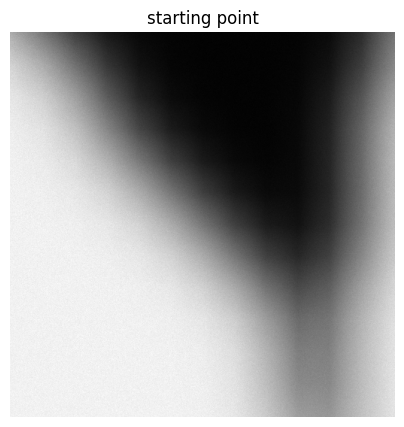

In [25]:
sim.set_environment("pristine")
sim.load_sample("shape_assembly", D=40, H=256, W=256)
control.set_mode("IMG"); control.set_resolution(512)
control.set_magnification(100_000)
control.set_beam({"current_pA":80,"voltage_kV":200}, relative=False)

def show(img, title=""):
    plt.figure(figsize=(5,5)); plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title(title); plt.show()
show(control.acquire_image("haadf"), "starting point")


## 5. Interactive: DRIFT (nm/s) — the main thing to sanity-check

Drift accumulates between frames. Acquire a few frames at a given drift and watch how far the
field moves. Realistic feel: at ~0.5 nm/s you barely notice over a few frames; at ~5 nm/s a
high-mag frame visibly walks. If your intuition says a bound is off, change `max=` below.

In [26]:
import ipywidgets as widgets
from IPython.display import display

def drift_demo(vx_nm_s=0.5, vy_nm_s=0.3, mag_kx=100, frames=4):
    sim.set_drift(vx_nm_per_s=vx_nm_s, vy_nm_per_s=vy_nm_s, enabled=True, reset_accum=True)
    control.set_magnification(mag_kx*1000)
    fig, axs = plt.subplots(1, frames, figsize=(3.2*frames, 3.4))
    for i in range(frames):
        axs[i].imshow(control.acquire_image("haadf"), cmap="gray"); axs[i].axis("off")
        axs[i].set_title(f"frame {i}")
        import time as _t; _t.sleep(0.4)
    plt.suptitle(f"drift {vx_nm_s:.2f},{vy_nm_s:.2f} nm/s @ {mag_kx} kx"); plt.tight_layout(); plt.show()

widgets.interact(drift_demo,
    vx_nm_s=widgets.FloatSlider(min=0, max=10, step=0.01, value=10, description="vx nm/s"),
    vy_nm_s=widgets.FloatSlider(min=0, max=10, step=0.01, value=15, description="vy nm/s"),
    mag_kx=widgets.IntSlider(min=10, max=100, step=10, value=50, description="mag kx"),
    frames=widgets.IntSlider(min=2, max=10, value=10, description="frames"));


interactive(children=(FloatSlider(value=10.0, description='vx nm/s', max=10.0, step=0.01), FloatSlider(value=1…

## 6. Interactive: z / focus, current, voltage, dwell (noise & focus bounds)

In [27]:
def optics_demo(z_um=0.0, current_pA=80, voltage_kV=200, dwell_us=20, mag_kx=500):
    control.set_stage({"z": z_um*1e-6}, relative=False)          # z in metres
    control.set_beam({"current_pA":current_pA,"voltage_kV":voltage_kV}, relative=False)
    control.device_settings("haadf", dwell_us=dwell_us)
    control.set_magnification(mag_kx*1000)
    show(control.acquire_image("haadf"),
         f"z={z_um:+.1f}um  {current_pA}pA  {voltage_kV}kV  {dwell_us}us")

widgets.interact(optics_demo,
    z_um=widgets.FloatSlider(min=-5, max=5, step=0.25, value=0, description="z (µm)"),
    current_pA=widgets.FloatSlider(min=1, max=500, step=1, value=80, description="current pA"),
    voltage_kV=widgets.Dropdown(options=[60,80,120,200,300], value=200, description="voltage kV"),
    dwell_us=widgets.FloatSlider(min=1, max=100, step=1, value=20, description="dwell µs"),
    mag_kx=widgets.IntSlider(min=50, max=8000, step=50, value=50, description="mag kx"));


interactive(children=(FloatSlider(value=0.0, description='z (µm)', max=5.0, min=-5.0, step=0.25), FloatSlider(…

## 7. Interactive: beam damage & contamination (accumulate over frames)

In [28]:
def degradation_demo(mode="beam_damage", threshold=1e4, rate=0.7, contam_rate=1.0, frames=6):
    sim.reset_specimen()
    if mode == "beam_damage":
        sim.set_specimen(beam_damage_enabled=True, contamination_enabled=False,
                         damage_dose_threshold=threshold, damage_rate=rate)
    else:
        sim.set_specimen(beam_damage_enabled=False, contamination_enabled=True,
                         contamination_rate=contam_rate)
    control.set_magnification(50_000); control.device_settings("haadf", dwell_us=40)
    control.set_stage({"x":0,"y":0}, relative=False)
    fig, axs = plt.subplots(1, frames, figsize=(2.6*frames, 3))
    for i in range(frames):
        axs[i].imshow(control.acquire_image("haadf"), cmap="gray"); axs[i].axis("off"); axs[i].set_title(f"{i}")
    plt.suptitle(f"{mode}: threshold={threshold:g} rate={rate} contam={contam_rate}")
    plt.tight_layout(); plt.show()

widgets.interact(degradation_demo,
    mode=widgets.Dropdown(options=["beam_damage","contamination"], value="beam_damage"),
    threshold=widgets.FloatLogSlider(base=10, min=2, max=6, step=0.25, value=1e4, description="dmg thresh"),
    rate=widgets.FloatSlider(min=0, max=2, step=0.05, value=0.7, description="dmg rate"),
    contam_rate=widgets.FloatSlider(min=0, max=5, step=0.1, value=1.0, description="contam rate"),
    frames=widgets.IntSlider(min=3, max=8, value=6, description="frames"));


interactive(children=(Dropdown(description='mode', options=('beam_damage', 'contamination'), value='beam_damag…

## 7b. Resolution ↔ dose (why beam damage speeds up at higher resolution)

Damage/contamination now use **real dose** `e⁻/Å² = (I·t/e)/pixel_area`, and
`pixel_area=(FOV/resolution)²`. So at the **same FOV and mag**, a higher resolution = smaller
pixel = **more dose per unit area** = faster damage. This is also exactly why a *pixel-based*
beam shift is resolution-dependent while a physical (nm) shift is not.

In [29]:
# same FOV, vary resolution -> damage accrues faster at higher resolution
for res in [512, 1024]:
    sim.load_sample("au_dispersed", D=40, H=256, W=256)
    sim.set_environment("beam_sensitive"); sim.reset_specimen()
    control.set_mode("IMG"); control.device_settings("haadf", field_of_view_um=0.1, dwell_us=20)
    control.set_resolution(res); control.set_stage({"x":0,"y":0}, relative=False)
    m0 = control.acquire_image("haadf").astype(float).mean()
    for _ in range(4): control.acquire_image("haadf")
    m1 = control.acquire_image("haadf").astype(float).mean()
    print(f"resolution {res}: {(1-m1/m0)*100:.0f}% darker after 5 frames  (smaller pixel -> more dose)")

# pixel<->nm conversion depends on resolution AND mag (relevant for beam shift):
for res in [512, 1024, 2048]:
    fov_nm = control.get_magnification()["field_of_view_um"]*1000
    print(f"res {res}: nm/pixel = {fov_nm/res:.4f} nm  (a 10-pixel beam shift = {10*fov_nm/res:.2f} nm)")
control.set_resolution(512)


resolution 512: 28% darker after 5 frames  (smaller pixel -> more dose)
resolution 1024: 72% darker after 5 frames  (smaller pixel -> more dose)
res 512: nm/pixel = 0.1953 nm  (a 10-pixel beam shift = 1.95 nm)
res 1024: nm/pixel = 0.0977 nm  (a 10-pixel beam shift = 0.98 nm)
res 2048: nm/pixel = 0.0488 nm  (a 10-pixel beam shift = 0.49 nm)


{'resolution_px': 512, 'allowed': [512, 1024, 2048]}

## 8. Interactive: thickness & sample counts (grains / dislocations)

In [30]:
def thickness_demo(working_nm=100, seed=0):
    sim.load_sample("fcc_single_crystal", D=40, H=256, W=256,
                    thickness_nm=working_nm, thickness_seed=seed)
    th = sim.get_thickness()
    control.set_mode("DIFF"); control.set_diffraction_settings(aperture_um=0.4, depth_nm=20)
    control.set_stage({"a":8,"b":0}, relative=False)
    dp = control.acquire_image("haadf")
    show(dp, f"thickness {working_nm} nm (z-window {th['z_start_nm']:.0f}–{th['z_start_nm']+working_nm:.0f} nm)")

widgets.interact(thickness_demo,
    working_nm=widgets.IntSlider(min=5, max=100, step=5, value=100, description="thick nm"),
    seed=widgets.IntSlider(min=0, max=9, value=0, description="thick seed"));

def structure_demo(sample="polycrystal_grains", n=4, seed=7):
    p = {"seed": seed}
    if sample=="polycrystal_grains": p["n_grains"]=n
    if sample=="dislocation_crystal": p={"disl_seed":seed,"n_dislocations":n}
    sim.load_sample(sample, params=p, D=40, H=256, W=256)
    control.set_mode("DIFF"); control.set_diffraction_settings(aperture_um=0.6, depth_nm=20)
    control.set_stage({"a":0,"b":0}, relative=False)
    show(control.acquire_image("haadf"), f"{sample}: n={n} seed={seed}")

widgets.interact(structure_demo,
    sample=widgets.Dropdown(options=["polycrystal_grains","dislocation_crystal"], value="polycrystal_grains"),
    n=widgets.IntSlider(min=1, max=40, value=4, description="grains/disl"),
    seed=widgets.IntSlider(min=0, max=20, value=7, description="seed"));


interactive(children=(IntSlider(value=100, description='thick nm', min=5, step=5), IntSlider(value=0, descript…

interactive(children=(Dropdown(description='sample', options=('polycrystal_grains', 'dislocation_crystal'), va…

## 9. Save a 32-bit TIFF of the current view (efficient, on-demand)

`TwinImageIO` holds only the **last** frame (O(1) memory) and writes a 32-bit float TIFF with a
clean auto-name (mode+sample+mag+resolution), adding a small `_2`, `_3` suffix only if the name
already exists — no timestamp clutter, no growing gallery. Pass `name=` for an explicit name.

In [31]:
# acquire something, stash it, then save on demand
control.set_mode("DIFF"); control.set_magnification(2_000_000); control.set_resolution(1024)
sim.load_sample("fcc_single_crystal", D=40, H=256, W=256)
dp = control.acquire_image("haadf")
io.stash(dp, meta=dict(mode="DIFF", sample="fcc_single_crystal",
                       mag_kx=2000, resolution=1024))
path = io.save_last()                       # 32-bit TIFF, auto-named
print("wrote", path)

# verify it's genuinely 32-bit float and metadata round-trips
import tifffile
back = tifffile.imread(path)
print("dtype:", back.dtype, "shape:", back.shape)

# a "Save" button you can reuse in the GUI:
save_btn = widgets.Button(description="💾 Save 32-bit TIFF", button_style="success")
out = widgets.Output()
def _on_save(_):
    with out:
        if io.has_image():
            print("saved:", io.save_last())
        else:
            print("acquire something first")
save_btn.on_click(_on_save)
display(save_btn, out)


wrote captures/diff_fcc_2000kx_1024px_2.tif
dtype: float32 shape: (1024, 1024)


Button(button_style='success', description='💾 Save 32-bit TIFF', style=ButtonStyle())

Output()

## 10. Notes on what to tune

- If drift at your chosen `max` (10 nm/s) still looks too gentle or too violent at the
  magnifications you care about, adjust the slider `max` in cell 5 and the preset values in
  `set_environment` (they're documented in the server's `presets`).
- Damage/contamination are *rates per frame-dose*; their "right" values depend on how many
  frames a typical workflow dwells — sweep cell 7 across your expected frame counts.
- `z` useful range is ~±2–5 µm (focus); the hard stage limit is ±1000 µm. The GUI should show
  the **z value** and offer a fine (focus, ±5 µm) and coarse (±1000 µm) step.
- Everything reproduces from seeds — note the seed shown in each title to return to a state.
